<div style="text-align: center; padding: 40px 0; border-bottom: 2px solid #e0e0e0; margin-bottom: 20px;">
  <h1 style="font-size: 2.5em; font-weight: 700; color: #000000; margin: 0;">
    🇦🇹 Austria Public Transport
  </h1>
  <h2 style="font-size: 1.4em; font-weight: 300; color: #555; margin: 10px 0 0 0;">
    GTFS and NeTEx Dataset Analysis — 2026
  </h2>
  <p style="color: #999; margin-top: 12px; font-size: 0.9em;">
    GTFS Source: data.oebb.at · NeTEx Source: data.mobilitaetsverbuende.at · Provider: ÖBB / Mobilitätsverbünde Austria
  </p>
</div>

## Data Source

**Austria GTFS Dataset**
- Provider: ÖBB (Österreichische Bundesbahnen), Austrian national railway operator
- Dataset page: https://data.oebb.at/de/datensaetze~soll-fahrplan-gtfs~
- File downloaded: `GTFS_Fahrplan_2026.zip`
- Coverage: ÖBB Fahrplan (timetable), validity 2025-12-14 to 2026-12-12
- No registration required — direct download

**Austria NeTEx Dataset**
- Provider: Mobilitätsverbünde Austria (regional transport associations open data portal)
- Dataset page: https://data.mobilitaetsverbuende.at
- File downloaded: `netex_evu_2026.zip`
- Coverage: same validity window as GTFS (2025-12-14 to 2026-12-12)
- **Registration required** — an account must be created on the portal before downloading. No direct/deep link is available without an account, so only the portal homepage is listed here.

## Table of Contents

**Setup**
- Imports

**Part 1 — GTFS Extraction**
- Load and validate GTFS files, build the GTFS MVD tables

**Part 2 — NeTEx Extraction**
- Extract NeTEx stops (StopPlace/Quay) and lines
- Reconstruct the full NeTEx calendar chain (`ServiceJourney → DayTypeRef → DayTypeAssignment → UicOperatingPeriod`)

**Part 3 — Station-level MVD comparison**

**Part 4 — Route/Line-level MVD comparison**
- Validation via matched stop-name sets

**Part 5 — Calendar-level MVD comparison**

**Appendix**
- Additional GTFS checks
- NeTEx exploration / debug notes
- `PropertyOfDay` check

## Imports

All third-party and standard-library imports used in this notebook are consolidated here.

In [ ]:
from pathlib import Path
import zipfile
import re
import math
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
from collections import Counter
import matplotlib.pyplot as plt

In [1]:
NETEX_NS = "{http://www.netex.org.uk/netex}"
NETEX_NS_MAP = {"n": "http://www.netex.org.uk/netex"}

# Part 1: GTFS Extraction

### Set the path to the GTFS dataset zip file

In [2]:
DATA_DIR = Path("data/raw")
zip_path = DATA_DIR / "GTFS_Fahrplan_2026.zip"

### Helper function: read GTFS tables from the zip

In [3]:
def read_gtfs_from_zip(zip_path: Path, filename: str) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as z:
        names = z.namelist()

        # If caller passed exact path, use it
        if filename in names:
            target = filename
        else:
            # Otherwise find it anywhere in the zip
            matches = [n for n in names if n.lower().endswith("/" + filename.lower())]
            if not matches:
                raise FileNotFoundError(f"{filename} not found. Example: {names[:20]}")
            if len(matches) > 1:
                raise FileNotFoundError(f"Multiple matches for {filename}: {matches}")
            target = matches[0]

        with z.open(target) as f:
            return pd.read_csv(f, low_memory=False)

### Load main GTFS files

I loaded the main GTFS files (stops, routes, trips, stop_times, calendar, calendar_dates, agency) directly from the GTFS zip. These tables are the input for building the GTFS Minimum Viable Dataset (MVD).

In [4]:
stops = read_gtfs_from_zip(zip_path, "stops.txt")
routes = read_gtfs_from_zip(zip_path, "routes.txt")
trips = read_gtfs_from_zip(zip_path, "trips.txt")
stop_times = read_gtfs_from_zip(zip_path, "stop_times.txt")
calendar = read_gtfs_from_zip(zip_path, "calendar.txt")
calendar_dates = read_gtfs_from_zip(zip_path, "calendar_dates.txt")
agency = read_gtfs_from_zip(zip_path, "agency.txt") 

### GTFS table size check

In [5]:
def overview(name, df):
    print(f"\n{name}: rows={len(df):,}, cols={df.shape[1]}")
    
overview("stops", stops)
overview("routes", routes)
overview("trips", trips)
overview("stop_times", stop_times)
overview("calendar", calendar)
overview("calendar_dates", calendar_dates)
overview("agency", agency)


stops: rows=7,698, cols=9

routes: rows=273, cols=5

trips: rows=15,165, cols=8

stop_times: rows=174,124, cols=9

calendar: rows=1,340, cols=10

calendar_dates: rows=169,094, cols=3

agency: rows=3, cols=6


### Validate GTFS columns for the MVD

I defined which columns are required for my GTFS MVD (for stops, routes, trips, stop_times, and calendar). Then I checked each loaded table to see if any required columns are missing. The result showed no missing columns, so the GTFS feed contains all fields needed for the MVD.

In [6]:
mvd_required = {
    "stops": ["stop_id", "stop_name", "stop_lat", "stop_lon"],
    "routes": ["route_id"],
    "trips": ["trip_id", "route_id", "service_id"],
    "stop_times": ["trip_id", "stop_id", "stop_sequence", "arrival_time", "departure_time"],
    "calendar": ["service_id", "start_date", "end_date"],
}

for table, cols in mvd_required.items():
    df = globals()[table]
    missing_cols = [c for c in cols if c not in df.columns]
    print(table, "missing cols:", missing_cols if missing_cols else "None")

stops missing cols: None
routes missing cols: None
trips missing cols: None
stop_times missing cols: None
calendar missing cols: None


### Data quality check: core stop fields

In [7]:
print("\nMissingness in stop core fields:")
print(stops[["stop_id","stop_name","stop_lat","stop_lon"]].isna().mean().sort_values(ascending=False))


Missingness in stop core fields:
stop_id      0.0
stop_name    0.0
stop_lat     0.0
stop_lon     0.0
dtype: float64


### Stop hierarchy: location_type and parent_station

I inspected the GTFS stop hierarchy by looking at location_type values and how often parent_station is used. Many records have missing location_type (often treated as the default stop/platform type), but the feed also contains stations/entrances/nodes. In addition, 6525 stops reference a parent_station, showing that the dataset models multi-level stations (e.g., station → platforms/entrances).

In [8]:
print("location_type value counts:")
print(stops["location_type"].value_counts(dropna=False))

print("\nExample parent_station usage (non-null count):", stops["parent_station"].notna().sum())

location_type value counts:
location_type
NaN    3636
3.0    1661
2.0    1282
1.0    1119
Name: count, dtype: int64

Example parent_station usage (non-null count): 6525


# Step 2: Create MVD

### Export GTFS → MVD CSV tables

I first created a processed output folder (data/processed/oebb_gtfs_mvd/).

From the full GTFS feed, I extracted a minimal set of columns (MVD) for stops, routes, trips, stop_times, and calendar information.

Then I exported these MVD tables as CSV files (mvd_stops.csv, mvd_routes.csv, mvd_trips.csv, mvd_stop_times.csv, mvd_calendar.csv, mvd_calendar_dates.csv) for later comparison with the NeTEx-based outputs.

In [9]:
out_dir = Path("data/processed/oebb_gtfs_mvd")
out_dir.mkdir(parents=True, exist_ok=True)

# MVD tables (minimal denominator)
mvd_stops = stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]].copy()

mvd_routes = routes[["route_id", "route_short_name", "route_long_name", "route_type"]].copy()

mvd_trips = trips[["trip_id", "route_id", "service_id"]].copy()

mvd_stop_times = stop_times[["trip_id", "stop_id", "stop_sequence", "arrival_time", "departure_time"]].copy()

# keep both calendar sources for traceability
mvd_calendar = calendar[["service_id", "monday","tuesday","wednesday","thursday","friday","saturday","sunday","start_date","end_date"]].copy()
mvd_calendar_dates = calendar_dates.copy()

# Save
mvd_stops.to_csv(out_dir / "mvd_stops.csv", index=False)
mvd_routes.to_csv(out_dir / "mvd_routes.csv", index=False)
mvd_trips.to_csv(out_dir / "mvd_trips.csv", index=False)
mvd_stop_times.to_csv(out_dir / "mvd_stop_times.csv", index=False)
mvd_calendar.to_csv(out_dir / "mvd_calendar.csv", index=False)
mvd_calendar_dates.to_csv(out_dir / "mvd_calendar_dates.csv", index=False)

print("Saved MVD outputs to:", out_dir)
for f in sorted(out_dir.glob("*.csv")):
    print("-", f.name)

Saved MVD outputs to: data/processed/oebb_gtfs_mvd
- gtfs_line_stopname_mvd.csv
- mvd_calendar.csv
- mvd_calendar_dates.csv
- mvd_routes.csv
- mvd_stop_times.csv
- mvd_stops.csv
- mvd_trips.csv


### Quick inspection of the GTFS feed

I printed a short summary of the GTFS dataset: the overall validity period (from `calendar` and `calendar_dates`), basic table sizes (stops/routes/trips/stop_times), and the number of unique `service_id`s.  
I also checked the stop hierarchy by counting how many stops reference a `parent_station` and by listing the `location_type` distribution.

In [10]:
print("ÖBB GTFS Fahrplan 2026 — quick inspection")
print("----------------------------------------")
print("Validity (calendar):", calendar["start_date"].min(), "→", calendar["end_date"].max())
print("Validity (calendar_dates):", calendar_dates["date"].min(), "→", calendar_dates["date"].max())
print()
print("Counts:")
print(" - stops:", len(stops))
print(" - routes:", len(routes))
print(" - trips:", len(trips))
print(" - stop_times:", len(stop_times))
print(" - service_id (calendar):", calendar["service_id"].nunique())
print(" - service_id (calendar_dates):", calendar_dates["service_id"].nunique())
print()
print("Stop hierarchy:")
print(" - parent_station non-null:", stops["parent_station"].notna().sum(), "of", len(stops))
print(" - location_type values:", stops["location_type"].value_counts(dropna=False).to_dict())

ÖBB GTFS Fahrplan 2026 — quick inspection
----------------------------------------
Validity (calendar): 20251214 → 20261212
Validity (calendar_dates): 20251214 → 20261212

Counts:
 - stops: 7698
 - routes: 273
 - trips: 15165
 - stop_times: 174124
 - service_id (calendar): 1340
 - service_id (calendar_dates): 1311

Stop hierarchy:
 - parent_station non-null: 6525 of 7698
 - location_type values: {nan: 3636, 3.0: 1661, 2.0: 1282, 1.0: 1119}


# Part 2: NeTEx Extraction

## NETEX FILE

### Load file
First, I define the path to the NeTEx dataset. It is the raw ZIP file that contains many NeTEx XML files.

In [11]:
netex_zip = DATA_DIR / "netex_evu_2026.zip"

### Inspect ZIP contents and identify XML files

Here I open the ZIP file and list the files inside it. Then I create a small overview table and list file names and size.

In [12]:
with zipfile.ZipFile(netex_zip, "r") as z:
    infos = z.infolist()

df_files = pd.DataFrame([{
    "name": i.filename,
    "size_mb": round(i.file_size / (1024*1024), 2)
} for i in infos])

display(df_files.sort_values("size_mb", ascending=False).head(20))

xml_files = df_files[df_files["name"].str.lower().str.endswith(".xml")].sort_values("size_mb", ascending=False)
print("XML files:", len(xml_files))
display(xml_files.head(20))

,name,size_mb
45,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml,23.54
2,NX-PI_01_at_obb_LINE_obb_1-S3-W-j26_20260302.xml,20.93
57,NX-PI_01_at_obb_LINE_obb_2-RX1-W-j26_20260302.xml,17.71
79,NX-PI_01_at_obb_LINE_obb_1-S2-W-j26_20260302.xml,15.96
21,NX-PI_01_at_obb_LINE_obb_10-A3-j26_20260302.xml,15.64
78,NX-PI_01_at_obb_LINE_obb_12-A1-j26_20260302.xml,13.79
58,NX-PI_01_at_obb_LINE_obb_1-S1-W-j26_20260302.xml,12.93
77,NX-PI_01_at_obb_LINE_obb_2-RX3-W-j26_20260302.xml,12.70
365,NX-PI_01_at_obb_LINE_obb_9-WB1-W-j26_20260302.xml,12.64
318,NX-PI_01_at_obb_LINE_obb_10-A11-j26_20260302.xml,11.98


XML files: 368


,name,size_mb
45,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml,23.54
2,NX-PI_01_at_obb_LINE_obb_1-S3-W-j26_20260302.xml,20.93
57,NX-PI_01_at_obb_LINE_obb_2-RX1-W-j26_20260302.xml,17.71
79,NX-PI_01_at_obb_LINE_obb_1-S2-W-j26_20260302.xml,15.96
21,NX-PI_01_at_obb_LINE_obb_10-A3-j26_20260302.xml,15.64
78,NX-PI_01_at_obb_LINE_obb_12-A1-j26_20260302.xml,13.79
58,NX-PI_01_at_obb_LINE_obb_1-S1-W-j26_20260302.xml,12.93
77,NX-PI_01_at_obb_LINE_obb_2-RX3-W-j26_20260302.xml,12.70
365,NX-PI_01_at_obb_LINE_obb_9-WB1-W-j26_20260302.xml,12.64
318,NX-PI_01_at_obb_LINE_obb_10-A11-j26_20260302.xml,11.98


In [13]:
all_xml = xml_files["name"].tolist()

### Inspect largest XML file

In this step I pick the largest XML file and print only the first 4KB. I picked the largest XML file because it usually contains the main data (like stops, lines).
This help me confirm the validity of the file and helped me to see basic metadata.


In [14]:
with zipfile.ZipFile(netex_zip, "r") as z:
    # pick largest XML file as a good first candidate
    xml_name = xml_files.iloc[0]["name"]
    print("Opening:", xml_name)

    with z.open(xml_name) as f:
        head = f.read(4000)  # first ~4KB
        print(head.decode("utf-8", errors="replace"))

Opening: NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
﻿<?xml version="1.0" encoding="utf-8"?>
<PublicationDelivery xmlns:gml="http://www.opengis.net/gml/3.2" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xmlns:siri="http://www.siri.org.uk/siri" xsi:schemaLocation="http://www.netex.org.uk/netex https://raw.githubusercontent.com/NeTEx-CEN/NeTEx/master/xsd/NeTEx_publication.xsd" version="1.10" xmlns="http://www.netex.org.uk/netex">
  <!--Profile: EU-->
  <PublicationTimestamp>2026-03-02T22:50:27.6098628+01:00</PublicationTimestamp>
  <ParticipantRef>MENTZ</ParticipantRef>
  <Description>NeTEx Export, Version: 19.77.0.6685</Description>
  <dataObjects>
    <CompositeFrame id="at:obb:CompositeFrame:obb:120A3_.j26" version="any">
      <ValidBetween>
        <FromDate>2025-12-14T00:00:00</FromDate>
        <ToDate>2026-12-12T23:59:59</ToDate>
      </ValidBetween>
      <TypeOfFrameRef ref="epip:EU_PI_LINE_OFFER" />
      <codespaces>
        <Codespace id="epip_data">
          <

### Timetable Validity Check

Next I checked the timetable validity period in the NeTEx dataset. For each XML file, I looked for the ValidBetween section and extracted the FromDate and ToDate. I tested this on the first 50 XML files to see if the validity window is consistent across the dataset. The result was that all checked files had the same start and end date, which suggests the NeTEx export uses one common validity period for this timetable version.

In [15]:
def extract_validbetween(zip_path: Path, xml_name: str):

    with zipfile.ZipFile(zip_path, "r") as z:
        with z.open(xml_name) as f:
            head = f.read(50000).decode("utf-8", errors="replace")

    # naive string search
    # if not found, returns None
    from_m = re.search(r"<FromDate>(.*?)</FromDate>", head)
    to_m   = re.search(r"<ToDate>(.*?)</ToDate>", head)
    return (from_m.group(1) if from_m else None, to_m.group(1) if to_m else None)

valid_rows = []
for xml_name in all_xml[:50]:  # check first 50 quickly first
    fdate, tdate = extract_validbetween(netex_zip, xml_name)
    valid_rows.append({"xml": xml_name, "from": fdate, "to": tdate})

vb = pd.DataFrame(valid_rows)
display(vb.head())
print("Unique FromDate:", vb["from"].nunique())
print("Unique ToDate:", vb["to"].nunique())
print("Most common:", vb["from"].mode().iloc[0], vb["to"].mode().iloc[0])

,xml,from,to
0,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml,2025-12-14T00:00:00,2026-12-12T23:59:59
1,NX-PI_01_at_obb_LINE_obb_1-S3-W-j26_20260302.xml,2025-12-14T00:00:00,2026-12-12T23:59:59
2,NX-PI_01_at_obb_LINE_obb_2-RX1-W-j26_20260302.xml,2025-12-14T00:00:00,2026-12-12T23:59:59
3,NX-PI_01_at_obb_LINE_obb_1-S2-W-j26_20260302.xml,2025-12-14T00:00:00,2026-12-12T23:59:59
4,NX-PI_01_at_obb_LINE_obb_10-A3-j26_20260302.xml,2025-12-14T00:00:00,2026-12-12T23:59:59


Unique FromDate: 1
Unique ToDate: 1
Most common: 2025-12-14T00:00:00 2026-12-12T23:59:59


### Extracting stops from NeTEx (Quay + StopPlace)

This function reads the NeTEx ZIP file and extracts stop data into a table. The ZIP contains many XML files, so I open each XML and parse it in a streaming way (iterparse) to avoid memory problems. Whenever I find a Quay or a StopPlace element, I take its id, Name, and the coordinates from Centroid/Location/Latitude and Longitude. I store each result as one row with a stop_type (Quay or StopPlace) and then return a pandas DataFrame with duplicate stop_ids removed.

*StopPlace* = the whole station/stop area (e.g., “Wien Hauptbahnhof”)

*Quay* = a specific place inside that StopPlace where you actually board (e.g., “Platform 3”)

In [16]:
def extract_netex_stops_mvd(netex_zip_path, xml_files, limit_files=None):
    rows = []
    files = xml_files[:limit_files] if limit_files else xml_files

    with zipfile.ZipFile(netex_zip_path, "r") as z:
        for idx, xml_name in enumerate(files, 1):
            with z.open(xml_name) as f:
                # stream parse
                for event, elem in ET.iterparse(f, events=("end",)):
                    # Quay
                    if elem.tag == NETEX_NS + "Quay":
                        stop_id = elem.get("id")

                        name_el = elem.find(NETEX_NS + "Name")
                        stop_name = name_el.text.strip() if (name_el is not None and name_el.text) else None

                        lon_el = elem.find(NETEX_NS + "Centroid/" + NETEX_NS + "Location/" + NETEX_NS + "Longitude")
                        lat_el = elem.find(NETEX_NS + "Centroid/" + NETEX_NS + "Location/" + NETEX_NS + "Latitude")

                        stop_lon = float(lon_el.text) if (lon_el is not None and lon_el.text) else None
                        stop_lat = float(lat_el.text) if (lat_el is not None and lat_el.text) else None

                        rows.append({
                            "stop_id": stop_id,
                            "stop_name": stop_name,
                            "stop_lat": stop_lat,
                            "stop_lon": stop_lon,
                            "stop_type": "Quay"
                        })
                        elem.clear()

                    # StopPlace
                    elif elem.tag == NETEX_NS + "StopPlace":
                        stop_id = elem.get("id")

                        name_el = elem.find(NETEX_NS + "Name")
                        stop_name = name_el.text.strip() if (name_el is not None and name_el.text) else None

                        lon_el = elem.find(NETEX_NS + "Centroid/" + NETEX_NS + "Location/" + NETEX_NS + "Longitude")
                        lat_el = elem.find(NETEX_NS + "Centroid/" + NETEX_NS + "Location/" + NETEX_NS + "Latitude")

                        stop_lon = float(lon_el.text) if (lon_el is not None and lon_el.text) else None
                        stop_lat = float(lat_el.text) if (lat_el is not None and lat_el.text) else None

                        rows.append({
                            "stop_id": stop_id,
                            "stop_name": stop_name,
                            "stop_lat": stop_lat,
                            "stop_lon": stop_lon,
                            "stop_type": "StopPlace"
                        })
                        elem.clear()

            if idx % 25 == 0:
                print(f"Processed {idx}/{len(files)} XML files...")

    df = pd.DataFrame(rows).drop_duplicates(subset=["stop_id"])
    return df

### Display the first 10 extracted records

In [17]:
netex_stops_mvd = extract_netex_stops_mvd(netex_zip, all_xml, limit_files=5)
netex_stops_mvd.head(10)

,stop_id,stop_name,stop_lat,stop_lon,stop_type
0,at:41:4367:1,Bahn,47.942992,17.085894,Quay
1,at:41:4367:2,Bus,47.942408,17.086756,Quay
2,at:41:4367:0:3,2,47.943022,17.085921,Quay
3,at:41:4367,Nickelsdorf Bahnhof,47.942637,17.086648,StopPlace
4,at:41:4469:1,Bahn,47.986896,16.871933,Quay
5,at:41:4469:2,Bus,47.987250,16.869768,Quay
6,at:41:4469:4,bahn,47.987028,16.872059,Quay
7,at:41:4469:0:2,2,47.986920,16.871933,Quay
8,at:41:4469,Parndorf Bahnhof,47.986968,16.870343,StopPlace
9,at:41:4473:1,BahnG1,47.992096,16.851856,Quay


### Full extraction + quality check

In this step, I ran my stop-extraction function on **all NeTEx XML files** in the ZIP. The goal was to create one complete table with stops and then quickly check if the data looks reasonable.

In [18]:
netex_stops_mvd = extract_netex_stops_mvd(netex_zip, all_xml)
print(netex_stops_mvd.shape)
netex_stops_mvd.isna().mean().sort_values(ascending=False).head(10)

Processed 25/368 XML files...
Processed 50/368 XML files...
Processed 75/368 XML files...
Processed 100/368 XML files...
Processed 125/368 XML files...
Processed 150/368 XML files...
Processed 175/368 XML files...
Processed 200/368 XML files...
Processed 225/368 XML files...
Processed 250/368 XML files...
Processed 275/368 XML files...
Processed 300/368 XML files...
Processed 325/368 XML files...
Processed 350/368 XML files...
(9075, 5)


stop_name    0.103140
stop_lon     0.036253
stop_lat     0.036253
stop_id      0.000000
stop_type    0.000000
dtype: float64

**What I got:**

* The output table has shape **(9075, 5)** → **9075 stops** and **5 columns** (`stop_id`, `stop_name`, `stop_lat`, `stop_lon`, `stop_type`)
* Missing values:

  * **stop_name** missing ~ **10%**
  * **stop_lat** missing ~ **3.6%**
  * **stop_lon** missing ~ **3.6%**
  * **stop_id** missing **0%**
  * **stop_type** missing **0%**

**Conclusion:**
The extraction works for the full dataset, and most stops have coordinates, while some stops are missing names.

 ### Quick summary statistics (missing values + stop types)

In this cell, I made a **small quality check** of the extracted NeTEx stops table.

**What I did:**

* I printed the **total number of extracted stops**.
* I calculated the **share of missing values** for:

  * `stop_name`
  * `stop_lat`
  * `stop_lon`
* I counted how many stops belong to each **stop type** using `value_counts()`.

**What I got:**

* **Total stops:** 9075
* **Missing values:**

  * Missing name ≈ 10%
  * Missing lat ≈ 3.6%
  * Missing lon ≈ 3.6%
* **Stop types:**

  * `Quay`: 7406
  * `StopPlace`: 1669


This tells me if the extraction looks realistic and if the dataset mainly contains platform-level stops (`Quay`) and station-level stops (`StopPlace`).



In [19]:
print("Total stops:", len(netex_stops_mvd))
print("Missing name %:", netex_stops_mvd["stop_name"].isna().mean())
print("Missing lat %:", netex_stops_mvd["stop_lat"].isna().mean())
print("Missing lon %:", netex_stops_mvd["stop_lon"].isna().mean())

print(netex_stops_mvd["stop_type"].value_counts())

Total stops: 9075
Missing name %: 0.10314049586776859
Missing lat %: 0.0362534435261708
Missing lon %: 0.0362534435261708
stop_type
Quay         7406
StopPlace    1669
Name: count, dtype: int64


### Test one specific stop ID

In this cell, I looked up **one specific stop** by its `stop_id` to confirm the row looks correct. This confirms that the extracted table really contains usable values for an actual ID (not only empty fields or wrong parsing)


In [20]:
netex_stops_mvd[netex_stops_mvd["stop_id"] == "at:43:3079:1"]

,stop_id,stop_name,stop_lat,stop_lon,stop_type
1133,at:43:3079:1,Bahn,48.133223,16.910776,Quay


### Save stops for mvd

In [21]:
out_dir = Path("data/processed/oebb_netex_mvd")
out_dir.mkdir(parents=True, exist_ok=True)

netex_stops_mvd.to_csv(out_dir / "netex_stops_mvd.csv", index=False)
print("Saved:", (out_dir / "netex_stops_mvd.csv"))

Saved: data/processed/oebb_netex_mvd/netex_stops_mvd.csv


### Extracting lines from NeTEx

In [22]:
def extract_netex_lines_mvd(netex_zip_path, xml_files, limit_files=None):
    rows = []
    files = xml_files[:limit_files] if limit_files else xml_files

    with zipfile.ZipFile(netex_zip_path, "r") as z:
        for idx, xml_name in enumerate(files, 1):
            with z.open(xml_name) as f:
                for event, elem in ET.iterparse(f, events=("end",)):
                    if elem.tag == NETEX_NS + "Line":
                        route_id = elem.get("id")

                        name_el = elem.find(NETEX_NS + "Name")
                        short_el = elem.find(NETEX_NS + "ShortName")
                        pub_el = elem.find(NETEX_NS + "PublicCode")

                        route_name = None
                        if name_el is not None and name_el.text and name_el.text.strip():
                            route_name = name_el.text.strip()
                        elif short_el is not None and short_el.text and short_el.text.strip():
                            route_name = short_el.text.strip()

                        public_code = pub_el.text.strip() if (pub_el is not None and pub_el.text) else None

                        rows.append({
                            "route_id": route_id,
                            "route_name": route_name,
                            "public_code": public_code
                        })

                        elem.clear()

            if idx % 25 == 0:
                print(f"Processed {idx}/{len(files)} XML files...")

    return pd.DataFrame(rows).drop_duplicates(subset=["route_id"])

### Check the data 

In [23]:
netex_lines_mvd = extract_netex_lines_mvd(netex_zip, all_xml)
display(netex_lines_mvd.head(10))
print(netex_lines_mvd.shape)
print(netex_lines_mvd.isna().mean().sort_values(ascending=False).head(10))

Processed 25/368 XML files...
Processed 50/368 XML files...
Processed 75/368 XML files...
Processed 100/368 XML files...
Processed 125/368 XML files...
Processed 150/368 XML files...
Processed 175/368 XML files...
Processed 200/368 XML files...
Processed 225/368 XML files...
Processed 250/368 XML files...
Processed 275/368 XML files...
Processed 300/368 XML files...
Processed 325/368 XML files...
Processed 350/368 XML files...


,route_id,route_name,public_code
0,at:obb:Line:120A3_.j26:,A3,None
1,at:obb:Line:010S3W.j26:,S3,S3
2,at:obb:Line:02RX1W.j26:,REX1,REX1
3,at:obb:Line:010S2W.j26:,S2,S2
4,at:obb:Line:100A3_.j26:,A3,None
5,at:obb:Line:120A1_.j26:,A1,None
6,at:obb:Line:010S1W.j26:,S1,S1
7,at:obb:Line:02RX3W.j26:,REX3,REX3
8,at:obb:Line:09WB1W.j26:,WB1,None
9,at:obb:Line:10A11_.j26:,A11,None


(367, 3)
public_code    0.389646
route_id       0.000000
route_name     0.000000
dtype: float64


### Save lines for mvd

In [24]:
netex_lines_mvd.to_csv(out_dir / "netex_lines_mvd.csv", index=False)
print("Saved:", (out_dir / "netex_lines_mvd.csv"))

Saved: data/processed/oebb_netex_mvd/netex_lines_mvd.csv


## NeTEx calendar chain extraction

The simple validity-window placeholder above is not enough for a real calendar comparison. The section below reconstructs the full NeTEx calendar chain from the raw XML (`ServiceJourney → DayTypeRef → DayTypeAssignment → UicOperatingPeriod`), scaling from a one-file prototype up to all 368 files, and enriches it with descriptive `DayType` fields. This is the table actually used in the calendar-level comparison in Part 5.

## Goal

The current processed NeTEx calendar MVD only contains a very small validity-period structure.

The goal of this section is therefore to inspect the raw NeTEx XML files and check whether a richer service-validity structure can be extracted, for example operating days, day types, or date-level validity information.

This section is exploratory and technical. Its purpose is to improve the NeTEx calendar extraction for the Austria pilot.

## NeTEx calendar extraction summary

- The NeTEx ZIP file was loaded and all XML files were identified
- The XML files were searched for calendar-related keywords to check whether richer calendar logic exists
- One example XML file was selected and its tags and nesting were inspected
- The main calendar chain was identified as:

`ServiceJourney` → `DayTypeRef` → `DayTypeAssignment` → `UicOperatingPeriod`

- It was confirmed that `UicOperatingPeriod` contains the actual calendar values:
  - `FromDate`
  - `ToDate`
  - `ValidDayBits`

- This logic was rebuilt into a prototype table for one XML file
- The same extraction was then tested on **5 files**, and later on **20 files**, to check that the output remained clean
- After that, the extraction was scaled to all XML files
- The result showed that **367 files** produced calendar rows, while **1 file** was outside the scope because it only contained stop-related content
- Final quality checks showed that the extracted mapping is consistent

### Enrichment of the final table

The table was then enriched with more readable fields:

- `daytype_name`
- `daytype_short_name`
- `n_active_days`
- `first_active_bit_pos`
- `last_active_bit_pos`
- `first_active_date`
- `last_active_date`

### Saved outputs

Both of the following were saved:

- the extracted table
- the enriched final table

## Search the NeTEx XML for calendar-related structures

Before building a richer NeTEx calendar extraction, I first search the raw XML files for calendar-related tags and keywords.

The goal is to identify which NeTEx structures are used for service validity in the Austria dataset.

In [25]:
calendar_keywords = [
    "DayType",
    "DayTypeAssignment",
    "OperatingPeriod",
    "OperatingDay",
    "AvailabilityCondition",
    "ValidityCondition",
    "ValidDayBits",
    "ServiceJourney"
]

In [26]:
# Function that searches the XML files for those words

def scan_xml_for_keywords(netex_zip_path, xml_files, keywords, limit_files=None):
    rows = []
    files = xml_files[:limit_files] if limit_files else xml_files

    with zipfile.ZipFile(netex_zip_path, "r") as z:
        for xml_name in files:
            try:
                with z.open(xml_name) as f:
                    content = f.read().decode("utf-8", errors="ignore")
            except Exception:
                continue

            found = [kw for kw in keywords if kw in content]

            if found:
                rows.append({
                    "xml_file": xml_name,
                    "matched_keywords": ", ".join(found),
                    "n_keywords_found": len(found)
                })

    return pd.DataFrame(rows)

In [27]:
# Call the function

keyword_hits = scan_xml_for_keywords(netex_zip, all_xml, calendar_keywords, limit_files=20)
display(keyword_hits)

,xml_file,matched_keywords,n_keywords_found
0,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml,"DayType, DayTypeAssignment, OperatingPeriod, A...",6
1,NX-PI_01_at_obb_LINE_obb_1-S3-W-j26_20260302.xml,"DayType, DayTypeAssignment, OperatingPeriod, V...",5
2,NX-PI_01_at_obb_LINE_obb_2-RX1-W-j26_20260302.xml,"DayType, DayTypeAssignment, OperatingPeriod, A...",6
3,NX-PI_01_at_obb_LINE_obb_1-S2-W-j26_20260302.xml,"DayType, DayTypeAssignment, OperatingPeriod, A...",6
4,NX-PI_01_at_obb_LINE_obb_10-A3-j26_20260302.xml,"DayType, DayTypeAssignment, OperatingPeriod, A...",6
5,NX-PI_01_at_obb_LINE_obb_12-A1-j26_20260302.xml,"DayType, DayTypeAssignment, OperatingPeriod, V...",5
6,NX-PI_01_at_obb_LINE_obb_1-S1-W-j26_20260302.xml,"DayType, DayTypeAssignment, OperatingPeriod, A...",6
7,NX-PI_01_at_obb_LINE_obb_2-RX3-W-j26_20260302.xml,"DayType, DayTypeAssignment, OperatingPeriod, V...",5
8,NX-PI_01_at_obb_LINE_obb_9-WB1-W-j26_20260302.xml,"DayType, DayTypeAssignment, OperatingPeriod, A...",6
9,NX-PI_01_at_obb_LINE_obb_10-A11-j26_20260302.xml,"DayType, DayTypeAssignment, OperatingPeriod, A...",6


## Observation

At this stage, I can say the following:

- In the tested sample of XML files, calendar-related tags such as `DayType`, `DayTypeAssignment`, and `OperatingPeriod` appear multiple times
- This suggests that the **NeTEx source files probably contain a richer calendar structure**
- However, this was only checked on a **subset of the XML files**, so the result is still **exploratory**

## Next step

The best next step is:

1. Pick one representative XML file.
2. Inspect its structure, nesting, and references.
3. Understand how the calendar information is connected inside that file.
4. Later, check whether the same structure also appears in other XML files.

This is the same approach I used in the earlier NeTEx analysis, and seems to be the right approach here as well.

In [28]:
# Inspect one example NeTEx XML file

example_xml = keyword_hits.iloc[0]["xml_file"]
print("Example XML file:", example_xml)

Example XML file: NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml


In [29]:
NETEX_NS = "{http://www.netex.org.uk/netex}"

calendar_tags = {
    "DayType",
    "DayTypeAssignment",
    "OperatingPeriod",
    "OperatingDay",
    "AvailabilityCondition",
    "ValidityCondition",
    "ValidDayBits",
    "ServiceJourney"
}

tag_counter = Counter()

with zipfile.ZipFile(netex_zip, "r") as z:
    with z.open(example_xml) as f:
        for event, elem in ET.iterparse(f, events=("end",)):
            tag_name = elem.tag.split("}")[-1]
            if tag_name in calendar_tags:
                tag_counter[tag_name] += 1
            elem.clear()

print("Calendar-related tag counts in example file:")
for tag, count in sorted(tag_counter.items()):
    print(f"{tag}: {count}")

Calendar-related tag counts in example file:
AvailabilityCondition: 3
DayType: 98
DayTypeAssignment: 98
ServiceJourney: 215
ValidDayBits: 101


## Output

The example XML file contains several calendar-related structures, especially `DayType`, `DayTypeAssignment`, `ServiceJourney`, `AvailabilityCondition`, and `ValidDayBits`.

This suggests that richer service-validity logic is present in the NeTEx source data. At the same time, the calendar structure in this file does not seem to rely mainly on `OperatingPeriod`, but rather on day-type and validity-bit based elements.

The next step is therefore to inspect these elements more closely and understand how they are linked to each other.

## Inspect example calendar-related elements

After identifying the main calendar-related tags in one XML file, the next step is to inspect a few example elements.

The goal is to understand which IDs, references, and child elements are used, and how the calendar logic may be linked together.

In [30]:
tags_to_inspect = {"DayType", "DayTypeAssignment", "AvailabilityCondition", "ServiceJourney", "ValidDayBits"}

examples = {tag: [] for tag in tags_to_inspect}

with zipfile.ZipFile(netex_zip, "r") as z:
    with z.open(example_xml) as f:
        for event, elem in ET.iterparse(f, events=("end",)):
            tag_name = elem.tag.split("}")[-1]

            if tag_name in tags_to_inspect and len(examples[tag_name]) < 3:
                examples[tag_name].append({
                    "tag": tag_name,
                    "attributes": dict(elem.attrib),
                    "children": [child.tag.split("}")[-1] for child in list(elem)]
                })

            elem.clear()

for tag, items in examples.items():
    print(f"\n=== {tag} examples ===")
    for i, item in enumerate(items, 1):
        print(f"\nExample {i}")
        print("Attributes:", item["attributes"])
        print("Children:", item["children"])


=== ValidDayBits examples ===

Example 1
Attributes: {}
Children: []

Example 2
Attributes: {}
Children: []

Example 3
Attributes: {}
Children: []

=== AvailabilityCondition examples ===

Example 1
Attributes: {'id': 'at:obb:AvailabilityCondition:31000:', 'version': 'any'}
Children: ['FromDate', 'ToDate', 'ValidDayBits']

Example 2
Attributes: {'id': 'at:obb:AvailabilityCondition:aa:', 'version': 'any'}
Children: ['FromDate', 'ToDate', 'ValidDayBits']

Example 3
Attributes: {'id': 'at:obb:AvailabilityCondition:jA:', 'version': 'any'}
Children: ['FromDate', 'ToDate', 'ValidDayBits']

=== DayTypeAssignment examples ===

Example 1
Attributes: {'id': 'at:obb:DayTypeAssignment:03000_6::001', 'version': 'any', 'order': '1'}
Children: ['OperatingPeriodRef', 'DayTypeRef']

Example 2
Attributes: {'id': 'at:obb:DayTypeAssignment:09200_6::001', 'version': 'any', 'order': '1'}
Children: ['OperatingPeriodRef', 'DayTypeRef']

Example 3
Attributes: {'id': 'at:obb:DayTypeAssignment:0k800_6::001', 've

## Likely calendar chain

A likely calendar structure in the NeTEx files can be already observed:

- **`DayTypeAssignment`**
  - has the children:
    - `OperatingPeriodRef`
    - `DayTypeRef`
  - This suggests that `DayTypeAssignment` connects a **day type** with an **operating period**.

- **`AvailabilityCondition`**
  - has the children:
    - `FromDate`
    - `ToDate`
    - `ValidDayBits`
  - This suggests that `AvailabilityCondition` stores an actual **date range** together with a **day-bit pattern**.

- **`ServiceJourney`**
  - has the child:
    - `dayTypes`
  - This suggests that `ServiceJourney` links to the calendar logic through **day types**.

- **`DayType`**
  - has:
    - `Name`
    - `ShortName`
  - This suggests that `DayType` is the **descriptive day-type object**.
  

### Important observation

I noticed one small issue that still needs to be clarified:

- `DayTypeAssignment` points to `OperatingPeriodRef`
- but in the earlier tag count, `OperatingPeriod` itself did not appear
- while `AvailabilityCondition` did appear

This could mean one of two things:

- `OperatingPeriodRef` points to something that exists elsewhere in the file, but it was not captured as `OperatingPeriod`
- or the practical validity logic is represented more directly through `AvailabilityCondition`, and I still need to understand how it connects to `ServiceJourney` or `DayType`

## Inspect reference-oriented calendar elements in more detail

After identifying the main calendar-related tags in the example XML file, the next step is to inspect some of them in more detail.

The goal is to look more closely at elements that may link the NeTEx calendar logic together, especially `DayTypeAssignment`, `AvailabilityCondition`, and `ServiceJourney`.

This helps to see whether these elements contain direct references, date information, or links to day-type based service validity.

In [31]:
tags_to_inspect = {"DayTypeAssignment", "AvailabilityCondition", "ServiceJourney"}

detailed_examples = {tag: [] for tag in tags_to_inspect}

with zipfile.ZipFile(netex_zip, "r") as z:
    with z.open(example_xml) as f:
        for event, elem in ET.iterparse(f, events=("end",)):
            tag_name = elem.tag.split("}")[-1]

            if tag_name in tags_to_inspect and len(detailed_examples[tag_name]) < 3:
                child_info = []
                for child in list(elem):
                    child_info.append({
                        "child_tag": child.tag.split("}")[-1],
                        "text": child.text.strip() if child.text and child.text.strip() else None,
                        "attrib": dict(child.attrib)
                    })

                detailed_examples[tag_name].append({
                    "tag": tag_name,
                    "attributes": dict(elem.attrib),
                    "children": child_info
                })

            elem.clear()

for tag, items in detailed_examples.items():
    print(f"\n=== {tag} detailed examples ===")
    for i, item in enumerate(items, 1):
        print(f"\nExample {i}")
        print("Element attributes:", item["attributes"])
        for child in item["children"]:
            print("  Child:", child["child_tag"], "| text:", child["text"], "| attrib:", child["attrib"])


=== AvailabilityCondition detailed examples ===

Example 1
Element attributes: {'id': 'at:obb:AvailabilityCondition:31000:', 'version': 'any'}
  Child: FromDate | text: None | attrib: {}
  Child: ToDate | text: None | attrib: {}
  Child: ValidDayBits | text: None | attrib: {}

Example 2
Element attributes: {'id': 'at:obb:AvailabilityCondition:aa:', 'version': 'any'}
  Child: FromDate | text: None | attrib: {}
  Child: ToDate | text: None | attrib: {}
  Child: ValidDayBits | text: None | attrib: {}

Example 3
Element attributes: {'id': 'at:obb:AvailabilityCondition:jA:', 'version': 'any'}
  Child: FromDate | text: None | attrib: {}
  Child: ToDate | text: None | attrib: {}
  Child: ValidDayBits | text: None | attrib: {}

=== DayTypeAssignment detailed examples ===

Example 1
Element attributes: {'id': 'at:obb:DayTypeAssignment:03000_6::001', 'version': 'any', 'order': '1'}
  Child: OperatingPeriodRef | text: None | attrib: {}
  Child: DayTypeRef | text: None | attrib: {}

Example 2
Ele

## Output

The detailed inspection shows that `DayTypeAssignment`, `AvailabilityCondition`, and `ServiceJourney` are clearly part of the calendar structure, but their direct linkage is not yet fully visible from this first view.

`DayTypeAssignment` contains `OperatingPeriodRef` and `DayTypeRef`, which suggests that it connects a day type to a validity-related structure. `AvailabilityCondition` contains `FromDate`, `ToDate`, and `ValidDayBits`, which looks like a concrete validity-period representation. `ServiceJourney` contains a `dayTypes` child, which suggests that journeys are linked to calendar logic through day types.

At the same time, the immediate child inspection still does not show the actual reference values clearly, so the next step should focus more specifically on extracting the nested contents of `DayTypeAssignment` and related elements.

## Inspect the nested structure of `DayTypeAssignment`

The previous inspection showed that `DayTypeAssignment` contains `OperatingPeriodRef` and `DayTypeRef`, but the actual reference values were not yet visible.

The next step is therefore to inspect the nested structure of a few `DayTypeAssignment` elements more closely in order to see how these references are represented in practice.

In [32]:
def print_daytypeassignment_subtree(netex_zip_path, xml_file, limit=3):
    count = 0

    with zipfile.ZipFile(netex_zip_path, "r") as z:
        with z.open(xml_file) as f:
            for event, elem in ET.iterparse(f, events=("end",)):
                tag_name = elem.tag.split("}")[-1]

                if tag_name == "DayTypeAssignment":
                    count += 1
                    print(f"\n=== DayTypeAssignment example {count} ===")
                    print("Element attributes:", dict(elem.attrib))

                    for child in list(elem):
                        child_tag = child.tag.split("}")[-1]
                        print(f"  Child: {child_tag}")
                        print(f"    attributes: {dict(child.attrib)}")
                        text = child.text.strip() if child.text and child.text.strip() else None
                        print(f"    text: {text}")

                        for grandchild in list(child):
                            grandchild_tag = grandchild.tag.split('}')[-1]
                            grandchild_text = grandchild.text.strip() if grandchild.text and grandchild.text.strip() else None
                            print(f"    Grandchild: {grandchild_tag}")
                            print(f"      attributes: {dict(grandchild.attrib)}")
                            print(f"      text: {grandchild_text}")

                    elem.clear()

                    if count >= limit:
                        break

print_daytypeassignment_subtree(netex_zip, example_xml, limit=3)


=== DayTypeAssignment example 1 ===
Element attributes: {'id': 'at:obb:DayTypeAssignment:03000_6::001', 'version': 'any', 'order': '1'}
  Child: OperatingPeriodRef
    attributes: {'ref': 'at:obb:UicOperatingPeriod:03000:6:', 'version': 'any'}
    text: None
  Child: DayTypeRef
    attributes: {'ref': 'at:obb:DayType:03000_6:', 'version': 'any'}
    text: None

=== DayTypeAssignment example 2 ===
Element attributes: {'id': 'at:obb:DayTypeAssignment:09200_6::001', 'version': 'any', 'order': '1'}
  Child: OperatingPeriodRef
    attributes: {'ref': 'at:obb:UicOperatingPeriod:09200:6:', 'version': 'any'}
    text: None
  Child: DayTypeRef
    attributes: {'ref': 'at:obb:DayType:09200_6:', 'version': 'any'}
    text: None

=== DayTypeAssignment example 3 ===
Element attributes: {'id': 'at:obb:DayTypeAssignment:0k800_6::001', 'version': 'any', 'order': '1'}
  Child: OperatingPeriodRef
    attributes: {'ref': 'at:obb:UicOperatingPeriod:0k800:6:', 'version': 'any'}
    text: None
  Child: Day

The nested inspection clarifies the role of `DayTypeAssignment` in the NeTEx calendar structure.

Each inspected `DayTypeAssignment` contains two explicit references:
- `OperatingPeriodRef`
- `DayTypeRef`

This shows that `DayTypeAssignment` acts as a linking element between a `DayType` and a `UicOperatingPeriod`. The next step is therefore to inspect the referenced operating-period object and determine how it represents service validity in practice.

## Inspect the referenced operating-period objects

After clarifying that `DayTypeAssignment` links `DayType` to `UicOperatingPeriod`, the next step is to inspect the referenced operating-period objects directly.

The goal is to see whether these operating-period elements contain concrete validity information such as dates, day-bit patterns, or links to availability conditions.

In [33]:
def inspect_uic_operating_periods(netex_zip_path, xml_file, limit=3):
    count = 0

    with zipfile.ZipFile(netex_zip_path, "r") as z:
        with z.open(xml_file) as f:
            for event, elem in ET.iterparse(f, events=("end",)):
                tag_name = elem.tag.split("}")[-1]

                if tag_name == "UicOperatingPeriod":
                    count += 1
                    print(f"\n=== UicOperatingPeriod example {count} ===")
                    print("Element attributes:", dict(elem.attrib))

                    for child in list(elem):
                        child_tag = child.tag.split("}")[-1]
                        text = child.text.strip() if child.text and child.text.strip() else None
                        print(f"  Child: {child_tag}")
                        print(f"    attributes: {dict(child.attrib)}")
                        print(f"    text: {text}")

                    elem.clear()

                    if count >= limit:
                        break

inspect_uic_operating_periods(netex_zip, example_xml, limit=3)


=== UicOperatingPeriod example 1 ===
Element attributes: {'id': 'at:obb:UicOperatingPeriod:03000:6:', 'version': 'any'}
  Child: FromDate
    attributes: {}
    text: 2025-12-14T00:00:00
  Child: ToDate
    attributes: {}
    text: 2026-12-12T23:59:59
  Child: ValidDayBits
    attributes: {}
    text: 00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000

=== UicOperatingPeriod example 2 ===
Element attributes: {'id': 'at:obb:UicOperatingPeriod:09200:6:', 'version': 'any'}
  Child: FromDate
    attributes: {}
    text: 2025-12-14T00:00:00
  Child: ToDate
    attributes: {}
    text: 2026-12-12T23:59:59
  Child: ValidDayBits
    attributes: {}
    text: 00000000000000000000000000

The inspection shows that `UicOperatingPeriod` is the main validity-carrying element in this NeTEx calendar structure.

Each inspected `UicOperatingPeriod` contains:
- `FromDate`
- `ToDate`
- `ValidDayBits`

This means that the referenced operating-period object stores both the overall validity range and the detailed day-level operating pattern. Together with the earlier `DayTypeAssignment` inspection, this suggests a calendar chain in which `DayTypeAssignment` links a `DayType` to a `UicOperatingPeriod`, while the actual service-validity information is stored inside the `UicOperatingPeriod`.

## Inspect how `ServiceJourney` connects to the calendar structure

After identifying `UicOperatingPeriod` as the main validity-carrying element, the next step is to inspect how `ServiceJourney` connects to this calendar logic.

The goal is to see whether `ServiceJourney` links to `DayType`, which would help reconstruct the practical service-validity chain in the NeTEx XML.

In [34]:
def inspect_servicejourney_daytypes(netex_zip_path, xml_file, limit=3):
    count = 0

    with zipfile.ZipFile(netex_zip_path, "r") as z:
        with z.open(xml_file) as f:
            for event, elem in ET.iterparse(f, events=("end",)):
                tag_name = elem.tag.split("}")[-1]

                if tag_name == "ServiceJourney":
                    count += 1
                    print(f"\n=== ServiceJourney example {count} ===")
                    print("Element attributes:", dict(elem.attrib))

                    for child in list(elem):
                        child_tag = child.tag.split("}")[-1]

                        if child_tag == "dayTypes":
                            print("  Child: dayTypes")
                            for grandchild in list(child):
                                grandchild_tag = grandchild.tag.split("}")[-1]
                                text = grandchild.text.strip() if grandchild.text and grandchild.text.strip() else None
                                print(f"    Grandchild: {grandchild_tag}")
                                print(f"      attributes: {dict(grandchild.attrib)}")
                                print(f"      text: {text}")

                    elem.clear()

                    if count >= limit:
                        break

inspect_servicejourney_daytypes(netex_zip, example_xml, limit=3)


=== ServiceJourney example 1 ===
Element attributes: {'id': 'at:obb:ServiceJourney:120A3-OEBB-100-1-81120:66200:', 'version': '1', 'responsibilitySetRef': 'at:obb:ResponsibilitySet:AA_OEBB:'}
  Child: dayTypes
    Grandchild: DayTypeRef
      attributes: {'ref': 'at:obb:DayType:66200_6:', 'version': 'any'}
      text: None

=== ServiceJourney example 2 ===
Element attributes: {'id': 'at:obb:ServiceJourney:120A3-OEBB-101-1-81120:8y200:', 'version': '1', 'responsibilitySetRef': 'at:obb:ResponsibilitySet:AA_OEBB:'}
  Child: dayTypes
    Grandchild: DayTypeRef
      attributes: {'ref': 'at:obb:DayType:8y200_6:', 'version': 'any'}
      text: None

=== ServiceJourney example 3 ===
Element attributes: {'id': 'at:obb:ServiceJourney:120A3-OEBB-10-1-81120:mu300:', 'version': '1', 'responsibilitySetRef': 'at:obb:ResponsibilitySet:AA_OEBB:'}
  Child: dayTypes
    Grandchild: DayTypeRef
      attributes: {'ref': 'at:obb:DayType:mu300_6:', 'version': 'any'}
      text: None


The `ServiceJourney` inspection clarifies how journeys connect to the NeTEx calendar structure.

Each inspected `ServiceJourney` contains a `dayTypes` child with a `DayTypeRef`. Together with the earlier findings, this suggests the following practical linkage:

`ServiceJourney` → `DayTypeRef` → `DayTypeAssignment` → `UicOperatingPeriodRef` → `UicOperatingPeriod`

This means that service journeys can be linked to a concrete validity period and day-level operating pattern through the intermediate day-type structure.

## Reconstruct one complete NeTEx calendar chain

After confirming the nesting of `DayTypeRef` inside `ServiceJourney`, the next step is to reconstruct one complete calendar chain.

The goal is to show, for one concrete service journey, how the NeTEx XML links the journey to a `DayType`, then to a `UicOperatingPeriod`, and finally to the actual validity information.

It works as follows:

1. The code reads the first `ServiceJourney` in the file.
2. It extracts the related `DayTypeRef`.
3. It finds the matching `DayTypeAssignment`.
4. It retrieves the corresponding `OperatingPeriodRef`.
5. It matches that reference to a `UicOperatingPeriod`.
6. It extracts the actual calendar values:
   - `FromDate`
   - `ToDate`
   - `ValidDayBits`

In [35]:
NETEX_NS = {"n": "http://www.netex.org.uk/netex"}

with zipfile.ZipFile(netex_zip, "r") as z:
    with z.open(example_xml) as f:
        tree = ET.parse(f)

root = tree.getroot()

# 1. First ServiceJourney and its DayTypeRef
sj = root.find(".//n:ServiceJourney", NETEX_NS)
sj_id = sj.attrib.get("id") if sj is not None else None

daytype_ref_el = sj.find(".//n:dayTypes/n:DayTypeRef", NETEX_NS) if sj is not None else None
daytype_ref = daytype_ref_el.attrib.get("ref") if daytype_ref_el is not None else None

print("ServiceJourney:", sj_id)
print("DayTypeRef:", daytype_ref)

# 2. Matching DayTypeAssignment
matched_dta = None
for dta in root.findall(".//n:DayTypeAssignment", NETEX_NS):
    dta_daytype = dta.find("n:DayTypeRef", NETEX_NS)
    if dta_daytype is not None and dta_daytype.attrib.get("ref") == daytype_ref:
        matched_dta = dta
        break

if matched_dta is not None:
    op_ref_el = matched_dta.find("n:OperatingPeriodRef", NETEX_NS)
    op_ref = op_ref_el.attrib.get("ref") if op_ref_el is not None else None
else:
    op_ref = None

print("Mapped OperatingPeriodRef:", op_ref)

# 3. Matching UicOperatingPeriod
matched_op = None
for op in root.findall(".//n:UicOperatingPeriod", NETEX_NS):
    if op.attrib.get("id") == op_ref:
        matched_op = op
        break

if matched_op is not None:
    from_date = matched_op.findtext("n:FromDate", default=None, namespaces=NETEX_NS)
    to_date = matched_op.findtext("n:ToDate", default=None, namespaces=NETEX_NS)
    valid_day_bits = matched_op.findtext("n:ValidDayBits", default=None, namespaces=NETEX_NS)

    print("FromDate:", from_date)
    print("ToDate:", to_date)
    print("ValidDayBits (first 80 chars):", valid_day_bits[:80] if valid_day_bits else None)
else:
    print("No matching operating period details found.")

ServiceJourney: at:obb:ServiceJourney:120A3-OEBB-100-1-81120:66200:
DayTypeRef: at:obb:DayType:66200_6:
Mapped OperatingPeriodRef: at:obb:UicOperatingPeriod:66200:6:
FromDate: 2025-12-14T00:00:00
ToDate: 2026-12-12T23:59:59
ValidDayBits (first 80 chars): 00000000000000000000000000000000000000000000000000000000000000000001000000000000


## Build a one-file prototype of the NeTEx calendar chain

After confirming the calendar linkage on one example, the next step is to build a small prototype table from one XML file.

**Goal:** create a structured output that links service journeys to their day type, operating period, and validity information

This serves as a first prototype before scaling the extraction logic further.

In [36]:
NETEX_NS = {"n": "http://www.netex.org.uk/netex"}

with zipfile.ZipFile(netex_zip, "r") as z:
    with z.open(example_xml) as f:
        tree = ET.parse(f)

root = tree.getroot()

# 1. DayTypeAssignment lookup: DayTypeRef -> OperatingPeriodRef
daytype_to_operatingperiod = {}

for dta in root.findall(".//n:DayTypeAssignment", NETEX_NS):
    daytype_ref_el = dta.find("n:DayTypeRef", NETEX_NS)
    op_ref_el = dta.find("n:OperatingPeriodRef", NETEX_NS)

    if daytype_ref_el is not None and op_ref_el is not None:
        daytype_to_operatingperiod[daytype_ref_el.attrib.get("ref")] = op_ref_el.attrib.get("ref")

# 2. OperatingPeriod lookup
operating_period_lookup = {}

for op in root.findall(".//n:UicOperatingPeriod", NETEX_NS):
    op_id = op.attrib.get("id")
    operating_period_lookup[op_id] = {
        "from_date": op.findtext("n:FromDate", default=None, namespaces=NETEX_NS),
        "to_date": op.findtext("n:ToDate", default=None, namespaces=NETEX_NS),
        "valid_day_bits": op.findtext("n:ValidDayBits", default=None, namespaces=NETEX_NS),
    }

# 3. ServiceJourney table
rows = []

for sj in root.findall(".//n:ServiceJourney", NETEX_NS):
    sj_id = sj.attrib.get("id")

    daytype_ref_el = sj.find(".//n:dayTypes/n:DayTypeRef", NETEX_NS)
    daytype_ref = daytype_ref_el.attrib.get("ref") if daytype_ref_el is not None else None

    op_ref = daytype_to_operatingperiod.get(daytype_ref)

    op_info = operating_period_lookup.get(op_ref, {})

    rows.append({
        "service_journey_id": sj_id,
        "daytype_ref": daytype_ref,
        "operating_period_ref": op_ref,
        "from_date": op_info.get("from_date"),
        "to_date": op_info.get("to_date"),
        "valid_day_bits": op_info.get("valid_day_bits"),
    })

calendar_chain_prototype = pd.DataFrame(rows)
display(calendar_chain_prototype.head())
print("Rows:", len(calendar_chain_prototype))

,service_journey_id,daytype_ref,operating_period_ref,from_date,to_date,valid_day_bits
0,at:obb:ServiceJourney:120A3-OEBB-100-1-81120:6...,at:obb:DayType:66200_6:,at:obb:UicOperatingPeriod:66200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...
1,at:obb:ServiceJourney:120A3-OEBB-101-1-81120:8...,at:obb:DayType:8y200_6:,at:obb:UicOperatingPeriod:8y200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...
2,at:obb:ServiceJourney:120A3-OEBB-10-1-81120:mu...,at:obb:DayType:mu300_6:,at:obb:UicOperatingPeriod:mu300:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...
3,at:obb:ServiceJourney:120A3-OEBB-102-1-81120:d...,at:obb:DayType:dy200_6:,at:obb:UicOperatingPeriod:dy200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...
4,at:obb:ServiceJourney:120A3-OEBB-103-1-81120:1...,at:obb:DayType:1k000_6:,at:obb:UicOperatingPeriod:1k000:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...


Rows: 215


## Output

The one-file prototype shows that the NeTEx calendar chain can be reconstructed into a structured table.

For the inspected XML file, each `ServiceJourney` can be linked to:
- a `DayTypeRef`
- an `OperatingPeriodRef`
- a validity start date
- a validity end date
- and a `ValidDayBits` pattern

**Next step:** assess whether this one-file extraction logic is clean enough to scale to more XML files

## Check the quality of the one-file prototype

Before scaling the extraction logic to more XML files, I first check whether the one-file prototype looks clean and internally consistent.

This includes checking missing values and the number of unique identifiers in the main calendar-linking fields.

In [37]:
print("Shape:", calendar_chain_prototype.shape)

print("\nMissing values:")
display(calendar_chain_prototype.isna().sum())

print("\nUnique values:")
print("service_journey_id:", calendar_chain_prototype["service_journey_id"].nunique())
print("daytype_ref:", calendar_chain_prototype["daytype_ref"].nunique())
print("operating_period_ref:", calendar_chain_prototype["operating_period_ref"].nunique())
print("from_date:", calendar_chain_prototype["from_date"].nunique())
print("to_date:", calendar_chain_prototype["to_date"].nunique())

Shape: (215, 6)

Missing values:


service_journey_id      0
daytype_ref             0
operating_period_ref    0
from_date               0
to_date                 0
valid_day_bits          0
dtype: int64


Unique values:
service_journey_id: 215
daytype_ref: 98
operating_period_ref: 98
from_date: 1
to_date: 1


## Observation

The one-file prototype looks clean and internally consistent.

All extracted fields are complete, and each `ServiceJourney` could be linked successfully to a `DayTypeRef`, an `OperatingPeriodRef`, and the corresponding validity information. The file contains 215 service journeys, while 98 distinct day types and operating periods appear, which suggests that multiple journeys share the same service-validity pattern.

At the same time, the `from_date` and `to_date` values are constant within this file, so the main variation in service validity seems to be carried by `ValidDayBits` rather than by different overall date ranges.

## Next step

The next step is to apply the same extraction logic to multiple XML files.

However, before scaling it to all **368 XML files**, I will do it in two stages:

1. Test it on a small batch of files, for example **5–10 XML files**
2. If the output is clean, scale it further to a larger set of files

In [38]:
NETEX_NS = {"n": "http://www.netex.org.uk/netex"}

def extract_calendar_chain_from_one_file(root):
    # DayTypeAssignment lookup
    daytype_to_operatingperiod = {}
    for dta in root.findall(".//n:DayTypeAssignment", NETEX_NS):
        daytype_ref_el = dta.find("n:DayTypeRef", NETEX_NS)
        op_ref_el = dta.find("n:OperatingPeriodRef", NETEX_NS)

        if daytype_ref_el is not None and op_ref_el is not None:
            daytype_to_operatingperiod[daytype_ref_el.attrib.get("ref")] = op_ref_el.attrib.get("ref")

    # OperatingPeriod lookup
    operating_period_lookup = {}
    for op in root.findall(".//n:UicOperatingPeriod", NETEX_NS):
        op_id = op.attrib.get("id")
        operating_period_lookup[op_id] = {
            "from_date": op.findtext("n:FromDate", default=None, namespaces=NETEX_NS),
            "to_date": op.findtext("n:ToDate", default=None, namespaces=NETEX_NS),
            "valid_day_bits": op.findtext("n:ValidDayBits", default=None, namespaces=NETEX_NS),
        }

    # ServiceJourney rows
    rows = []
    for sj in root.findall(".//n:ServiceJourney", NETEX_NS):
        sj_id = sj.attrib.get("id")
        daytype_ref_el = sj.find(".//n:dayTypes/n:DayTypeRef", NETEX_NS)
        daytype_ref = daytype_ref_el.attrib.get("ref") if daytype_ref_el is not None else None

        op_ref = daytype_to_operatingperiod.get(daytype_ref)
        op_info = operating_period_lookup.get(op_ref, {})

        rows.append({
            "service_journey_id": sj_id,
            "daytype_ref": daytype_ref,
            "operating_period_ref": op_ref,
            "from_date": op_info.get("from_date"),
            "to_date": op_info.get("to_date"),
            "valid_day_bits": op_info.get("valid_day_bits"),
        })

    return pd.DataFrame(rows)

batch_rows = []
batch_files = all_xml[:5]

with zipfile.ZipFile(netex_zip, "r") as z:
    for xml_file in batch_files:
        with z.open(xml_file) as f:
            tree = ET.parse(f)
            root = tree.getroot()

        df_one = extract_calendar_chain_from_one_file(root)
        df_one["xml_file"] = xml_file
        batch_rows.append(df_one)

calendar_chain_batch = pd.concat(batch_rows, ignore_index=True)

display(calendar_chain_batch.head())
print("Shape:", calendar_chain_batch.shape)

,service_journey_id,daytype_ref,operating_period_ref,from_date,to_date,valid_day_bits,xml_file
0,at:obb:ServiceJourney:120A3-OEBB-100-1-81120:6...,at:obb:DayType:66200_6:,at:obb:UicOperatingPeriod:66200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
1,at:obb:ServiceJourney:120A3-OEBB-101-1-81120:8...,at:obb:DayType:8y200_6:,at:obb:UicOperatingPeriod:8y200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
2,at:obb:ServiceJourney:120A3-OEBB-10-1-81120:mu...,at:obb:DayType:mu300_6:,at:obb:UicOperatingPeriod:mu300:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
3,at:obb:ServiceJourney:120A3-OEBB-102-1-81120:d...,at:obb:DayType:dy200_6:,at:obb:UicOperatingPeriod:dy200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
4,at:obb:ServiceJourney:120A3-OEBB-103-1-81120:1...,at:obb:DayType:1k000_6:,at:obb:UicOperatingPeriod:1k000:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml


Shape: (2500, 7)


In [39]:
# How many different files
print(calendar_chain_batch["xml_file"].nunique())
# Show file names and how many rows came from each one
calendar_chain_batch["xml_file"].value_counts()

5


xml_file
NX-PI_01_at_obb_LINE_obb_1-S3-W-j26_20260302.xml     787
NX-PI_01_at_obb_LINE_obb_1-S2-W-j26_20260302.xml     767
NX-PI_01_at_obb_LINE_obb_2-RX1-W-j26_20260302.xml    530
NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml      215
NX-PI_01_at_obb_LINE_obb_10-A3-j26_20260302.xml      201
Name: count, dtype: int64

## Output

The first batch test suggests that the NeTEx calendar extraction logic is not limited to one single XML file.

Using the same reconstruction logic on 5 XML files produced a combined table with 2500 rows. This indicates that the main calendar chain based on `ServiceJourney`, `DayTypeRef`, `DayTypeAssignment`, and `UicOperatingPeriod` also appears in a broader subset of the dataset.

The next step is to check whether this batch output is still clean and complete before scaling the extraction further.

## Check the quality of the batch extraction

After testing the extraction logic on a small batch of XML files, the next step is to check whether the combined output is still clean and internally consistent.

This includes checking missing values, the number of covered XML files, and the number of unique identifiers in the main calendar-linking fields.

In [40]:
print("Shape:", calendar_chain_batch.shape)

print("\nMissing values:")
display(calendar_chain_batch.isna().sum())

print("\nCovered XML files:", calendar_chain_batch["xml_file"].nunique())

print("\nUnique values:")
print("service_journey_id:", calendar_chain_batch["service_journey_id"].nunique())
print("daytype_ref:", calendar_chain_batch["daytype_ref"].nunique())
print("operating_period_ref:", calendar_chain_batch["operating_period_ref"].nunique())
print("from_date:", calendar_chain_batch["from_date"].nunique())
print("to_date:", calendar_chain_batch["to_date"].nunique())

Shape: (2500, 7)

Missing values:


service_journey_id      0
daytype_ref             0
operating_period_ref    0
from_date               0
to_date                 0
valid_day_bits          0
xml_file                0
dtype: int64


Covered XML files: 5

Unique values:
service_journey_id: 2500
daytype_ref: 535
operating_period_ref: 535
from_date: 1
to_date: 1


## Output

All extracted fields are complete, and the reconstruction logic successfully links each `ServiceJourney` to a `DayTypeRef`, an `OperatingPeriodRef`, and the corresponding validity information. The batch contains 2500 service journeys and 535 distinct day types and operating periods, which suggests that the same service-validity structure appears across multiple files.

At the same time, the `from_date` and `to_date` values remain constant across this batch, so the main variation in service validity again seems to be represented through `ValidDayBits`.

## Test the calendar extraction on a larger batch of XML files

After the extraction worked cleanly on 5 XML files, the next step is to test the same logic on a larger batch (20 XML files).

The goal is to see whether the identified NeTEx calendar chain remains stable beyond a very small subset before scaling the extraction to the full dataset.

In [41]:
batch_rows = []
batch_files = all_xml[:20]

with zipfile.ZipFile(netex_zip, "r") as z:
    for xml_file in batch_files:
        with z.open(xml_file) as f:
            tree = ET.parse(f)
            root = tree.getroot()

        df_one = extract_calendar_chain_from_one_file(root)
        df_one["xml_file"] = xml_file
        batch_rows.append(df_one)

calendar_chain_batch_20 = pd.concat(batch_rows, ignore_index=True)

display(calendar_chain_batch_20.head())
print("Shape:", calendar_chain_batch_20.shape)
print("Covered XML files:", calendar_chain_batch_20["xml_file"].nunique())

,service_journey_id,daytype_ref,operating_period_ref,from_date,to_date,valid_day_bits,xml_file
0,at:obb:ServiceJourney:120A3-OEBB-100-1-81120:6...,at:obb:DayType:66200_6:,at:obb:UicOperatingPeriod:66200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
1,at:obb:ServiceJourney:120A3-OEBB-101-1-81120:8...,at:obb:DayType:8y200_6:,at:obb:UicOperatingPeriod:8y200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
2,at:obb:ServiceJourney:120A3-OEBB-10-1-81120:mu...,at:obb:DayType:mu300_6:,at:obb:UicOperatingPeriod:mu300:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
3,at:obb:ServiceJourney:120A3-OEBB-102-1-81120:d...,at:obb:DayType:dy200_6:,at:obb:UicOperatingPeriod:dy200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
4,at:obb:ServiceJourney:120A3-OEBB-103-1-81120:1...,at:obb:DayType:1k000_6:,at:obb:UicOperatingPeriod:1k000:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml


Shape: (6905, 7)
Covered XML files: 20


## Output

The larger batch test further strengthens the result.

Applying the same extraction logic to 20 XML files produced a combined table with 6905 rows and covered all 20 selected files. 

The next step is to check whether this larger batch output is still clean and internally consistent before deciding whether to scale the extraction to the full set of XML files.

In [42]:
print("Shape:", calendar_chain_batch_20.shape)

print("\nMissing values:")
display(calendar_chain_batch_20.isna().sum())

print("\nCovered XML files:", calendar_chain_batch_20["xml_file"].nunique())

print("\nUnique values:")
print("service_journey_id:", calendar_chain_batch_20["service_journey_id"].nunique())
print("daytype_ref:", calendar_chain_batch_20["daytype_ref"].nunique())
print("operating_period_ref:", calendar_chain_batch_20["operating_period_ref"].nunique())
print("from_date:", calendar_chain_batch_20["from_date"].nunique())
print("to_date:", calendar_chain_batch_20["to_date"].nunique())

Shape: (6905, 7)

Missing values:


service_journey_id      0
daytype_ref             0
operating_period_ref    0
from_date               0
to_date                 0
valid_day_bits          0
xml_file                0
dtype: int64


Covered XML files: 20

Unique values:
service_journey_id: 6905
daytype_ref: 1498
operating_period_ref: 1498
from_date: 1
to_date: 1


## Output

The larger batch extraction remains clean and internally consistent across 20 XML files.

All extracted fields are complete, and each `ServiceJourney` could again be linked successfully to a `DayTypeRef`, an `OperatingPeriodRef`, and the corresponding validity information. The exact match between the number of unique `daytype_ref` and `operating_period_ref` values further supports the stability of the extracted calendar chain.

At the same time, the `from_date` and `to_date` values remain constant across this larger batch, so the main variation in service validity again appears to be represented through `ValidDayBits`.

## Scale the NeTEx calendar extraction to all XML files

After confirming that the extraction logic works cleanly on one file, on a batch of 5 files, and on a larger batch of 20 files, the next step is to apply the same logic to all available NeTEx XML files.

The goal is to build a fuller extracted NeTEx calendar table that can later support a stronger calendar/service-validity comparison with GTFS.

In [43]:
all_rows = []
batch_files = all_xml

with zipfile.ZipFile(netex_zip, "r") as z:
    for idx, xml_file in enumerate(batch_files, 1):
        with z.open(xml_file) as f:
            tree = ET.parse(f)
            root = tree.getroot()

        df_one = extract_calendar_chain_from_one_file(root)
        df_one["xml_file"] = xml_file
        all_rows.append(df_one)

        if idx % 25 == 0 or idx == len(batch_files):
            print(f"Processed {idx}/{len(batch_files)} XML files")

calendar_chain_all = pd.concat(all_rows, ignore_index=True)

display(calendar_chain_all.head())
print("Shape:", calendar_chain_all.shape)
print("Covered XML files:", calendar_chain_all["xml_file"].nunique())

Processed 25/368 XML files
Processed 50/368 XML files
Processed 75/368 XML files
Processed 100/368 XML files
Processed 125/368 XML files
Processed 150/368 XML files
Processed 175/368 XML files
Processed 200/368 XML files
Processed 225/368 XML files
Processed 250/368 XML files
Processed 275/368 XML files
Processed 300/368 XML files
Processed 325/368 XML files
Processed 350/368 XML files
Processed 368/368 XML files


,service_journey_id,daytype_ref,operating_period_ref,from_date,to_date,valid_day_bits,xml_file
0,at:obb:ServiceJourney:120A3-OEBB-100-1-81120:6...,at:obb:DayType:66200_6:,at:obb:UicOperatingPeriod:66200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
1,at:obb:ServiceJourney:120A3-OEBB-101-1-81120:8...,at:obb:DayType:8y200_6:,at:obb:UicOperatingPeriod:8y200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
2,at:obb:ServiceJourney:120A3-OEBB-10-1-81120:mu...,at:obb:DayType:mu300_6:,at:obb:UicOperatingPeriod:mu300:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
3,at:obb:ServiceJourney:120A3-OEBB-102-1-81120:d...,at:obb:DayType:dy200_6:,at:obb:UicOperatingPeriod:dy200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
4,at:obb:ServiceJourney:120A3-OEBB-103-1-81120:1...,at:obb:DayType:1k000_6:,at:obb:UicOperatingPeriod:1k000:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml


Shape: (30776, 7)
Covered XML files: 367


In [44]:
# Identify the missing file
all_xml_set = set(all_xml)
covered_xml_set = set(calendar_chain_all["xml_file"].unique())

missing_xml = sorted(all_xml_set - covered_xml_set)

print("Number of XML files with no extracted rows:", len(missing_xml))
print("Missing XML file(s):")
print(missing_xml)

Number of XML files with no extracted rows: 1
Missing XML file(s):
['NX-PI_01_at_obb_LINE_obb_EU_PI_STOP_OFFER_20260302.xml']


In [45]:
# Row count per file
calendar_chain_all["xml_file"].value_counts().sort_index()

xml_file
NX-PI_01_at_obb_LINE_obb_1-MB4-j26_20260302.xml       85
NX-PI_01_at_obb_LINE_obb_1-MS1-V-j26_20260302.xml      1
NX-PI_01_at_obb_LINE_obb_1-S1-K-j26_20260302.xml     310
NX-PI_01_at_obb_LINE_obb_1-S1-M-j26_20260302.xml     122
NX-PI_01_at_obb_LINE_obb_1-S1-O-j26_20260302.xml     114
                                                    ... 
NX-PI_01_at_obb_LINE_obb_4-CJ6-N-j26_20260302.xml      1
NX-PI_01_at_obb_LINE_obb_4-CX9-W-j26_20260302.xml    346
NX-PI_01_at_obb_LINE_obb_9-WB1-W-j26_20260302.xml    243
NX-PI_01_at_obb_LINE_obb_9-WB2-S-j26_20260302.xml     24
NX-PI_01_at_obb_LINE_obb_9-WBD-E-j26_20260302.xml    137
Name: count, Length: 367, dtype: int64

## Output

The full extraction processed all 368 XML files, but 367 files produced extracted calendar rows.

This means that one XML file did not yield any rows under the current extraction logic. A likely reason is that this file either does not contain the expected `ServiceJourney`-based structure or represents a special case in the dataset.

In [46]:
missing_file = missing_xml[0]
print("Missing file:", missing_file)

Missing file: NX-PI_01_at_obb_LINE_obb_EU_PI_STOP_OFFER_20260302.xml


In [47]:
# Inspect the missing file

tags_of_interest = {
    "ServiceJourney",
    "DayType",
    "DayTypeAssignment",
    "UicOperatingPeriod",
    "AvailabilityCondition",
    "ValidDayBits",
    "StopOffer",
    "PassengerStopAssignment",
    "StopPlace"
}

tag_counter = Counter()

with zipfile.ZipFile(netex_zip, "r") as z:
    with z.open(missing_file) as f:
        for event, elem in ET.iterparse(f, events=("end",)):
            tag_name = elem.tag.split("}")[-1]
            if tag_name in tags_of_interest:
                tag_counter[tag_name] += 1
            elem.clear()

print("Relevant tag counts in missing file:")
for tag, count in sorted(tag_counter.items()):
    print(f"{tag}: {count}")

Relevant tag counts in missing file:
StopPlace: 222


## Observation

The brief inspection explains why this XML file did not produce any extracted calendar rows.

The file contains `StopPlace` elements, but none of the service-validity tags used in the current extraction logic, such as `ServiceJourney`, `DayTypeAssignment`, or `UicOperatingPeriod`. This suggests that the file represents a different type of NeTEx content and is therefore outside the scope of the current service-journey-based calendar extraction.

## Final quality checks for the full NeTEx calendar extraction

Before saving the extracted NeTEx calendar table, I perform a few final quality checks.

The goal is to verify that:
- `ServiceJourney` identifiers are unique
- the `DayTypeRef` to `OperatingPeriodRef` linkage remains consistent
- and the extracted rows are distributed plausibly across the processed XML files

In [48]:
print("Is service_journey_id unique?")
print(calendar_chain_all["service_journey_id"].is_unique)

print("\nUnique DayTypeRef -> OperatingPeriodRef pairs:")
daytype_op_pairs = calendar_chain_all[["daytype_ref", "operating_period_ref"]].drop_duplicates()
print(len(daytype_op_pairs))

print("\nUnique daytype_ref values:")
print(calendar_chain_all["daytype_ref"].nunique())

print("\nUnique operating_period_ref values:")
print(calendar_chain_all["operating_period_ref"].nunique())

print("\nRows per XML file (top 10):")
display(calendar_chain_all["xml_file"].value_counts().head(10))

Is service_journey_id unique?
True

Unique DayTypeRef -> OperatingPeriodRef pairs:
4111

Unique daytype_ref values:
4111

Unique operating_period_ref values:
4111

Rows per XML file (top 10):


xml_file
NX-PI_01_at_obb_LINE_obb_1-S1-W-j26_20260302.xml      806
NX-PI_01_at_obb_LINE_obb_1-S3-W-j26_20260302.xml      787
NX-PI_01_at_obb_LINE_obb_1-S2-W-j26_20260302.xml      767
NX-PI_01_at_obb_LINE_obb_20-SV8-D-j26_20260302.xml    634
NX-PI_01_at_obb_LINE_obb_1-S45-W-j26_20260302.xml     560
NX-PI_01_at_obb_LINE_obb_2-RX1-W-j26_20260302.xml     530
NX-PI_01_at_obb_LINE_obb_2-RW4-j26_20260302.xml       527
NX-PI_01_at_obb_LINE_obb_12-D17-j26_20260302.xml      482
NX-PI_01_at_obb_LINE_obb_1-S7-W-j26_20260302.xml      477
NX-PI_01_at_obb_LINE_obb_12-A1-j26_20260302.xml       474
Name: count, dtype: int64

## Output

The final quality checks support the consistency of the extracted NeTEx calendar table.

`service_journey_id` is unique in the extracted result, which means that each service journey appears only once. In addition, the number of unique `daytype_ref` values, unique `operating_period_ref` values, and distinct `daytype_ref` → `operating_period_ref` pairs is exactly the same. This strongly suggests that the extracted mapping between day types and operating periods is stable and one-to-one in practice.

The row counts per XML file also look plausible, with some files contributing many more service journeys than others. Overall, the extracted NeTEx calendar structure appears clean enough to be saved as a processed table.

## Save the extracted NeTEx calendar

In [49]:
netex_dir = Path("data/processed/oebb_netex_mvd")

output_path = netex_dir / "netex_calendar_chain_mvd.csv"
calendar_chain_all.to_csv(output_path, index=False)

print("Saved file:", output_path)

Saved file: data/processed/oebb_netex_mvd/netex_calendar_chain_mvd.csv


## Enrich the extracted NeTEx calendar table with additional calendar attributes

After reconstructing the main NeTEx calendar chain, I enrich the extracted result with some additional calendar-related information.

In [50]:
def first_one_pos(bits):
    if pd.isna(bits) or "1" not in bits:
        return None
    return bits.find("1")

def last_one_pos(bits):
    if pd.isna(bits) or "1" not in bits:
        return None
    return bits.rfind("1")

calendar_chain_readable = calendar_chain_all.copy()

calendar_chain_readable["n_active_days"] = calendar_chain_readable["valid_day_bits"].str.count("1")
calendar_chain_readable["first_active_bit_pos"] = calendar_chain_readable["valid_day_bits"].apply(first_one_pos)
calendar_chain_readable["last_active_bit_pos"] = calendar_chain_readable["valid_day_bits"].apply(last_one_pos)

display(
    calendar_chain_readable[
        [
            "service_journey_id",
            "daytype_ref",
            "operating_period_ref",
            "from_date",
            "to_date",
            "n_active_days",
            "first_active_bit_pos",
            "last_active_bit_pos"
        ]
    ].head(10)
)

,service_journey_id,daytype_ref,operating_period_ref,from_date,to_date,n_active_days,first_active_bit_pos,last_active_bit_pos
0,at:obb:ServiceJourney:120A3-OEBB-100-1-81120:6...,at:obb:DayType:66200_6:,at:obb:UicOperatingPeriod:66200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,67,67
1,at:obb:ServiceJourney:120A3-OEBB-101-1-81120:8...,at:obb:DayType:8y200_6:,at:obb:UicOperatingPeriod:8y200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,73,73
2,at:obb:ServiceJourney:120A3-OEBB-10-1-81120:mu...,at:obb:DayType:mu300_6:,at:obb:UicOperatingPeriod:mu300:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,85,85
3,at:obb:ServiceJourney:120A3-OEBB-102-1-81120:d...,at:obb:DayType:dy200_6:,at:obb:UicOperatingPeriod:dy200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,74,74
4,at:obb:ServiceJourney:120A3-OEBB-103-1-81120:1...,at:obb:DayType:1k000_6:,at:obb:UicOperatingPeriod:1k000:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,81,81
5,at:obb:ServiceJourney:120A3-OEBB-104-1-81120:3...,at:obb:DayType:3k000_6:,at:obb:UicOperatingPeriod:3k000:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,82,82
6,at:obb:ServiceJourney:120A3-OEBB-105-1-81120:3e:,at:obb:DayType:3e_6:,at:obb:UicOperatingPeriod:3e:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,83,83
7,at:obb:ServiceJourney:120A3-OEBB-106-1-81120:6...,at:obb:DayType:6i000_6:,at:obb:UicOperatingPeriod:6i000:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,2,89,90
8,at:obb:ServiceJourney:120A3-OEBB-107-1-81120:4...,at:obb:DayType:40500_6:,at:obb:UicOperatingPeriod:40500:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,106,106
9,at:obb:ServiceJourney:120A3-OEBB-108-1-81120:1j:,at:obb:DayType:1j_6:,at:obb:UicOperatingPeriod:1j:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,111,111


## Output

The enriched output makes the extracted NeTEx calendar table easier to interpret.

The `from_date` and `to_date` fields remain constant in these example rows, which suggests that they represent the common timetable validity window rather than the detailed service pattern. The actual variation is carried by `ValidDayBits`.

The derived summary fields help make this visible. In particular:
- `n_active_days` shows how many active service days are encoded
- `first_active_bit_pos` shows where the first active day occurs within the validity window
- `last_active_bit_pos` shows where the last active day occurs

In the displayed examples, many services are active on only one day, while some appear on more than one day. This confirms that the main service-validity variation is captured by the bit pattern rather than by different overall date ranges.

## Convert active bit positions into actual dates

The bit-position summary already makes the NeTEx calendar table easier to interpret, but the positions are still relative to the common validity window.

To make the result more readable, I now convert the first and last active bit positions into actual calendar dates based on the extracted `from_date`.

In [51]:
calendar_chain_readable["from_date_dt"] = pd.to_datetime(calendar_chain_readable["from_date"])
calendar_chain_readable["to_date_dt"] = pd.to_datetime(calendar_chain_readable["to_date"])

calendar_chain_readable["first_active_date"] = (
    calendar_chain_readable["from_date_dt"]
    + pd.to_timedelta(calendar_chain_readable["first_active_bit_pos"], unit="D")
)

calendar_chain_readable["last_active_date"] = (
    calendar_chain_readable["from_date_dt"]
    + pd.to_timedelta(calendar_chain_readable["last_active_bit_pos"], unit="D")
)

display(
    calendar_chain_readable[
        [
            "service_journey_id",
            "from_date",
            "to_date",
            "n_active_days",
            "first_active_bit_pos",
            "last_active_bit_pos",
            "first_active_date",
            "last_active_date"
        ]
    ].head(10)
)

,service_journey_id,from_date,to_date,n_active_days,first_active_bit_pos,last_active_bit_pos,first_active_date,last_active_date
0,at:obb:ServiceJourney:120A3-OEBB-100-1-81120:6...,2025-12-14T00:00:00,2026-12-12T23:59:59,1,67,67,2026-02-19,2026-02-19
1,at:obb:ServiceJourney:120A3-OEBB-101-1-81120:8...,2025-12-14T00:00:00,2026-12-12T23:59:59,1,73,73,2026-02-25,2026-02-25
2,at:obb:ServiceJourney:120A3-OEBB-10-1-81120:mu...,2025-12-14T00:00:00,2026-12-12T23:59:59,1,85,85,2026-03-09,2026-03-09
3,at:obb:ServiceJourney:120A3-OEBB-102-1-81120:d...,2025-12-14T00:00:00,2026-12-12T23:59:59,1,74,74,2026-02-26,2026-02-26
4,at:obb:ServiceJourney:120A3-OEBB-103-1-81120:1...,2025-12-14T00:00:00,2026-12-12T23:59:59,1,81,81,2026-03-05,2026-03-05
5,at:obb:ServiceJourney:120A3-OEBB-104-1-81120:3...,2025-12-14T00:00:00,2026-12-12T23:59:59,1,82,82,2026-03-06,2026-03-06
6,at:obb:ServiceJourney:120A3-OEBB-105-1-81120:3e:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,83,83,2026-03-07,2026-03-07
7,at:obb:ServiceJourney:120A3-OEBB-106-1-81120:6...,2025-12-14T00:00:00,2026-12-12T23:59:59,2,89,90,2026-03-13,2026-03-14
8,at:obb:ServiceJourney:120A3-OEBB-107-1-81120:4...,2025-12-14T00:00:00,2026-12-12T23:59:59,1,106,106,2026-03-30,2026-03-30
9,at:obb:ServiceJourney:120A3-OEBB-108-1-81120:1j:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,111,111,2026-04-04,2026-04-04


## Interpretation

I can now see this more clearly:

- Services with `n_active_days = 1` are active on exactly **one specific date**
- Services with `n_active_days = 2` are active on exactly **two dates**

For example:

- one service is active only on `2026-02-19`
- another service is active only on `2026-03-09`
- one service with `n_active_days = 2` is active from `2026-03-13` to `2026-03-14`

### Observation

This makes the calendar logic clearer:

- `from_date` and `to_date` define the overall validity window
- the real service pattern is stored in `valid_day_bits`

I can now describe that pattern more easily with:

- `n_active_days`
- `first_active_date`
- `last_active_date`


### Important nuance

`first_active_date` and `last_active_date` do **not** show all active dates.

They only show:

- the first active date
- the last active date

So if a service runs on several non-consecutive dates, these two fields alone are not enough to show the full pattern.

## Inspect optional calendar attributes for further enrichment

After reconstructing the main NeTEx calendar chain, I now inspect a few additional calendar-related attributes that may help make the extracted table easier to interpret.

In particular, I check whether the Austria NeTEx files also contain optional descriptive fields such as day type names, short names, assignment dates, availability flags, or further operating-period attributes.

In [52]:
def inspect_optional_calendar_fields(netex_zip_path, xml_file, limit=5):
    with zipfile.ZipFile(netex_zip_path, "r") as z:
        with z.open(xml_file) as f:
            tree = ET.parse(f)

    root = tree.getroot()
    ns = {"n": "http://www.netex.org.uk/netex"}

    print("=== DayType examples ===")
    for i, dt in enumerate(root.findall(".//n:DayType", ns)[:limit], 1):
        print(f"\nDayType example {i}")
        print("Attributes:", dt.attrib)
        for child in list(dt):
            tag = child.tag.split("}")[-1]
            text = child.text.strip() if child.text and child.text.strip() else None
            print(f"  {tag} | attrib={child.attrib} | text={text}")

    print("\n=== DayTypeAssignment examples ===")
    for i, dta in enumerate(root.findall(".//n:DayTypeAssignment", ns)[:limit], 1):
        print(f"\nDayTypeAssignment example {i}")
        print("Attributes:", dta.attrib)
        for child in list(dta):
            tag = child.tag.split("}")[-1]
            text = child.text.strip() if child.text and child.text.strip() else None
            print(f"  {tag} | attrib={child.attrib} | text={text}")

    print("\n=== UicOperatingPeriod examples ===")
    for i, op in enumerate(root.findall(".//n:UicOperatingPeriod", ns)[:limit], 1):
        print(f"\nUicOperatingPeriod example {i}")
        print("Attributes:", op.attrib)
        for child in list(op):
            tag = child.tag.split("}")[-1]
            text = child.text.strip() if child.text and child.text.strip() else None
            print(f"  {tag} | attrib={child.attrib} | text={text}")

In [53]:
inspect_optional_calendar_fields(netex_zip, example_xml, limit=3)

=== DayType examples ===

DayType example 1
Attributes: {'id': 'at:obb:DayType:03000_6:', 'version': 'any'}
  Name | attrib={'lang': 'de'} | text=nur 28.3.26
  ShortName | attrib={'lang': 'de'} | text=03000

DayType example 2
Attributes: {'id': 'at:obb:DayType:09200_6:', 'version': 'any'}
  Name | attrib={'lang': 'de'} | text=ab 12.1.26 bis 17.1.26
  ShortName | attrib={'lang': 'de'} | text=09200

DayType example 3
Attributes: {'id': 'at:obb:DayType:0k800_6:', 'version': 'any'}
  Name | attrib={'lang': 'de'} | text=nur 6.1.26, 3.4., 7.4.
  ShortName | attrib={'lang': 'de'} | text=0k800

=== DayTypeAssignment examples ===

DayTypeAssignment example 1
Attributes: {'id': 'at:obb:DayTypeAssignment:03000_6::001', 'version': 'any', 'order': '1'}
  OperatingPeriodRef | attrib={'ref': 'at:obb:UicOperatingPeriod:03000:6:', 'version': 'any'} | text=None
  DayTypeRef | attrib={'ref': 'at:obb:DayType:03000_6:', 'version': 'any'} | text=None

DayTypeAssignment example 2
Attributes: {'id': 'at:obb:D

## Output

The inspection of additional calendar attributes shows that the Austria NeTEx files do contain useful descriptive fields in `DayType`, especially `Name` and `ShortName`.

By contrast, the inspected `DayTypeAssignment` examples only show the already used references to `DayType` and `UicOperatingPeriod`, and the inspected `UicOperatingPeriod` examples mainly contain `FromDate`, `ToDate`, and `ValidDayBits`.

This suggests that the most useful further enrichment of the extracted calendar table is to add descriptive `DayType` fields, while the other optional attributes do not appear to add much in the inspected examples.

## Add descriptive `DayType` fields to the extracted calendar table

The previous inspection showed that `DayType` in the Austria NeTEx files contains descriptive fields such as `Name` and `ShortName`.

To make the extracted calendar table easier to interpret, I now enrich it with these `DayType` attributes.

In [54]:
NETEX_NS = {"n": "http://www.netex.org.uk/netex"}

# Build DayType lookup from all XML files
daytype_lookup_rows = []

with zipfile.ZipFile(netex_zip, "r") as z:
    for idx, xml_file in enumerate(all_xml, 1):
        with z.open(xml_file) as f:
            tree = ET.parse(f)
            root = tree.getroot()

        for dt in root.findall(".//n:DayType", NETEX_NS):
            dt_id = dt.attrib.get("id")
            dt_name = dt.findtext("n:Name", default=None, namespaces=NETEX_NS)
            dt_short_name = dt.findtext("n:ShortName", default=None, namespaces=NETEX_NS)

            daytype_lookup_rows.append({
                "daytype_ref": dt_id,
                "daytype_name": dt_name,
                "daytype_short_name": dt_short_name
            })

        if idx % 25 == 0 or idx == len(all_xml):
            print(f"Processed {idx}/{len(all_xml)} XML files for DayType lookup")

daytype_lookup = pd.DataFrame(daytype_lookup_rows).drop_duplicates(subset=["daytype_ref"])

print("DayType lookup shape:", daytype_lookup.shape)
display(daytype_lookup.head())

# Enrich the full calendar table
calendar_chain_all = calendar_chain_all.merge(
    daytype_lookup,
    on="daytype_ref",
    how="left"
)

display(
    calendar_chain_all[
        [
            "service_journey_id",
            "daytype_ref",
            "daytype_name",
            "daytype_short_name",
            "operating_period_ref",
            "from_date",
            "to_date"
        ]
    ].head(10)
)

Processed 25/368 XML files for DayType lookup
Processed 50/368 XML files for DayType lookup
Processed 75/368 XML files for DayType lookup
Processed 100/368 XML files for DayType lookup
Processed 125/368 XML files for DayType lookup
Processed 150/368 XML files for DayType lookup
Processed 175/368 XML files for DayType lookup
Processed 200/368 XML files for DayType lookup
Processed 225/368 XML files for DayType lookup
Processed 250/368 XML files for DayType lookup
Processed 275/368 XML files for DayType lookup
Processed 300/368 XML files for DayType lookup
Processed 325/368 XML files for DayType lookup
Processed 350/368 XML files for DayType lookup
Processed 368/368 XML files for DayType lookup
DayType lookup shape: (4111, 3)


,daytype_ref,daytype_name,daytype_short_name
0,at:obb:DayType:03000_6:,nur 28.3.26,03000
1,at:obb:DayType:09200_6:,ab 12.1.26 bis 17.1.26,09200
2,at:obb:DayType:0k800_6:,"nur 6.1.26, 3.4., 7.4.",0k800
3,at:obb:DayType:0w300_6:,nur 15.3.26,0w300
4,at:obb:DayType:10000_6:,nur 1.3.26,10000


,service_journey_id,daytype_ref,daytype_name,daytype_short_name,operating_period_ref,from_date,to_date
0,at:obb:ServiceJourney:120A3-OEBB-100-1-81120:6...,at:obb:DayType:66200_6:,nur 19.2.26,66200,at:obb:UicOperatingPeriod:66200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59
1,at:obb:ServiceJourney:120A3-OEBB-101-1-81120:8...,at:obb:DayType:8y200_6:,nur 25.2.26,8y200,at:obb:UicOperatingPeriod:8y200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59
2,at:obb:ServiceJourney:120A3-OEBB-10-1-81120:mu...,at:obb:DayType:mu300_6:,nur 9.3.26,mu300,at:obb:UicOperatingPeriod:mu300:6:,2025-12-14T00:00:00,2026-12-12T23:59:59
3,at:obb:ServiceJourney:120A3-OEBB-102-1-81120:d...,at:obb:DayType:dy200_6:,nur 26.2.26,dy200,at:obb:UicOperatingPeriod:dy200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59
4,at:obb:ServiceJourney:120A3-OEBB-103-1-81120:1...,at:obb:DayType:1k000_6:,nur 5.3.26,1k000,at:obb:UicOperatingPeriod:1k000:6:,2025-12-14T00:00:00,2026-12-12T23:59:59
5,at:obb:ServiceJourney:120A3-OEBB-104-1-81120:3...,at:obb:DayType:3k000_6:,nur 6.3.26,3k000,at:obb:UicOperatingPeriod:3k000:6:,2025-12-14T00:00:00,2026-12-12T23:59:59
6,at:obb:ServiceJourney:120A3-OEBB-105-1-81120:3e:,at:obb:DayType:3e_6:,nur 7.3.26,3e,at:obb:UicOperatingPeriod:3e:6:,2025-12-14T00:00:00,2026-12-12T23:59:59
7,at:obb:ServiceJourney:120A3-OEBB-106-1-81120:6...,at:obb:DayType:6i000_6:,ab 13.3.26 bis 14.3.26,6i000,at:obb:UicOperatingPeriod:6i000:6:,2025-12-14T00:00:00,2026-12-12T23:59:59
8,at:obb:ServiceJourney:120A3-OEBB-107-1-81120:4...,at:obb:DayType:40500_6:,nur 30.3.26,40500,at:obb:UicOperatingPeriod:40500:6:,2025-12-14T00:00:00,2026-12-12T23:59:59
9,at:obb:ServiceJourney:120A3-OEBB-108-1-81120:1j:,at:obb:DayType:1j_6:,nur 4.4.26,1j,at:obb:UicOperatingPeriod:1j:6:,2025-12-14T00:00:00,2026-12-12T23:59:59


## Result

The enrichment with descriptive `DayType` fields improves the interpretability of the extracted NeTEx calendar table.

In addition to the technical references, the table now also contains `daytype_name` and `daytype_short_name`. These fields provide a more human-readable description of the service-validity pattern and support the interpretation of the extracted `ValidDayBits`.

In the displayed examples, the descriptive `DayType` names are consistent with the previously derived active dates, which further supports the correctness of the reconstructed calendar chain.

## Small check before saving the enriched final version

I want to check how complete `daytype_name` and `daytype_short_name` are after the merge.

In [55]:
print("Missing values in added DayType fields:")
display(calendar_chain_all[["daytype_name", "daytype_short_name"]].isna().sum())

Missing values in added DayType fields:


daytype_name          0
daytype_short_name    0
dtype: int64

## Result

The final completeness check shows that the added descriptive `DayType` fields merged cleanly into the extracted calendar table.

Both `daytype_name` and `daytype_short_name` are complete, with no missing values in the enriched result.

## Save the enriched table as final output

First I add the derived readable columns (`n_active_days`,`first_active_bit_pos`, `last_active_bit_pos`,` first_active_date`, `last_active_date`)  to calendar_chain_all.

In [56]:
def first_one_pos(bits):
    if pd.isna(bits) or "1" not in bits:
        return None
    return bits.find("1")

def last_one_pos(bits):
    if pd.isna(bits) or "1" not in bits:
        return None
    return bits.rfind("1")

calendar_chain_all["n_active_days"] = calendar_chain_all["valid_day_bits"].str.count("1")
calendar_chain_all["first_active_bit_pos"] = calendar_chain_all["valid_day_bits"].apply(first_one_pos)
calendar_chain_all["last_active_bit_pos"] = calendar_chain_all["valid_day_bits"].apply(last_one_pos)

calendar_chain_all["from_date_dt"] = pd.to_datetime(calendar_chain_all["from_date"])
calendar_chain_all["to_date_dt"] = pd.to_datetime(calendar_chain_all["to_date"])

calendar_chain_all["first_active_date"] = (
    calendar_chain_all["from_date_dt"]
    + pd.to_timedelta(calendar_chain_all["first_active_bit_pos"], unit="D")
)

calendar_chain_all["last_active_date"] = (
    calendar_chain_all["from_date_dt"]
    + pd.to_timedelta(calendar_chain_all["last_active_bit_pos"], unit="D")
)

In [57]:
# Check if the columns are really there

display(
    calendar_chain_all[
        [
            "service_journey_id",
            "daytype_ref",
            "daytype_name",
            "daytype_short_name",
            "operating_period_ref",
            "from_date",
            "to_date",
            "n_active_days",
            "first_active_bit_pos",
            "last_active_bit_pos",
            "first_active_date",
            "last_active_date"
        ]
    ].head(10)
)

,service_journey_id,daytype_ref,daytype_name,daytype_short_name,operating_period_ref,from_date,to_date,n_active_days,first_active_bit_pos,last_active_bit_pos,first_active_date,last_active_date
0,at:obb:ServiceJourney:120A3-OEBB-100-1-81120:6...,at:obb:DayType:66200_6:,nur 19.2.26,66200,at:obb:UicOperatingPeriod:66200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,67,67,2026-02-19,2026-02-19
1,at:obb:ServiceJourney:120A3-OEBB-101-1-81120:8...,at:obb:DayType:8y200_6:,nur 25.2.26,8y200,at:obb:UicOperatingPeriod:8y200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,73,73,2026-02-25,2026-02-25
2,at:obb:ServiceJourney:120A3-OEBB-10-1-81120:mu...,at:obb:DayType:mu300_6:,nur 9.3.26,mu300,at:obb:UicOperatingPeriod:mu300:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,85,85,2026-03-09,2026-03-09
3,at:obb:ServiceJourney:120A3-OEBB-102-1-81120:d...,at:obb:DayType:dy200_6:,nur 26.2.26,dy200,at:obb:UicOperatingPeriod:dy200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,74,74,2026-02-26,2026-02-26
4,at:obb:ServiceJourney:120A3-OEBB-103-1-81120:1...,at:obb:DayType:1k000_6:,nur 5.3.26,1k000,at:obb:UicOperatingPeriod:1k000:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,81,81,2026-03-05,2026-03-05
5,at:obb:ServiceJourney:120A3-OEBB-104-1-81120:3...,at:obb:DayType:3k000_6:,nur 6.3.26,3k000,at:obb:UicOperatingPeriod:3k000:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,82,82,2026-03-06,2026-03-06
6,at:obb:ServiceJourney:120A3-OEBB-105-1-81120:3e:,at:obb:DayType:3e_6:,nur 7.3.26,3e,at:obb:UicOperatingPeriod:3e:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,83,83,2026-03-07,2026-03-07
7,at:obb:ServiceJourney:120A3-OEBB-106-1-81120:6...,at:obb:DayType:6i000_6:,ab 13.3.26 bis 14.3.26,6i000,at:obb:UicOperatingPeriod:6i000:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,2,89,90,2026-03-13,2026-03-14
8,at:obb:ServiceJourney:120A3-OEBB-107-1-81120:4...,at:obb:DayType:40500_6:,nur 30.3.26,40500,at:obb:UicOperatingPeriod:40500:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,106,106,2026-03-30,2026-03-30
9,at:obb:ServiceJourney:120A3-OEBB-108-1-81120:1j:,at:obb:DayType:1j_6:,nur 4.4.26,1j,at:obb:UicOperatingPeriod:1j:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,1,111,111,2026-04-04,2026-04-04


## Enriched NeTEx calendar table

The table now combines the main extracted NeTEx calendar fields with additional descriptive and derived information.

Main extracted fields from the XML:
- `service_journey_id`: the service journey identifier
- `daytype_ref`: reference to the linked day type
- `daytype_name`: descriptive name of the day type
- `daytype_short_name`: short label of the day type
- `operating_period_ref`: reference to the linked operating period
- `from_date`: start of the common validity window
- `to_date`: end of the common validity window

Derived readable fields based on `valid_day_bits`:
- `n_active_days`: number of active days in the bit pattern
- `first_active_bit_pos`: position of the first active day in the validity window
- `last_active_bit_pos`: position of the last active day in the validity window
- `first_active_date`: first active date derived from `from_date` and the bit position
- `last_active_date`: last active date derived from `from_date` and the bit position

Helper logic:
- the derived date fields are calculated from the extracted validity window and the bit positions in `valid_day_bits`
- this makes the NeTEx calendar pattern easier to interpret in a human-readable way

## Save the enriched final table

In [58]:
netex_dir = Path("data/processed/oebb_netex_mvd")
output_path = netex_dir / "netex_calendar_chain_mvd_enriched.csv"

calendar_chain_all.to_csv(output_path, index=False)

print("Saved file:", output_path)

Saved file: data/processed/oebb_netex_mvd/netex_calendar_chain_mvd_enriched.csv


## Bridge: variables used in the comparison sections below

The Station-level, Route-level, and Calendar-level comparison sections below were originally written and tested as separate notebooks that each loaded their inputs from saved CSV files. To remove that file-based dependency, they are combined here into one notebook, and the cell below simply aliases the in-memory tables built above to the variable names those sections expect. Nothing is re-read from disk.

In [59]:
gtfs_stops = mvd_stops
gtfs_routes = mvd_routes
gtfs_trips = mvd_trips
gtfs_stop_times = mvd_stop_times
gtfs_calendar = mvd_calendar
gtfs_calendar_dates = mvd_calendar_dates
gtfs_stops_raw = stops  # full raw GTFS stops table (with location_type / parent_station)

netex_stops = netex_stops_mvd
netex_lines = netex_lines_mvd
netex_calendar = calendar_chain_all  # enriched NeTEx calendar chain built above

print("GTFS stops:", gtfs_stops.shape)
print("GTFS routes:", gtfs_routes.shape)
print("GTFS trips:", gtfs_trips.shape)
print("GTFS stop_times:", gtfs_stop_times.shape)
print("GTFS calendar:", gtfs_calendar.shape)
print("GTFS calendar_dates:", gtfs_calendar_dates.shape)
print("NeTEx stops:", netex_stops.shape)
print("NeTEx lines:", netex_lines.shape)
print("NeTEx calendar (chain):", netex_calendar.shape)

GTFS stops: (7698, 4)
GTFS routes: (273, 4)
GTFS trips: (15165, 3)
GTFS stop_times: (174124, 5)
GTFS calendar: (1340, 10)
GTFS calendar_dates: (169094, 3)
NeTEx stops: (9075, 5)
NeTEx lines: (367, 3)
NeTEx calendar (chain): (30776, 16)


# Part 3: Station-level MVD Comparison

## Load the processed MVD datasets

GTFS and NeTEx MVD tables were already built in Parts 1-2 above and aliased to the variable names used here (`gtfs_stops`, `netex_stops`, etc.) — nothing is reloaded from disk. This cell just confirms the table sizes before starting the station-level comparison.

In [60]:
print("GTFS stops:", gtfs_stops.shape)
print("GTFS routes:", gtfs_routes.shape)
print("GTFS trips:", gtfs_trips.shape)
print("GTFS stop_times:", gtfs_stop_times.shape)
print("GTFS calendar:", gtfs_calendar.shape)
print("GTFS calendar_dates:", gtfs_calendar_dates.shape)

print("NeTEx stops:", netex_stops.shape)
print("NeTEx lines:", netex_lines.shape)
print("NeTEx calendar:", netex_calendar.shape)

GTFS stops: (7698, 4)
GTFS routes: (273, 4)
GTFS trips: (15165, 3)
GTFS stop_times: (174124, 5)
GTFS calendar: (1340, 10)
GTFS calendar_dates: (169094, 3)
NeTEx stops: (9075, 5)
NeTEx lines: (367, 3)
NeTEx calendar: (30776, 16)


### First observation


The table dimensions already show some important differences between the two standards:

- NeTEx currently contains more stop records than GTFS.
- NeTEx also contains more line records than GTFS.
- The calendar component is structurally more complex than stops and lines. The full NeTEx calendar-chain extraction produces 30,776 rows, so calendar comparability is handled separately later in the notebook at pattern level.

This suggests that the most reliable starting point for the Austria pilot comparison is:
- **stops**
- **lines/routes**

The calendar component will need additional validation before it can be used for a fair comparison.

## Inspect the main MVD tables

In this step, I inspect the structure of the main MVD tables for the Austria pilot.

I focus first on:
- GTFS stops
- NeTEx stops
- GTFS routes
- NeTEx lines

The goal is to check:
- the column names
- the first example rows
- whether the extracted fields look reasonable before computing statistics

In [61]:
print("GTFS stops columns:", gtfs_stops.columns.tolist())
print("NeTEx stops columns:", netex_stops.columns.tolist())
print("GTFS routes columns:", gtfs_routes.columns.tolist())
print("NeTEx lines columns:", netex_lines.columns.tolist())

GTFS stops columns: ['stop_id', 'stop_name', 'stop_lat', 'stop_lon']
NeTEx stops columns: ['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'stop_type']
GTFS routes columns: ['route_id', 'route_short_name', 'route_long_name', 'route_type']
NeTEx lines columns: ['route_id', 'route_name', 'public_code']


In [62]:
display(gtfs_stops.head())
display(netex_stops.head())
display(gtfs_routes.head())
display(netex_lines.head())

,stop_id,stop_name,stop_lat,stop_lon
0,at:41:3087:0:1,Bad Sauerbrunn Bahnhof,47.773659,16.325066
1,at:41:3087:0:2,Bad Sauerbrunn Bahnhof,47.773647,16.325057
2,at:41:3087:2,Bus,47.774226,16.324509
3,at:41:3087:3,Zugang,47.773949,16.324356
4,at:41:3087:4,P+R,47.772578,16.325695


,stop_id,stop_name,stop_lat,stop_lon,stop_type
0,at:41:4367:1,Bahn,47.942992,17.085894,Quay
1,at:41:4367:2,Bus,47.942408,17.086756,Quay
2,at:41:4367:0:3,2,47.943022,17.085921,Quay
3,at:41:4367,Nickelsdorf Bahnhof,47.942637,17.086648,StopPlace
4,at:41:4469:1,Bahn,47.986896,16.871933,Quay


,route_id,route_short_name,route_long_name,route_type
0,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2
1,10-A11-j26-1,A11,Wien - Salzburg - Kufstein - Innsbruck - Blude...,2
2,10-A12-j26-1,A12,Breclav - Wien - Wr.Neustadt - Mürzzuschlag - ...,2
3,10-A13-j26-1,A13,Wien - Salzburg - Kufstein - Innsbruck - Blude...,2
4,10-A14-j26-1,A14,Wien - Salzburg - Kufstein - Innsbruck - Blude...,2


,route_id,route_name,public_code
0,at:obb:Line:120A3_.j26:,A3,None
1,at:obb:Line:010S3W.j26:,S3,S3
2,at:obb:Line:02RX1W.j26:,REX1,REX1
3,at:obb:Line:010S2W.j26:,S2,S2
4,at:obb:Line:100A3_.j26:,A3,None


### Observation

The first inspection shows that the extracted tables have the expected structure.

For stops, both GTFS and NeTEx contain the main MVD fields:
- stop identifier
- stop name
- latitude
- longitude

NeTEx also contains an additional field, `stop_type`, which distinguishes between records such as `Quay` and `StopPlace`.

For lines/routes, the structures are similar but not identical:
- GTFS contains `route_short_name` and `route_long_name`
- NeTEx contains `route_name` and `public_code`

This confirms that the two standards share comparable core concepts, but they do not represent them in exactly the same way.

## Basic profiling of stop tables

In this step, I compute simple descriptive statistics for the stop tables from both standards.

The goal is to compare:
- total number of records
- number of unique stop IDs
- missing values in important fields
- and duplicate identifiers

This helps assess how complete and how consistent the extracted MVD stop data is in GTFS and NeTEx.

In [63]:
def basic_profile(df, id_col, important_cols):
    result = {
        "rows": len(df),
        "unique_ids": df[id_col].nunique(dropna=True),
        "duplicate_ids": df[id_col].duplicated().sum()
    }
    
    for col in important_cols:
        result[f"missing_{col}"] = df[col].isna().sum()
        result[f"missing_{col}_pct"] = round(df[col].isna().mean() * 100, 2)
    
    return pd.Series(result)

stop_profile = pd.DataFrame({
    "GTFS_stops": basic_profile(
        gtfs_stops,
        id_col="stop_id",
        important_cols=["stop_name", "stop_lat", "stop_lon"]
    ),
    "NeTEx_stops": basic_profile(
        netex_stops,
        id_col="stop_id",
        important_cols=["stop_name", "stop_lat", "stop_lon"]
    )
})

display(stop_profile)

,GTFS_stops,NeTEx_stops
rows,7698.0,9075.00
unique_ids,7698.0,9075.00
duplicate_ids,0.0,0.00
missing_stop_name,0.0,936.00
missing_stop_name_pct,0.0,10.31
missing_stop_lat,0.0,329.00
missing_stop_lat_pct,0.0,3.63
missing_stop_lon,0.0,329.00
missing_stop_lon_pct,0.0,3.63


### Observation

The stop tables show that both datasets are internally consistent at the identifier level:
- the number of rows is equal to the number of unique stop IDs
- no duplicate stop IDs were found in either table

GTFS stop data appears fully complete for the selected MVD fields, since no missing names or coordinates were found.

NeTEx contains more stop records than GTFS, but it also shows some missing values:
- about 10.3\% of stops have no name
- about 3.6\% have missing latitude and longitude

This suggests that the stop comparison is feasible, but NeTEx currently has slightly lower completeness for the selected stop fields.

## Basic profiling of route and line tables

The next step follows the same logic like above but  for the GTFS routes table and the NeTEx lines table.

The goal is to compare:
- total number of records,
- number of unique route IDs,
- missing values in important fields,
- and duplicate identifiers.

This helps assess how complete and how consistent the extracted MVD route data is in GTFS and NeTEx.

In [64]:
route_profile = pd.DataFrame({
    "GTFS_routes": basic_profile(
        gtfs_routes,
        id_col="route_id",
        important_cols=["route_short_name", "route_long_name", "route_type"]
    ),
    "NeTEx_lines": basic_profile(
        netex_lines,
        id_col="route_id",
        important_cols=["route_name", "public_code"]
    )
})

display(route_profile)

,GTFS_routes,NeTEx_lines
duplicate_ids,0.00,0.00
missing_public_code,NaN,143.00
missing_public_code_pct,NaN,38.96
missing_route_long_name,5.00,NaN
missing_route_long_name_pct,1.83,NaN
missing_route_name,NaN,0.00
missing_route_name_pct,NaN,0.00
missing_route_short_name,0.00,NaN
missing_route_short_name_pct,0.00,NaN
missing_route_type,0.00,NaN


### Observation


The results again show that both datasets are internally consistent at the identifier level:
- the number of rows is equal to the number of unique route IDs
- no duplicate route IDs were found in either table

As already seen for stops, NeTEx contains more records than GTFS in the current extraction:
- GTFS routes: 273
- NeTEx lines: 367

In terms of completeness, GTFS route data is almost complete for the selected fields. Only a very small number of `route_long_name` values are missing.

For NeTEx, `route_name` is complete, but `public_code` is missing in a notable share of records (about 39\%). This means that routes/lines can still be compared, but public line codes are not available for all NeTEx records.

## Check for empty strings in route and line labels

In this step, I check whether some route or line fields are technically filled but still contain empty strings.

This is useful because a field may not be missing as `NaN`, but may still not contain meaningful information.

In [65]:
def count_empty_strings(df, cols):
    result = {}
    for col in cols:
        if col in df.columns:
            result[f"empty_{col}"] = (df[col].astype(str).str.strip() == "").sum()
    return pd.Series(result)

route_empty_check = pd.DataFrame({
    "GTFS_routes": count_empty_strings(gtfs_routes, ["route_short_name", "route_long_name"]),
    "NeTEx_lines": count_empty_strings(netex_lines, ["route_name", "public_code"])
})

display(route_empty_check)

,GTFS_routes,NeTEx_lines
empty_public_code,NaN,0.0
empty_route_long_name,0.0,NaN
empty_route_name,NaN,0.0
empty_route_short_name,0.0,NaN


### Observation

To complement the missing-value analysis, I also checked whether some text fields were technically filled but contained empty strings.

No relevant empty-string cases were found in the selected GTFS and NeTEx route fields. This means that the missingness observed above is mainly due to actual missing values (`NaN`), not due to hidden empty text entries.

This makes the route/line quality assessment more reliable.

## Analyze stop types in the NeTEx stop table

In the previous steps, I compared the GTFS and NeTEx stop tables at a general level and found that the NeTEx extraction contains more stop records than the GTFS extraction.

A possible reason is that NeTEx distinguishes between different stop entity types, while GTFS represents stop structure in a different way.

In this step, I therefore look more closely at the `stop_type` field in the NeTEx stop table, especially the distinction between `Quay` and `StopPlace`.

This is important for two reasons:
- it helps explain the structure of the NeTEx stop data
- and it may affect how stops can be compared or matched later in the MVD analysis

In [66]:
netex_stop_type_counts = (
    netex_stops["stop_type"]
    .value_counts(dropna=False)
    .rename_axis("stop_type")
    .reset_index(name="count")
)

netex_stop_type_counts["pct"] = round(
    netex_stop_type_counts["count"] / len(netex_stops) * 100, 2
)

display(netex_stop_type_counts)

,stop_type,count,pct
0,Quay,7406,81.61
1,StopPlace,1669,18.39


### Observation

In the earlier stop comparison, I found that the NeTEx stop table contains more records than the GTFS stop table.

The stop type counts help explain this difference. Most NeTEx stop records are `Quay` entries (about 81.6\%), while a smaller share are `StopPlace` entries (about 18.4\%).

This shows that the NeTEx stop table is not made of only one stop level. Instead, it mixes different types of stop entities. This is important for the MVD, because a simple stop-to-stop comparison with GTFS may not always compare the same level of stop structure.

## Inspect examples by stop type

After checking the frequency of stop types, I inspect a few example rows for each type.

The goal is to better understand how `Quay` and `StopPlace` appear in practice and whether they seem to represent different levels of stop hierarchy.

In [67]:
display(netex_stops[netex_stops["stop_type"] == "StopPlace"].head(10))
display(netex_stops[netex_stops["stop_type"] == "Quay"].head(10))

,stop_id,stop_name,stop_lat,stop_lon,stop_type
3,at:41:4367,Nickelsdorf Bahnhof,47.942637,17.086648,StopPlace
8,at:41:4469,Parndorf Bahnhof,47.986968,16.870343,StopPlace
13,at:41:4473,Parndorf Ort Bahnhof,47.992030,16.851425,StopPlace
18,at:41:5312,Zurndorf Bahnhof,47.968200,17.023685,StopPlace
24,at:43:3209,Bruck/Leitha Bahnhof,48.019034,16.780718,StopPlace
30,at:43:3538,Gramatneusiedl Bahnhof,48.035495,16.490392,StopPlace
35,at:43:3655,Götzendorf Bahnhof,48.025685,16.587562,StopPlace
39,at:43:3734,Himberg Bahnhof,48.082405,16.444955,StopPlace
44,at:43:3895,Kledering Bahnhof,48.132449,16.439727,StopPlace
48,at:43:4054,Lanzendorf-Rannersdorf Bahnhof,48.113488,16.447479,StopPlace


,stop_id,stop_name,stop_lat,stop_lon,stop_type
0,at:41:4367:1,Bahn,47.942992,17.085894,Quay
1,at:41:4367:2,Bus,47.942408,17.086756,Quay
2,at:41:4367:0:3,2,47.943022,17.085921,Quay
4,at:41:4469:1,Bahn,47.986896,16.871933,Quay
5,at:41:4469:2,Bus,47.987250,16.869768,Quay
6,at:41:4469:4,bahn,47.987028,16.872059,Quay
7,at:41:4469:0:2,2,47.986920,16.871933,Quay
9,at:41:4473:1,BahnG1,47.992096,16.851856,Quay
10,at:41:4473:2,BahnG23,47.991934,16.851425,Quay
11,at:41:4473:3,Bus,47.992000,16.851730,Quay


### Observation

The example rows make the difference between the two stop types easier to understand.

`StopPlace` entries usually look like larger station-level objects, for example full station names such as *Nickelsdorf Bahnhof* or *Parndorf Bahnhof*.

`Quay` entries look more like detailed boarding or sub-stop points within those locations, for example labels such as *Bahn*, *Bus*, or platform-like values.

This suggests that `StopPlace` is closer to a station-level concept, while `Quay` is closer to a more detailed stop or platform level. This difference is likely one reason why NeTEx contains more stop records than GTFS.

## Compare data completeness by stop type

In this step, I compare the completeness of important stop fields separately for `StopPlace` and `Quay`.

This helps assess whether one stop type is more complete or more suitable than the other for later comparison and matching.

In [68]:
stop_type_quality = (
    netex_stops
    .groupby("stop_type")
    .agg(
        rows=("stop_id", "size"),
        missing_stop_name=("stop_name", lambda s: s.isna().sum()),
        missing_stop_lat=("stop_lat", lambda s: s.isna().sum()),
        missing_stop_lon=("stop_lon", lambda s: s.isna().sum())
    )
    .reset_index()
)

stop_type_quality["missing_stop_name_pct"] = round(
    stop_type_quality["missing_stop_name"] / stop_type_quality["rows"] * 100, 2
)
stop_type_quality["missing_stop_lat_pct"] = round(
    stop_type_quality["missing_stop_lat"] / stop_type_quality["rows"] * 100, 2
)
stop_type_quality["missing_stop_lon_pct"] = round(
    stop_type_quality["missing_stop_lon"] / stop_type_quality["rows"] * 100, 2
)

display(stop_type_quality)

,stop_type,rows,missing_stop_name,missing_stop_lat,missing_stop_lon,missing_stop_name_pct,missing_stop_lat_pct,missing_stop_lon_pct
0,Quay,7406,936,328,328,12.64,4.43,4.43
1,StopPlace,1669,0,1,1,0.00,0.06,0.06


### Observation

After identifying the two NeTEx stop types, I then checked whether both types are equally complete.

The results show a clear difference:
- `StopPlace` is almost fully complete
- `Quay` has noticeably more missing values

For `StopPlace`, there are no missing stop names and almost no missing coordinates.
For `Quay`, around 12.6\% of names are missing and around 4.4\% of latitude and longitude values are missing.

This is important for the next steps. If I want to do a first simple comparison or matching experiment, `StopPlace` seems to be the cleaner and more stable NeTEx level.

## Compare name diversity by stop type

In this step, I check how many unique stop names appear within each NeTEx stop type.

This helps show whether one category is more repetitive than the other.

In [69]:
stop_type_names = (
    netex_stops
    .groupby("stop_type")
    .agg(
        rows=("stop_id", "size"),
        unique_stop_names=("stop_name", "nunique")
    )
    .reset_index()
)

display(stop_type_names)

,stop_type,rows,unique_stop_names
0,Quay,7406,1161
1,StopPlace,1669,1667


### Observation

I also checked how repetitive the stop names are within each stop type.

The results show that `StopPlace` names are almost always unique: there are 1667 unique names for 1669 records.
For `Quay`, there are only 1161 unique names for 7406 records, which means the same labels appear many times.

This fits the earlier examples. `Quay` names often use short repeated labels such as *Bahn*, *Bus*, or numbers, while `StopPlace` names are usually more specific station names.

For the thesis goal, this matters because matching based on names is likely to work better with `StopPlace` than with `Quay`.

## Prepare the first stop comparison: GTFS stops vs NeTEx StopPlace

Based on the previous stop type analysis, I now restrict the NeTEx stop table to `StopPlace` records only.

The goal is to create a cleaner and more comparable basis for the first stop-level comparison with GTFS.

In this way, the comparison focuses on the NeTEx stop level that appears more complete and more stable for a first matching experiment.

In [70]:
netex_stopplace = netex_stops[netex_stops["stop_type"] == "StopPlace"].copy()

print("GTFS stops:", gtfs_stops.shape)
print("NeTEx all stops:", netex_stops.shape)
print("NeTEx StopPlace only:", netex_stopplace.shape)

GTFS stops: (7698, 4)
NeTEx all stops: (9075, 5)
NeTEx StopPlace only: (1669, 5)


### Observation

After filtering the NeTEx stop table to `StopPlace` only, the dataset becomes much smaller:

- GTFS stops: 7698
- NeTEx all stops: 9075
- NeTEx `StopPlace` only: 1669

This confirms that a large part of the NeTEx stop table consists of more detailed records below the `StopPlace` level.

At the same time, this filtering creates a cleaner NeTEx subset for comparison, because `StopPlace` was identified in the previous step as the more complete and more stable stop type.

## Compare GTFS stops with NeTEx StopPlace

In this step, I compare the GTFS stop table with the filtered NeTEx `StopPlace` table.

The goal is to see whether the two tables are closer in size and completeness when the more appropriate NeTEx stop level is used.

In [71]:
stopplace_profile = pd.DataFrame({
    "GTFS_stops": basic_profile(
        gtfs_stops,
        id_col="stop_id",
        important_cols=["stop_name", "stop_lat", "stop_lon"]
    ),
    "NeTEx_StopPlace": basic_profile(
        netex_stopplace,
        id_col="stop_id",
        important_cols=["stop_name", "stop_lat", "stop_lon"]
    )
})

display(stopplace_profile)

,GTFS_stops,NeTEx_StopPlace
rows,7698.0,1669.00
unique_ids,7698.0,1669.00
duplicate_ids,0.0,0.00
missing_stop_name,0.0,0.00
missing_stop_name_pct,0.0,0.00
missing_stop_lat,0.0,1.00
missing_stop_lat_pct,0.0,0.06
missing_stop_lon,0.0,1.00
missing_stop_lon_pct,0.0,0.06


### Observation

The comparison with `StopPlace` only shows a mixed result.

On the one hand, the filtered NeTEx table is now much cleaner than the full NeTEx stop table:
- no missing stop names
- only one missing latitude and longitude value
- no duplicate stop IDs

So from a data quality perspective, `StopPlace` is a very good basis for a first comparison.

On the other hand, GTFS and NeTEx `StopPlace` are still not close in size. GTFS contains 7698 stop records, while NeTEx `StopPlace` contains only 1669.

This suggests that the two datasets still describe stops at different levels of detail. In other words, filtering to `StopPlace` improves comparability in terms of quality, but not in terms of one-to-one structural equivalence.

In [72]:
display(gtfs_stops.head(10))
display(netex_stopplace.head(10))

,stop_id,stop_name,stop_lat,stop_lon
0,at:41:3087:0:1,Bad Sauerbrunn Bahnhof,47.773659,16.325066
1,at:41:3087:0:2,Bad Sauerbrunn Bahnhof,47.773647,16.325057
2,at:41:3087:2,Bus,47.774226,16.324509
3,at:41:3087:3,Zugang,47.773949,16.324356
4,at:41:3087:4,P+R,47.772578,16.325695
5,at:41:3087:5,B+R,47.773786,16.324626
6,at:41:3145:0:1,Baumgarten-Schattendorf Bahnhof,47.727937,16.517539
7,at:41:3145:2,SEV,47.727744,16.517494
8,at:41:3145:3,Zugang,47.727611,16.517656
9,at:41:3145:4,P+R,47.727339,16.517781


,stop_id,stop_name,stop_lat,stop_lon,stop_type
3,at:41:4367,Nickelsdorf Bahnhof,47.942637,17.086648,StopPlace
8,at:41:4469,Parndorf Bahnhof,47.986968,16.870343,StopPlace
13,at:41:4473,Parndorf Ort Bahnhof,47.992030,16.851425,StopPlace
18,at:41:5312,Zurndorf Bahnhof,47.968200,17.023685,StopPlace
24,at:43:3209,Bruck/Leitha Bahnhof,48.019034,16.780718,StopPlace
30,at:43:3538,Gramatneusiedl Bahnhof,48.035495,16.490392,StopPlace
35,at:43:3655,Götzendorf Bahnhof,48.025685,16.587562,StopPlace
39,at:43:3734,Himberg Bahnhof,48.082405,16.444955,StopPlace
44,at:43:3895,Kledering Bahnhof,48.132449,16.439727,StopPlace
48,at:43:4054,Lanzendorf-Rannersdorf Bahnhof,48.113488,16.447479,StopPlace


### Observation

The example rows show that the structural difference is more complex than a simple station-to-station comparison.

The NeTEx `StopPlace` entries mostly look like full station or location names, such as *Nickelsdorf Bahnhof* or *Parndorf Bahnhof*.

However, the GTFS stop table also contains entries such as *Bus*, *Zugang*, *P+R*, and *B+R*. These do not look like full station names, but rather like more detailed sub-stop or access-related elements.

This suggests that the GTFS stop table also contains mixed stop levels, even if this structure is represented differently than in NeTEx.

For the MVD analysis, this means that GTFS stops and NeTEx `StopPlace` are still not fully equivalent in granularity. The comparison remains useful, but it should be interpreted as a comparison between two differently structured stop models.

## Analyze GTFS stop hierarchy

In the previous step, the NeTEx stop type analysis showed that NeTEx clearly distinguishes between different stop levels, especially `StopPlace` and `Quay`.

When I then inspected example rows from the GTFS stop table, I also found entries such as `Bus`, `Zugang`, `P+R`, and `B+R`, which do not look like full station names.

This suggests that GTFS may also contain different stop levels, but in a different way than NeTEx.

In this step, I therefore go back to the full raw GTFS stops table (`gtfs_stops_raw`, already loaded in Part 1) and inspect the fields `location_type` and `parent_station` in order to better understand the hierarchy of GTFS stop records.

In [73]:
print(gtfs_stops_raw.shape)
print(gtfs_stops_raw.columns.tolist())
display(gtfs_stops_raw.head())

(7698, 9)
['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'zone_id', 'location_type', 'parent_station', 'level_id', 'platform_code']


,stop_id,stop_name,stop_lat,stop_lon,zone_id,location_type,parent_station,level_id,platform_code
0,at:41:3087:0:1,Bad Sauerbrunn Bahnhof,47.773659,16.325066,NaN,NaN,Pat:41:3087,Level 0,1
1,at:41:3087:0:2,Bad Sauerbrunn Bahnhof,47.773647,16.325057,NaN,NaN,Pat:41:3087,Level 0,2
2,at:41:3087:2,Bus,47.774226,16.324509,NaN,NaN,Pat:41:3087,Level 0,NaN
3,at:41:3087:3,Zugang,47.773949,16.324356,NaN,2.0,Pat:41:3087,Level 0,NaN
4,at:41:3087:4,P+R,47.772578,16.325695,NaN,3.0,Pat:41:3087,Level 0,NaN


### Observation

Compared with the processed MVD stop table, this raw file contains additional hierarchy-related fields, especially:
- `location_type`
- `parent_station`

These fields are important because they can help explain why the GTFS stop table contains entries that do not look like full station names.

In [74]:
hierarchy_cols = [col for col in ["stop_id", "stop_name", "location_type", "parent_station", "stop_lat", "stop_lon"] if col in gtfs_stops_raw.columns]
display(gtfs_stops_raw[hierarchy_cols].head(15))

,stop_id,stop_name,location_type,parent_station,stop_lat,stop_lon
0,at:41:3087:0:1,Bad Sauerbrunn Bahnhof,NaN,Pat:41:3087,47.773659,16.325066
1,at:41:3087:0:2,Bad Sauerbrunn Bahnhof,NaN,Pat:41:3087,47.773647,16.325057
2,at:41:3087:2,Bus,NaN,Pat:41:3087,47.774226,16.324509
3,at:41:3087:3,Zugang,2.0,Pat:41:3087,47.773949,16.324356
4,at:41:3087:4,P+R,3.0,Pat:41:3087,47.772578,16.325695
5,at:41:3087:5,B+R,3.0,Pat:41:3087,47.773786,16.324626
6,at:41:3145:0:1,Baumgarten-Schattendorf Bahnhof,NaN,Pat:41:3145,47.727937,16.517539
7,at:41:3145:2,SEV,NaN,Pat:41:3145,47.727744,16.517494
8,at:41:3145:3,Zugang,2.0,Pat:41:3145,47.727611,16.517656
9,at:41:3145:4,P+R,3.0,Pat:41:3145,47.727339,16.517781


### Observation

The first rows already show that GTFS contains different kinds of stop records.

Some entries look like station-level names, such as *Bad Sauerbrunn Bahnhof*.
Other entries, such as *Bus*, *Zugang*, or *P+R*, look more like detailed sub-stop or access-related elements.

At the same time, many of these records have a filled `parent_station`, which suggests that they belong to a larger parent stop.

This confirms that GTFS also contains stop hierarchy, but it represents it through fields such as `location_type` and `parent_station` rather than through explicit categories like `StopPlace` and `Quay`.

## Summarize GTFS hierarchy fields

After inspecting a few example rows, I now summarize the hierarchy indicators in the full GTFS stop table.

The goal is to see:
- which `location_type` values occur,
- and how often `parent_station` is filled.

This gives a clearer picture of how GTFS represents stop hierarchy in the source data.

In [75]:
# Distribution of location_type
gtfs_location_type_counts = (
    gtfs_stops_raw["location_type"]
    .fillna("missing")
    .value_counts(dropna=False)
    .rename_axis("location_type")
    .reset_index(name="count")
)

gtfs_location_type_counts["pct"] = round(
    gtfs_location_type_counts["count"] / len(gtfs_stops_raw) * 100, 2
)

display(gtfs_location_type_counts)

# Summary of parent_station
gtfs_parent_station_summary = pd.DataFrame({
    "metric": [
        "rows",
        "filled_parent_station",
        "filled_parent_station_pct",
        "missing_parent_station",
        "missing_parent_station_pct"
    ],
    "value": [
        len(gtfs_stops_raw),
        gtfs_stops_raw["parent_station"].notna().sum(),
        round(gtfs_stops_raw["parent_station"].notna().mean() * 100, 2),
        gtfs_stops_raw["parent_station"].isna().sum(),
        round(gtfs_stops_raw["parent_station"].isna().mean() * 100, 2)
    ]
})

display(gtfs_parent_station_summary)

,location_type,count,pct
0,missing,3636,47.23
1,3.0,1661,21.58
2,2.0,1282,16.65
3,1.0,1119,14.54


,metric,value
0,rows,7698.00
1,filled_parent_station,6525.00
2,filled_parent_station_pct,84.76
3,missing_parent_station,1173.00
4,missing_parent_station_pct,15.24


### Observation

After the earlier example rows suggested that GTFS contains different stop levels, the `location_type` summary confirms this more clearly.

The GTFS stop table does not contain only one kind of stop record. Instead, it contains a mix of values:
- many records have missing `location_type`
- but there are also many records with values `1.0`, `2.0`, and `3.0`

This shows that GTFS stop records are structured in different categories, even if this structure is not as directly visible as the `StopPlace` / `Quay` distinction in NeTEx.


The `parent_station` summary:

About 84.8\% of GTFS stop records have a filled `parent_station`, while only about 15.2\% do not.

This means that most GTFS stop records are linked to a larger parent stop. So the GTFS stop table is not just a flat list of independent stops. It mainly contains child-level records that belong to a parent structure.

This helps explain why many GTFS entries looked more detailed, for example *Bus*, *Zugang*, or *P+R*.

## Identify more station-like GTFS records

Since the previous results show that most GTFS stop records are child-level records linked to a `parent_station`, the next step is to identify which GTFS records are closer to a station-level concept.

This is important because NeTEx `StopPlace` appears to represent a more aggregated stop level. To make the MVD comparison more meaningful, I therefore need to inspect which subset of GTFS stops is most similar to that level.

I choose to look at:

1.  `GTFS records without parent_station: ` because if a stop has no parent station, then maybe it is itself a bigger/main stop
2.  `GTFS records with location_type == 1: ` because it is the value most likely to represent the station/main stop level 

In [76]:
# 1) records without parent_station
gtfs_no_parent = gtfs_stops_raw[gtfs_stops_raw["parent_station"].isna()].copy()

# 2) records with location_type == 1.0
gtfs_loc1 = gtfs_stops_raw[gtfs_stops_raw["location_type"] == 1.0].copy()

print("GTFS all stops:", len(gtfs_stops_raw))
print("GTFS without parent_station:", len(gtfs_no_parent))
print("GTFS with location_type == 1.0:", len(gtfs_loc1))

display(gtfs_no_parent[hierarchy_cols].head(10))
display(gtfs_loc1[hierarchy_cols].head(10))

GTFS all stops: 7698
GTFS without parent_station: 1173
GTFS with location_type == 1.0: 1119


,stop_id,stop_name,location_type,parent_station,stop_lat,stop_lon
24,at:41:3351:0:1,Eisenstadt Bahnhof,NaN,NaN,47.839785,16.529855
25,at:41:3351:0:4,Eisenstadt Bahnhof,NaN,NaN,47.839731,16.529944
26,at:41:3351:0:5,Eisenstadt Bahnhof,NaN,NaN,47.839706,16.529998
454,at:42:3647:0:1,Pritschitz Bahnhst,NaN,NaN,46.627808,14.171202
455,at:42:3647:0:2,Pritschitz Bahnhst,NaN,NaN,46.627999,14.170816
2096,at:43:7169:0:1,Gmünd Bahnhof,NaN,NaN,48.764328,14.985139
2097,at:43:7169:0:6,Gmünd Bahnhof,NaN,NaN,48.764180,14.985803
2098,at:43:7169:0:7,Gmünd Bahnhof,NaN,NaN,48.764121,14.985794
2438,at:43:8764:0:1,Küb Bahnhof,NaN,NaN,47.681383,15.876546
2439,at:43:8764:0:2,Küb Bahnhof,NaN,NaN,47.681389,15.876456


,stop_id,stop_name,location_type,parent_station,stop_lat,stop_lon
6549,Pat:41:3087,Bad Sauerbrunn Bahnhof,1.0,NaN,47.774015,16.324733
6550,Pat:41:3145,Baumgarten-Schattendorf Bahnhof,1.0,NaN,47.727840,16.517736
6551,Pat:41:3186,Breitenbrunn Bahnhof,1.0,NaN,47.941139,16.746313
6552,Pat:41:3294,Deutschkreutz Bahnhof,1.0,NaN,47.603893,16.620315
6553,Pat:41:3298,Donnerskirchen Bahnhof,1.0,NaN,47.888487,16.660416
6554,Pat:41:3303,Draßburg Bahnhof,1.0,NaN,47.747680,16.494605
6555,Pat:41:3443,Frauenkirchen Bahnhof,1.0,NaN,47.839929,16.915906
6556,Pat:41:3490,Eisenstadt Schule,1.0,NaN,47.843824,16.536547
6557,Pat:41:3531,Gols Bahnhof,1.0,NaN,47.891974,16.904416
6558,Pat:41:3831,Jois Bahnhof,1.0,NaN,47.956650,16.790698


### Observation

The two GTFS subsets are very similar in size:

- records without `parent_station`: 1173
- records with `location_type == 1.0`: 1119

The example rows also suggest that these records are mostly full station-like entries, such as *Bad Sauerbrunn Bahnhof* or *Deutschkreutz Bahnhof*.

This means that GTFS `location_type == 1.0` is likely a good candidate for the station-level subset that is most comparable to NeTEx `StopPlace`.

The reason I focused on `location_type == 1.0` rather than the other values is that the other values appeared earlier in more detailed records such as `Zugang` or `P+R`. For the current MVD goal, I am mainly interested in the higher stop level, not in the more detailed child elements.

## Compare possible station-level subsets

In the previous step, I identified two possible station-like subsets in the GTFS stop table:

- records without `parent_station`
- records with `location_type == 1.0`

Before deciding which subset is more suitable for comparison with NeTEx `StopPlace`, I first compare their sizes side by side.

This helps show how the different stop subsets relate to each other and to the filtered NeTEx `StopPlace` table.

In [77]:
subset_counts = pd.DataFrame({
    "subset": [
        "GTFS all stops",
        "GTFS without parent_station",
        "GTFS location_type == 1.0",
        "NeTEx all stops",
        "NeTEx StopPlace"
    ],
    "rows": [
        len(gtfs_stops_raw),
        len(gtfs_no_parent),
        len(gtfs_loc1),
        len(netex_stops),
        len(netex_stopplace)
    ]
})

display(subset_counts)

,subset,rows
0,GTFS all stops,7698
1,GTFS without parent_station,1173
2,GTFS location_type == 1.0,1119
3,NeTEx all stops,9075
4,NeTEx StopPlace,1669


### Observation

The count comparison shows that the two possible GTFS station-like subsets are much smaller than the full GTFS stop table.

Both subsets are also very similar in size:
- GTFS without `parent_station`: 1173
- GTFS with `location_type == 1.0`: 1119

This suggests that both filters capture a similar part of the GTFS hierarchy, namely the more parent-like or station-level records.

At the same time, the NeTEx `StopPlace` table is also much smaller than the full NeTEx stop table. This supports the earlier conclusion that both standards contain more than one stop level.

In [78]:
gtfs_subset_share = pd.DataFrame({
    "subset": [
        "GTFS without parent_station",
        "GTFS location_type == 1.0"
    ],
    "rows": [
        len(gtfs_no_parent),
        len(gtfs_loc1)
    ]
})

gtfs_subset_share["share_of_gtfs_all_pct"] = round(
    gtfs_subset_share["rows"] / len(gtfs_stops_raw) * 100, 2
)

display(gtfs_subset_share)

,subset,rows,share_of_gtfs_all_pct
0,GTFS without parent_station,1173,15.24
1,GTFS location_type == 1.0,1119,14.54


### Observation

Within GTFS, both station-like subsets represent only a small share of the full stop table, around 15\%.

This means that most GTFS stop records belong to more detailed stop elements rather than to the higher station-like level.

For the MVD analysis, this is important because it shows that a comparison based on all GTFS stops would mix different stop levels. A more focused subset is therefore needed for a fairer comparison with NeTEx `StopPlace`.

## Compare candidate station-level subsets by data quality

After comparing the sizes of the possible station-level subsets, I now compare their data quality.

The goal is to see which GTFS subset is more suitable for comparison with NeTEx `StopPlace`, not only in terms of size, but also in terms of completeness and consistency.

In [79]:
candidate_profile = pd.DataFrame({
    "GTFS_no_parent": basic_profile(
        gtfs_no_parent,
        id_col="stop_id",
        important_cols=["stop_name", "stop_lat", "stop_lon"]
    ),
    "GTFS_loc_type_1": basic_profile(
        gtfs_loc1,
        id_col="stop_id",
        important_cols=["stop_name", "stop_lat", "stop_lon"]
    ),
    "NeTEx_StopPlace": basic_profile(
        netex_stopplace,
        id_col="stop_id",
        important_cols=["stop_name", "stop_lat", "stop_lon"]
    )
})

display(candidate_profile)

,GTFS_no_parent,GTFS_loc_type_1,NeTEx_StopPlace
rows,1173.0,1119.0,1669.00
unique_ids,1173.0,1119.0,1669.00
duplicate_ids,0.0,0.0,0.00
missing_stop_name,0.0,0.0,0.00
missing_stop_name_pct,0.0,0.0,0.00
missing_stop_lat,0.0,0.0,1.00
missing_stop_lat_pct,0.0,0.0,0.06
missing_stop_lon,0.0,0.0,1.00
missing_stop_lon_pct,0.0,0.0,0.06


### Observation

The data quality comparison shows that all three candidate station-level subsets are highly usable for analysis.

Both GTFS subsets are fully complete for the selected MVD stop fields:
- no duplicate IDs
- no missing stop names
- no missing coordinates

NeTEx `StopPlace` is also almost fully complete, with only one missing latitude and one missing longitude value.

This means that the choice between the two GTFS subsets is not mainly a data quality issue. Both are suitable from a completeness perspective. The more important difference is therefore conceptual: `location_type == 1.0` is the more explicit GTFS indicator for a station-like stop level.

## First matching test: exact ID overlap

After identifying a station-level GTFS subset and comparing its quality with NeTEx `StopPlace`, I now perform a first simple matching test.

The goal is to check whether the two subsets already share common stop identifiers.

This is the simplest possible form of integration. If exact ID overlap is low, this would indicate that even a reduced station-level comparison still requires additional matching logic.

In [80]:
gtfs_loc1_ids = set(gtfs_loc1["stop_id"].dropna())
netex_stopplace_ids = set(netex_stopplace["stop_id"].dropna())

exact_id_overlap = gtfs_loc1_ids.intersection(netex_stopplace_ids)

id_overlap_summary = pd.DataFrame({
    "metric": [
        "GTFS location_type == 1.0 IDs",
        "NeTEx StopPlace IDs",
        "Exact overlapping IDs"
    ],
    "value": [
        len(gtfs_loc1_ids),
        len(netex_stopplace_ids),
        len(exact_id_overlap)
    ]
})

display(id_overlap_summary)

,metric,value
0,GTFS location_type == 1.0 IDs,1119
1,NeTEx StopPlace IDs,1669
2,Exact overlapping IDs,0


In [81]:
overlap_rate_summary = pd.DataFrame({
    "metric": [
        "overlap_as_pct_of_gtfs_loc1",
        "overlap_as_pct_of_netex_stopplace"
    ],
    "value": [
        round(len(exact_id_overlap) / len(gtfs_loc1_ids) * 100, 2),
        round(len(exact_id_overlap) / len(netex_stopplace_ids) * 100, 2)
    ]
})

display(overlap_rate_summary)

,metric,value
0,overlap_as_pct_of_gtfs_loc1,0.0
1,overlap_as_pct_of_netex_stopplace,0.0


### Observation

The first matching test shows that there is no exact ID overlap between the GTFS station-level subset (`location_type == 1.0`) and the NeTEx `StopPlace` subset.

This means that the two datasets do not use a shared identifier system for these stop records. As a result, a direct integration based on exact stop IDs is not possible in this case.

This is an important result for the MVD analysis, because it shows that the next comparison step should rely on other attributes, such as stop names and coordinates, rather than on identifiers alone.


## Second matching test: exact normalized stop-name overlap

Since the exact ID comparison showed no overlap between the GTFS station-level subset and the NeTEx `StopPlace` subset, I now test a second simple matching strategy based on stop names.

To make the comparison more robust, I first normalize the stop names by converting them to lowercase and removing extra spaces and punctuation differences.

The goal is to check whether the two datasets contain exact name matches once superficial formatting differences are reduced.

In [82]:
def normalize_stop_name(name):
    if pd.isna(name):
        return None
    
    name = str(name).strip().lower()
    
    # replace multiple spaces with single space
    name = re.sub(r"\s+", " ", name)
    
    # remove leading/trailing spaces again
    name = name.strip()
    
    return name

gtfs_loc1["stop_name_norm"] = gtfs_loc1["stop_name"].apply(normalize_stop_name)
netex_stopplace["stop_name_norm"] = netex_stopplace["stop_name"].apply(normalize_stop_name)

display(gtfs_loc1[["stop_id", "stop_name", "stop_name_norm"]].head(10))
display(netex_stopplace[["stop_id", "stop_name", "stop_name_norm"]].head(10))

,stop_id,stop_name,stop_name_norm
6549,Pat:41:3087,Bad Sauerbrunn Bahnhof,bad sauerbrunn bahnhof
6550,Pat:41:3145,Baumgarten-Schattendorf Bahnhof,baumgarten-schattendorf bahnhof
6551,Pat:41:3186,Breitenbrunn Bahnhof,breitenbrunn bahnhof
6552,Pat:41:3294,Deutschkreutz Bahnhof,deutschkreutz bahnhof
6553,Pat:41:3298,Donnerskirchen Bahnhof,donnerskirchen bahnhof
6554,Pat:41:3303,Draßburg Bahnhof,draßburg bahnhof
6555,Pat:41:3443,Frauenkirchen Bahnhof,frauenkirchen bahnhof
6556,Pat:41:3490,Eisenstadt Schule,eisenstadt schule
6557,Pat:41:3531,Gols Bahnhof,gols bahnhof
6558,Pat:41:3831,Jois Bahnhof,jois bahnhof


,stop_id,stop_name,stop_name_norm
3,at:41:4367,Nickelsdorf Bahnhof,nickelsdorf bahnhof
8,at:41:4469,Parndorf Bahnhof,parndorf bahnhof
13,at:41:4473,Parndorf Ort Bahnhof,parndorf ort bahnhof
18,at:41:5312,Zurndorf Bahnhof,zurndorf bahnhof
24,at:43:3209,Bruck/Leitha Bahnhof,bruck/leitha bahnhof
30,at:43:3538,Gramatneusiedl Bahnhof,gramatneusiedl bahnhof
35,at:43:3655,Götzendorf Bahnhof,götzendorf bahnhof
39,at:43:3734,Himberg Bahnhof,himberg bahnhof
44,at:43:3895,Kledering Bahnhof,kledering bahnhof
48,at:43:4054,Lanzendorf-Rannersdorf Bahnhof,lanzendorf-rannersdorf bahnhof


## Compare exact normalized stop names

After normalizing the stop names, I compare the unique normalized names in the two station-level subsets.

This is still a strict matching test, but it is more flexible than exact ID matching because it does not depend on a shared identifier system.

In [83]:
gtfs_name_set = set(gtfs_loc1["stop_name_norm"].dropna())
netex_name_set = set(netex_stopplace["stop_name_norm"].dropna())

exact_name_overlap = gtfs_name_set.intersection(netex_name_set)

name_overlap_summary = pd.DataFrame({
    "metric": [
        "GTFS unique normalized stop names",
        "NeTEx unique normalized stop names",
        "Exact overlapping normalized stop names"
    ],
    "value": [
        len(gtfs_name_set),
        len(netex_name_set),
        len(exact_name_overlap)
    ]
})

display(name_overlap_summary)

,metric,value
0,GTFS unique normalized stop names,1118
1,NeTEx unique normalized stop names,1667
2,Exact overlapping normalized stop names,1084


### Observation

The normalized name comparison gives a much stronger result than the exact ID comparison.

While the previous step showed that there is no exact ID overlap between the GTFS station-level subset and the NeTEx `StopPlace` subset, the stop names overlap to a very large extent after simple normalization.

In total, 1084 normalized stop names appear in both datasets. This shows that the two datasets often refer to the same real-world stations, even though they do not share the same identifier system.

In [84]:
name_overlap_rate_summary = pd.DataFrame({
    "metric": [
        "overlap_as_pct_of_gtfs_names",
        "overlap_as_pct_of_netex_names"
    ],
    "value": [
        round(len(exact_name_overlap) / len(gtfs_name_set) * 100, 2),
        round(len(exact_name_overlap) / len(netex_name_set) * 100, 2)
    ]
})

display(name_overlap_rate_summary)

,metric,value
0,overlap_as_pct_of_gtfs_names,96.96
1,overlap_as_pct_of_netex_names,65.03


### Observation

The overlap rates are high, especially from the GTFS perspective:

- about 96.96\% of GTFS normalized stop names also appear in NeTEx
- about 65.03\% of NeTEx normalized stop names also appear in GTFS

This suggests that the GTFS station-level subset is largely covered by the NeTEx `StopPlace` subset. At the same time, NeTEx appears to contain a broader set of station-level names overall.

For the MVD analysis, this is an important result: exact ID matching does not work, but exact normalized name matching already works well for a large share of the data.

In [85]:
matched_names_preview = pd.DataFrame({
    "matched_stop_name_norm": sorted(list(exact_name_overlap))[:30]
})

display(matched_names_preview)

,matched_stop_name_norm
0,abfaltersbach bahnhof
1,absdorf-hippersdorf bahnhof
2,achau bahnhof
3,achenlohe bahnhst
4,achenlohe lichteneck
5,achleitnersiedlung bahnhst
6,admont bahnhof
7,aich-assach bahnhof
8,aigen-schlägl bahnhof
9,aisthofen bahnhst


### Observation

The preview of matched normalized names shows that the overlap is not caused by a few accidental matches, but by many plausible station names such as *abfaltersbach bahnhof*, *amstetten bahnhof*, or *altenmarkt bahnhof*.

This supports the interpretation that the two datasets often describe the same stations, but encode them with different identifiers.

## Validate exact name matches with coordinates

In the previous step, I found a high overlap of exact normalized stop names between the GTFS station-level subset and the NeTEx `StopPlace` subset.

However, matching by name alone is not yet sufficient, because the same or similar names could in principle refer to different places.

In this step, I therefore validate the exact name matches using coordinates. The goal is to check whether matched stop names are also geographically close to each other.

In [86]:
gtfs_match_base = gtfs_loc1[["stop_id", "stop_name", "stop_name_norm", "stop_lat", "stop_lon"]].copy()
netex_match_base = netex_stopplace[["stop_id", "stop_name", "stop_name_norm", "stop_lat", "stop_lon"]].copy()

name_matches = gtfs_match_base.merge(
    netex_match_base,
    on="stop_name_norm",
    how="inner",
    suffixes=("_gtfs", "_netex")
)

print("Matched rows after exact normalized name join:", len(name_matches))
display(name_matches.head(10))

Matched rows after exact normalized name join: 1087


,stop_id_gtfs,stop_name_gtfs,stop_name_norm,stop_lat_gtfs,stop_lon_gtfs,stop_id_netex,stop_name_netex,stop_lat_netex,stop_lon_netex
0,Pat:41:3087,Bad Sauerbrunn Bahnhof,bad sauerbrunn bahnhof,47.774015,16.324733,at:41:3087,Bad Sauerbrunn Bahnhof,47.774015,16.324733
1,Pat:41:3145,Baumgarten-Schattendorf Bahnhof,baumgarten-schattendorf bahnhof,47.727840,16.517736,at:41:3145,Baumgarten-Schattendorf Bahnhof,47.727840,16.517736
2,Pat:41:3186,Breitenbrunn Bahnhof,breitenbrunn bahnhof,47.941139,16.746313,at:41:3186,Breitenbrunn Bahnhof,47.941139,16.746313
3,Pat:41:3294,Deutschkreutz Bahnhof,deutschkreutz bahnhof,47.603893,16.620315,at:41:3294,Deutschkreutz Bahnhof,47.603893,16.620315
4,Pat:41:3298,Donnerskirchen Bahnhof,donnerskirchen bahnhof,47.888487,16.660416,at:41:3298,Donnerskirchen Bahnhof,47.888487,16.660416
5,Pat:41:3303,Draßburg Bahnhof,draßburg bahnhof,47.747680,16.494605,at:41:3303,Draßburg Bahnhof,47.747680,16.494605
6,Pat:41:3443,Frauenkirchen Bahnhof,frauenkirchen bahnhof,47.839929,16.915906,at:41:3443,Frauenkirchen Bahnhof,47.839929,16.915906
7,Pat:41:3490,Eisenstadt Schule,eisenstadt schule,47.843824,16.536547,at:41:3490,Eisenstadt Schule,47.843824,16.536547
8,Pat:41:3531,Gols Bahnhof,gols bahnhof,47.891974,16.904416,at:41:3531,Gols Bahnhof,47.891974,16.904416
9,Pat:41:3831,Jois Bahnhof,jois bahnhof,47.956650,16.790698,at:41:3831,Jois Bahnhof,47.956650,16.790698


### Observation

After joining the GTFS station-level subset and the NeTEx `StopPlace` subset by exact normalized stop name, I obtained 1087 matched rows.

This is slightly higher than the earlier count of overlapping unique names, which indicates that some normalized stop names occur more than once and therefore produce multiple joined rows.

The first matched rows already suggest a strong agreement between the two datasets, since many GTFS and NeTEx coordinates are identical or nearly identical for the same normalized stop name.

## Compute coordinate distance for matched names

After joining the two subsets by exact normalized stop name, I now compute the geographic distance between the GTFS and NeTEx coordinates.

This helps assess whether the matched names also refer to the same physical location.

In [87]:
def haversine_m(lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return np.nan
    
    R = 6371000  # Earth radius in meters
    
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    
    return R * c

name_matches["distance_m"] = name_matches.apply(
    lambda row: haversine_m(
        row["stop_lat_gtfs"], row["stop_lon_gtfs"],
        row["stop_lat_netex"], row["stop_lon_netex"]
    ),
    axis=1
)

display(name_matches[[
    "stop_name_norm",
    "stop_id_gtfs", "stop_lat_gtfs", "stop_lon_gtfs",
    "stop_id_netex", "stop_lat_netex", "stop_lon_netex",
    "distance_m"
]].head(10))

,stop_name_norm,stop_id_gtfs,stop_lat_gtfs,stop_lon_gtfs,stop_id_netex,stop_lat_netex,stop_lon_netex,distance_m
0,bad sauerbrunn bahnhof,Pat:41:3087,47.774015,16.324733,at:41:3087,47.774015,16.324733,0.024827
1,baumgarten-schattendorf bahnhof,Pat:41:3145,47.727840,16.517736,at:41:3145,47.727840,16.517736,0.041535
2,breitenbrunn bahnhof,Pat:41:3186,47.941139,16.746313,at:41:3186,47.941139,16.746313,0.036619
3,deutschkreutz bahnhof,Pat:41:3294,47.603893,16.620315,at:41:3294,47.603893,16.620315,0.052283
4,donnerskirchen bahnhof,Pat:41:3298,47.888487,16.660416,at:41:3298,47.888487,16.660416,0.040504
5,draßburg bahnhof,Pat:41:3303,47.747680,16.494605,at:41:3303,47.747680,16.494605,0.032124
6,frauenkirchen bahnhof,Pat:41:3443,47.839929,16.915906,at:41:3443,47.839929,16.915906,0.061425
7,eisenstadt schule,Pat:41:3490,47.843824,16.536547,at:41:3490,47.843824,16.536547,0.047082
8,gols bahnhof,Pat:41:3531,47.891974,16.904416,at:41:3531,47.891974,16.904416,0.044114
9,jois bahnhof,Pat:41:3831,47.956650,16.790698,at:41:3831,47.956650,16.790698,0.039600


## Summarize coordinate agreement of matched names

In this step, I summarize the distances between matched GTFS and NeTEx stop names.

The goal is to see whether most matched names are also geographically very close, which would support the validity of the name-based matching.

In [88]:
distance_summary = pd.DataFrame({
    "metric": [
        "matched_rows",
        "matches_with_distance",
        "missing_distance",
        "mean_distance_m",
        "median_distance_m",
        "max_distance_m"
    ],
    "value": [
        len(name_matches),
        name_matches["distance_m"].notna().sum(),
        name_matches["distance_m"].isna().sum(),
        round(name_matches["distance_m"].mean(), 2),
        round(name_matches["distance_m"].median(), 2),
        round(name_matches["distance_m"].max(), 2)
    ]
})

display(distance_summary)

,metric,value
0,matched_rows,1087.00
1,matches_with_distance,1087.00
2,missing_distance,0.00
3,mean_distance_m,244.22
4,median_distance_m,0.04
5,max_distance_m,132632.38


### Observation

The coordinate validation strongly supports the name-based matching.

All 1087 matched rows contain usable coordinates. The median distance between matched GTFS and NeTEx stop names is extremely small, which means that most exact name matches also point to almost the same location.

Although the mean distance is higher, this is mainly caused by a very small number of large outliers. So overall, the results show that exact normalized stop-name matching works very well for the Austria pilot when combined with coordinate validation.

In [89]:
distance_thresholds = pd.DataFrame({
    "threshold": [
        "<= 50 m",
        "<= 100 m",
        "<= 250 m",
        "<= 500 m",
        "> 500 m"
    ],
    "count": [
        (name_matches["distance_m"] <= 50).sum(),
        (name_matches["distance_m"] <= 100).sum(),
        (name_matches["distance_m"] <= 250).sum(),
        (name_matches["distance_m"] <= 500).sum(),
        (name_matches["distance_m"] > 500).sum()
    ]
})

distance_thresholds["pct_of_matches"] = round(
    distance_thresholds["count"] / len(name_matches) * 100, 2
)

display(distance_thresholds)

,threshold,count,pct_of_matches
0,<= 50 m,1085,99.82
1,<= 100 m,1085,99.82
2,<= 250 m,1085,99.82
3,<= 500 m,1085,99.82
4,> 500 m,2,0.18


### Observation

The threshold table shows that almost all matched names are geographically very close.

In total, 1085 of 1087 matches fall into the closest distance group, while only 2 matches are far away. This means that the vast majority of exact normalized name matches are also spatially consistent.


In [90]:
worst_matches = name_matches.sort_values("distance_m", ascending=False)

display(worst_matches[[
    "stop_name_gtfs",
    "stop_name_netex",
    "stop_id_gtfs",
    "stop_id_netex",
    "distance_m"
]].head(20))

,stop_name_gtfs,stop_name_netex,stop_id_gtfs,stop_id_netex,distance_m
678,Neumarkt Bahnhof,Neumarkt Bahnhof,Pat:45:50273,at:46:7474,132632.382764
839,Neumarkt Bahnhof,Neumarkt Bahnhof,Pat:46:7474,at:45:50273,132632.376624
1002,Wien Haidestraße,Wien Haidestraße,Pat:49:465,at:49:465,43.070649
704,Bad Gastein Bahnhof,Bad Gastein Bahnhof,Pat:45:52204,at:45:52204,32.001785
763,Fürstenfeld Bahnhof,Fürstenfeld Bahnhof,Pat:46:1982,at:46:1982,20.973562
538,Lungitz/Gusen Bahnhof,Lungitz/Gusen Bahnhof,Pat:44:44450,at:44:44450,17.561137
977,Wien Grillgasse,Wien Grillgasse,Pat:49:1257,at:49:1257,12.335348
1009,Wien Blumental,Wien Blumental,Pat:49:582,at:49:582,12.319264
1011,Wien Krottenbachstraße,Wien Krottenbachstraße,Pat:49:723,at:49:723,10.660304
1005,Wien Hernals,Wien Hernals,Pat:49:505,at:49:505,8.497710


### Observation

The worst matches show that the method is not perfect in every case.

In particular, the name *Neumarkt Bahnhof* appears as a problematic match with a very large distance. This suggests that some station names are not unique and can therefore produce false matches when only the normalized name is used.

This is useful for the thesis because it shows both sides of the result:
- exact normalized name matching works very well in most cases,
- but a small number of ambiguous names still require additional checks, such as coordinates.

In [91]:
best_matches = name_matches.sort_values("distance_m", ascending=True)

display(best_matches[[
    "stop_name_gtfs",
    "stop_name_netex",
    "stop_id_gtfs",
    "stop_id_netex",
    "distance_m"
]].head(20))

,stop_name_gtfs,stop_name_netex,stop_id_gtfs,stop_id_netex,distance_m
818,Liezen Bahnhof,Liezen Bahnhof,Pat:46:7437,at:46:7437,0.001341
607,Kammer-Schörfling Bahnhst,Kammer-Schörfling Bahnhst,Pat:44:47301,at:44:47301,0.003180
24,St. Andrä am Zicksee Bahnhof,St. Andrä am Zicksee Bahnhof,Pat:41:4821,at:41:4821,0.003655
1073,București Nord Gara A,București Nord Gara A,Pro:34:obb1,ro:34:obb1,0.003969
1067,Trieste Centrale,Trieste Centrale,Pit:22032:trieste-centrale,it:22032:trieste-centrale,0.004070
892,Stams Bahnhof,Stams Bahnhof,Pat:47:1200,at:47:1200,0.004448
518,Lahrndorf b.Garsten Bahnhof,Lahrndorf b.Garsten Bahnhof,Pat:44:43934,at:44:43934,0.004465
535,St.Georgen/Gusen Bahnhof,St.Georgen/Gusen Bahnhof,Pat:44:44360,at:44:44360,0.004509
670,Salzburg Hauptbahnhof,Salzburg Hauptbahnhof,Pat:45:50002,at:45:50002,0.004616
568,Scharnstein-Mühldorf Bahnhof,Scharnstein-Mühldorf Bahnhof,Pat:44:46321,at:44:46321,0.005580


### Observation

The best matches confirm the overall pattern very clearly.

For many stations, the GTFS and NeTEx coordinates are almost identical after matching by normalized stop name. This indicates that the two datasets often refer to the same real-world station, even though they use different stop identifiers.

This strengthens the conclusion that simple integration is feasible in practice if names and coordinates are used together.

## Restrict to unique normalized stop names

The previous name-based join allowed all rows with the same normalized stop name to match. This was useful for exploration, but it can create multiple combinations when a stop name appears more than once.

To obtain a cleaner one-to-one validation, I now restrict the analysis to normalized stop names that occur exactly once in the GTFS station-level subset and exactly once in the NeTEx `StopPlace` subset.

This makes the coordinate comparison easier to interpret and avoids ambiguity caused by repeated names.

In [92]:
# Count normalized names in each dataset
gtfs_name_counts = gtfs_loc1["stop_name_norm"].value_counts()
netex_name_counts = netex_stopplace["stop_name_norm"].value_counts()

# Keep only names that appear exactly once in each dataset
gtfs_unique_names = gtfs_name_counts[gtfs_name_counts == 1].index
netex_unique_names = netex_name_counts[netex_name_counts == 1].index

common_unique_names = set(gtfs_unique_names).intersection(set(netex_unique_names))

print("Unique GTFS normalized names:", len(gtfs_unique_names))
print("Unique NeTEx normalized names:", len(netex_unique_names))
print("Common names unique in both datasets:", len(common_unique_names))

Unique GTFS normalized names: 1117
Unique NeTEx normalized names: 1665
Common names unique in both datasets: 1083


## One-to-one name match table

In this step, I keep only normalized stop names that are unique in both datasets and then join the GTFS and NeTEx records on that name.

This produces a cleaner one-to-one match table for the coordinate validation.

In [93]:
gtfs_unique_match = gtfs_loc1[gtfs_loc1["stop_name_norm"].isin(common_unique_names)][
    ["stop_id", "stop_name", "stop_name_norm", "stop_lat", "stop_lon"]
].copy()

netex_unique_match = netex_stopplace[netex_stopplace["stop_name_norm"].isin(common_unique_names)][
    ["stop_id", "stop_name", "stop_name_norm", "stop_lat", "stop_lon"]
].copy()

name_matches_unique = gtfs_unique_match.merge(
    netex_unique_match,
    on="stop_name_norm",
    how="inner",
    suffixes=("_gtfs", "_netex")
)

print("One-to-one matched rows:", len(name_matches_unique))
display(name_matches_unique.head(10))

One-to-one matched rows: 1083


,stop_id_gtfs,stop_name_gtfs,stop_name_norm,stop_lat_gtfs,stop_lon_gtfs,stop_id_netex,stop_name_netex,stop_lat_netex,stop_lon_netex
0,Pat:41:3087,Bad Sauerbrunn Bahnhof,bad sauerbrunn bahnhof,47.774015,16.324733,at:41:3087,Bad Sauerbrunn Bahnhof,47.774015,16.324733
1,Pat:41:3145,Baumgarten-Schattendorf Bahnhof,baumgarten-schattendorf bahnhof,47.727840,16.517736,at:41:3145,Baumgarten-Schattendorf Bahnhof,47.727840,16.517736
2,Pat:41:3186,Breitenbrunn Bahnhof,breitenbrunn bahnhof,47.941139,16.746313,at:41:3186,Breitenbrunn Bahnhof,47.941139,16.746313
3,Pat:41:3294,Deutschkreutz Bahnhof,deutschkreutz bahnhof,47.603893,16.620315,at:41:3294,Deutschkreutz Bahnhof,47.603893,16.620315
4,Pat:41:3298,Donnerskirchen Bahnhof,donnerskirchen bahnhof,47.888487,16.660416,at:41:3298,Donnerskirchen Bahnhof,47.888487,16.660416
5,Pat:41:3303,Draßburg Bahnhof,draßburg bahnhof,47.747680,16.494605,at:41:3303,Draßburg Bahnhof,47.747680,16.494605
6,Pat:41:3443,Frauenkirchen Bahnhof,frauenkirchen bahnhof,47.839929,16.915906,at:41:3443,Frauenkirchen Bahnhof,47.839929,16.915906
7,Pat:41:3490,Eisenstadt Schule,eisenstadt schule,47.843824,16.536547,at:41:3490,Eisenstadt Schule,47.843824,16.536547
8,Pat:41:3531,Gols Bahnhof,gols bahnhof,47.891974,16.904416,at:41:3531,Gols Bahnhof,47.891974,16.904416
9,Pat:41:3831,Jois Bahnhof,jois bahnhof,47.956650,16.790698,at:41:3831,Jois Bahnhof,47.956650,16.790698


In [94]:
name_matches_unique["distance_m"] = name_matches_unique.apply(
    lambda row: haversine_m(
        row["stop_lat_gtfs"], row["stop_lon_gtfs"],
        row["stop_lat_netex"], row["stop_lon_netex"]
    ),
    axis=1
)

distance_summary_unique = pd.DataFrame({
    "metric": [
        "matched_rows",
        "matches_with_distance",
        "missing_distance",
        "mean_distance_m",
        "median_distance_m",
        "max_distance_m"
    ],
    "value": [
        len(name_matches_unique),
        name_matches_unique["distance_m"].notna().sum(),
        name_matches_unique["distance_m"].isna().sum(),
        round(name_matches_unique["distance_m"].mean(), 2),
        round(name_matches_unique["distance_m"].median(), 2),
        round(name_matches_unique["distance_m"].max(), 2)
    ]
})

display(distance_summary_unique)

,metric,value
0,matched_rows,1083.00
1,matches_with_distance,1083.00
2,missing_distance,0.00
3,mean_distance_m,0.19
4,median_distance_m,0.04
5,max_distance_m,43.07


In [95]:
distance_thresholds_unique = pd.DataFrame({
    "threshold": [
        "<= 50 m",
        "<= 100 m",
        "<= 250 m",
        "<= 500 m",
        "> 500 m"
    ],
    "count": [
        (name_matches_unique["distance_m"] <= 50).sum(),
        (name_matches_unique["distance_m"] <= 100).sum(),
        (name_matches_unique["distance_m"] <= 250).sum(),
        (name_matches_unique["distance_m"] <= 500).sum(),
        (name_matches_unique["distance_m"] > 500).sum()
    ]
})

distance_thresholds_unique["pct_of_matches"] = round(
    distance_thresholds_unique["count"] / len(name_matches_unique) * 100, 2
)

display(distance_thresholds_unique)

,threshold,count,pct_of_matches
0,<= 50 m,1083,100.0
1,<= 100 m,1083,100.0
2,<= 250 m,1083,100.0
3,<= 500 m,1083,100.0
4,> 500 m,0,0.0


### Observation

I repeated the previous matching step with a stricter rule and kept only stop names that are unique in both datasets.

The result is very clear: the one-to-one matches remain very strong. I obtained 1083 clean matches, all with coordinates, and the matched stations are geographically very close to each other.

This confirms that the earlier result was not only caused by repeated names. For the Austria pilot, station-level matching based on normalized stop names and coordinates appears highly feasible.

## Final summary of matching stages

In the previous steps, I tested several increasingly informative matching strategies between the GTFS station-level subset and the NeTEx `StopPlace` subset.

I now summarize these results in one compact table.

The goal is to show clearly:
- which simple matching strategies work,
- which do not work,
- and how much the result improves when names and coordinates are used together.

In [96]:
final_matching_summary = pd.DataFrame({
    "matching_stage": [
        "Exact ID overlap",
        "Exact normalized name overlap (unique names)",
        "Name + coordinates (exploratory join)",
        "Name + coordinates (unique one-to-one join)"
    ],
    "gtfs_basis": [
        len(gtfs_loc1_ids),
        len(gtfs_name_set),
        len(gtfs_loc1),
        len(gtfs_unique_match)
    ],
    "netex_basis": [
        len(netex_stopplace_ids),
        len(netex_name_set),
        len(netex_stopplace),
        len(netex_unique_match)
    ],
    "matches_found": [
        len(exact_id_overlap),
        len(common_unique_names),
        len(name_matches),
        len(name_matches_unique)
    ],
    "key_result": [
        "No shared identifiers",
        "High exact name overlap",
        f"{(name_matches['distance_m'] <= 500).sum()} matches within 500 m",
        f"{(name_matches_unique['distance_m'] <= 500).sum()} matches within 500 m"
    ]
})

display(final_matching_summary)

,matching_stage,gtfs_basis,netex_basis,matches_found,key_result
0,Exact ID overlap,1119,1669,0,No shared identifiers
1,Exact normalized name overlap (unique names),1118,1667,1083,High exact name overlap
2,Name + coordinates (exploratory join),1119,1669,1087,1085 matches within 500 m
3,Name + coordinates (unique one-to-one join),1083,1083,1083,1083 matches within 500 m


In [97]:
final_matching_rates = pd.DataFrame({
    "matching_stage": [
        "Exact ID overlap",
        "Exact normalized name overlap (unique names)",
        "Name + coordinates (exploratory join)",
        "Name + coordinates (unique one-to-one join)"
    ],
    "match_rate_vs_gtfs_pct": [
        round(len(exact_id_overlap) / len(gtfs_loc1_ids) * 100, 2),
        round(len(common_unique_names) / len(gtfs_name_set) * 100, 2),
        round((name_matches["distance_m"] <= 500).sum() / len(gtfs_loc1) * 100, 2),
        round((name_matches_unique["distance_m"] <= 500).sum() / len(gtfs_unique_match) * 100, 2)
    ],
    "match_rate_vs_netex_pct": [
        round(len(exact_id_overlap) / len(netex_stopplace_ids) * 100, 2),
        round(len(common_unique_names) / len(netex_name_set) * 100, 2),
        round((name_matches["distance_m"] <= 500).sum() / len(netex_stopplace) * 100, 2),
        round((name_matches_unique["distance_m"] <= 500).sum() / len(netex_unique_match) * 100, 2)
    ]
})

display(final_matching_rates)

,matching_stage,match_rate_vs_gtfs_pct,match_rate_vs_netex_pct
0,Exact ID overlap,0.00,0.00
1,Exact normalized name overlap (unique names),96.87,64.97
2,Name + coordinates (exploratory join),96.96,65.01
3,Name + coordinates (unique one-to-one join),100.00,100.00


## Final interpretation of the Austria pilot matching results

The final tables show that exact ID matching between GTFS and NeTEx does not work, because the two station-level subsets do not share common stop identifiers.

At the same time, exact normalized stop-name matching works very well. The overlap of station names is high, and coordinate validation shows that these matches are almost always geographically consistent.

After restricting the analysis to names that are unique in both datasets, the result becomes even cleaner: all one-to-one matches fall within the chosen distance threshold.

This means that a simple station-level MVD is feasible for the Austria pilot, but not through identifiers alone. The practical integration logic is instead based on normalized names supported by coordinates.

In [98]:
# output folder for final station matching results
output_dir = Path("data/processed/oebb_mvd_analysis")
output_dir.mkdir(parents=True, exist_ok=True)

# save summary tables
final_matching_summary.to_csv(output_dir / "station_matching_summary.csv", index=False)
final_matching_rates.to_csv(output_dir / "station_matching_rates.csv", index=False)

# save exploratory and refined match tables
name_matches.to_csv(output_dir / "station_name_matches_exploratory.csv", index=False)
name_matches_unique.to_csv(output_dir / "station_name_matches_unique.csv", index=False)

# save distance summaries
distance_summary.to_csv(output_dir / "station_distance_summary_exploratory.csv", index=False)
distance_thresholds.to_csv(output_dir / "station_distance_thresholds_exploratory.csv", index=False)

distance_summary_unique.to_csv(output_dir / "station_distance_summary_unique.csv", index=False)
distance_thresholds_unique.to_csv(output_dir / "station_distance_thresholds_unique.csv", index=False)

# optional: save best/worst matches for inspection
worst_matches.to_csv(output_dir / "station_worst_matches_exploratory.csv", index=False)
best_matches.to_csv(output_dir / "station_best_matches_exploratory.csv", index=False)

print("Files saved to:", output_dir)

Files saved to: data/processed/oebb_mvd_analysis


In [99]:
gtfs_loc1.to_csv(output_dir / "gtfs_station_subset_location_type_1.csv", index=False)
netex_stopplace.to_csv(output_dir / "netex_station_subset_stopplace.csv", index=False)

gtfs_unique_match.to_csv(output_dir / "gtfs_unique_name_subset.csv", index=False)
netex_unique_match.to_csv(output_dir / "netex_unique_name_subset.csv", index=False)

print("Input subsets also saved.")

Input subsets also saved.


# Part 4: Route/Line-level MVD Comparison

## Summary

### What this section tried to achieve
- Check whether GTFS and NeTEx have a usable shared structure at **route / line level**
- See whether the two standards can be compared in a simple way at this level
- Test whether **GTFS `route_short_name`** and **NeTEx `route_name`** can be used as the main comparable public line fields

### How it was implemented
- Loaded the processed GTFS and NeTEx route/line tables
- Checked which columns exist and how complete they are
- Identified the most useful comparable fields:
  - GTFS: `route_short_name`
  - NeTEx: `route_name`
- Measured the exact overlap of these public line labels
- Calculated overlap percentages from both sides
- Checked whether the overlapping labels are unique or repeated
- Looked at repeated GTFS labels together with `route_long_name` to understand the ambiguity better
- Reduced both datasets to a **deduplicated public-label view**
- Compared matched labels, GTFS-only labels, and NeTEx-only labels
- Tested a **light normalization** of line labels to see whether simple formatting differences explain some of the mismatch

### What was achieved
- GTFS and NeTEx show a **comparable line-level structure**
- The best first comparison is:
  - GTFS `route_short_name`
  - NeTEx `route_name`
- Exact overlap was already strong
- After light normalization, the overlap improved further
- This means that a **Route / Line MVD looks plausible** for the Austria pilot
- It also showed that:
  - IDs are not the practical way to match the two standards
  - public line labels work much better
  - and raw route rows are too ambiguous, so a deduplicated public-label view is more useful

## Line / route-level MVD analysis

After the station-level pilot, the next step is to check whether GTFS routes and NeTEx lines also share a usable minimum viable denominator (MVD).

The goal here is not yet to force a full one-to-one mapping. Instead, I first want to see whether both datasets provide a comparable line-level structure and whether a simple integration logic seems possible in practice.

So in this step I:

1. load the processed GTFS routes and NeTEx lines tables
2. inspect their structure and available fields
3. define a shared line-level MVD candidate
4. compare basic coverage and distinct values
5. and test whether a simple matching logic can work on this level as well

This follows the same logic as in the stop analysis:
first define the shared structure, then test a practical way of connecting the records.

## Load the data

GTFS and NeTEx route/line tables were already built in Parts 1-2 above and aliased to `gtfs_routes` / `netex_lines` — nothing is reloaded from disk. This cell confirms the table sizes before starting the line-level comparison.

In [100]:
print("GTFS stops:", gtfs_stops.shape)
print("GTFS routes:", gtfs_routes.shape)
print("GTFS trips:", gtfs_trips.shape)
print("GTFS stop_times:", gtfs_stop_times.shape)
print("GTFS calendar:", gtfs_calendar.shape)
print("GTFS calendar_dates:", gtfs_calendar_dates.shape)

print("NeTEx stops:", netex_stops.shape)
print("NeTEx lines:", netex_lines.shape)
print("NeTEx calendar:", netex_calendar.shape)

GTFS stops: (7698, 4)
GTFS routes: (273, 4)
GTFS trips: (15165, 3)
GTFS stop_times: (174124, 5)
GTFS calendar: (1340, 10)
GTFS calendar_dates: (169094, 3)
NeTEx stops: (9075, 5)
NeTEx lines: (367, 3)
NeTEx calendar: (30776, 16)


## Inspect GTFS routes and NeTEx lines

Before testing any line-level MVD, I first inspect the structure of the GTFS routes table and the NeTEx lines table.

The goal of this step is simply to understand what fields are available in both datasets and whether they look comparable at all. At this point, I do not try to match records yet. I only want to see what a possible shared line-level structure could be.

In [101]:
# Inspect route/line structure
print("GTFS routes columns:", gtfs_routes.columns.tolist())
print("NeTEx lines columns:", netex_lines.columns.tolist())

display(gtfs_routes.head())
display(netex_lines.head())

GTFS routes columns: ['route_id', 'route_short_name', 'route_long_name', 'route_type']
NeTEx lines columns: ['route_id', 'route_name', 'public_code']


,route_id,route_short_name,route_long_name,route_type
0,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2
1,10-A11-j26-1,A11,Wien - Salzburg - Kufstein - Innsbruck - Blude...,2
2,10-A12-j26-1,A12,Breclav - Wien - Wr.Neustadt - Mürzzuschlag - ...,2
3,10-A13-j26-1,A13,Wien - Salzburg - Kufstein - Innsbruck - Blude...,2
4,10-A14-j26-1,A14,Wien - Salzburg - Kufstein - Innsbruck - Blude...,2


,route_id,route_name,public_code
0,at:obb:Line:120A3_.j26:,A3,None
1,at:obb:Line:010S3W.j26:,S3,S3
2,at:obb:Line:02RX1W.j26:,REX1,REX1
3,at:obb:Line:010S2W.j26:,S2,S2
4,at:obb:Line:100A3_.j26:,A3,None


The first inspection shows that GTFS routes and NeTEx lines are structurally comparable at a general level. Both tables contain an identifier and at least one public-facing naming field, which suggests that a line-level MVD is plausible.

At the same time, the structures are not identical. GTFS provides a short name, a long name, and a route type, while NeTEx provides a route name and a public code. This means that the shared line-level MVD will likely rely on comparable naming fields, but not every attribute is available in the same form on both sides.


## Check completeness of line-level fields

After inspecting the route and line structure, the next step is to check how complete the relevant fields are.

This is important because a shared line-level MVD is only useful if the comparable fields are actually populated. At this stage, I focus especially on the public-facing naming fields, because these are the most likely candidates for practical comparison later.

In [102]:
# Check missing values in the relevant line-level fields
gtfs_line_fields = ["route_id", "route_short_name", "route_long_name", "route_type"]
netex_line_fields = ["route_id", "route_name", "public_code"]

print("GTFS routes missing values:")
display(gtfs_routes[gtfs_line_fields].isna().sum().to_frame("missing_count"))

print("NeTEx lines missing values:")
display(netex_lines[netex_line_fields].isna().sum().to_frame("missing_count"))

print("GTFS routes non-missing percentage:")
display((gtfs_routes[gtfs_line_fields].notna().mean() * 100).round(2).to_frame("non_missing_pct"))

print("NeTEx lines non-missing percentage:")
display((netex_lines[netex_line_fields].notna().mean() * 100).round(2).to_frame("non_missing_pct"))

GTFS routes missing values:


,missing_count
route_id,0
route_short_name,0
route_long_name,5
route_type,0


NeTEx lines missing values:


,missing_count
route_id,0
route_name,0
public_code,143


GTFS routes non-missing percentage:


,non_missing_pct
route_id,100.00
route_short_name,100.00
route_long_name,98.17
route_type,100.00


NeTEx lines non-missing percentage:


,non_missing_pct
route_id,100.00
route_name,100.00
public_code,61.04


The completeness check shows that the main line-level fields are mostly well populated in both datasets. In GTFS, `route_id`, `route_short_name`, and `route_type` are complete, and `route_long_name` is missing only in a few cases. This means the GTFS route table is very complete for line-level comparison.

In NeTEx, both `route_id` and `route_name` are complete, but `public_code` is missing quite often. It is only available for about 61% of the lines. This means that `public_code` may still be useful when it exists, but it is not strong enough to be the only field used for comparison.

So at this point, the results suggest that a line-level MVD is still plausible, but for the practical comparison `route_name` looks more stable than `public_code` on the NeTEx side.

## Inspect the main naming fields for line-level comparison

Since the route IDs are unlikely to be directly interoperable across GTFS and NeTEx, the next step is to inspect the public-facing naming fields more closely.

The goal here is to see which fields look most comparable in practice. In particular, I want to understand whether GTFS short names are closer to NeTEx route names or to NeTEx public codes, and whether GTFS long names may be useful as additional context later.

In [103]:
print("Sample GTFS route_short_name values:")
print(gtfs_routes["route_short_name"].dropna().unique()[:20])

print("\nSample GTFS route_long_name values:")
print(gtfs_routes["route_long_name"].dropna().unique()[:10])

print("\nSample NeTEx route_name values:")
print(netex_lines["route_name"].dropna().unique()[:20])

print("\nSample NeTEx public_code values:")
print(netex_lines["public_code"].dropna().unique()[:20])

Sample GTFS route_short_name values:
['A10-1' 'A11' 'A12' 'A13' 'A14' 'A18' 'A19' 'A1' 'A20' 'A21' 'A3' 'A4'
 'A62' 'A7' 'A8' 'A92' 'A9' 'CH1' 'CH3' 'D15']

Sample GTFS route_long_name values:
['Salzburg - Villach - Klagenfurt'
 'Wien - Salzburg - Kufstein - Innsbruck - Bludenz - Bregenz - Lindau'
 'Breclav - Wien - Wr.Neustadt - Mürzzuschlag - Bruck/Mur - Graz - Spielfeld-Straß'
 'Lindau - Bregenz - Bludenz - Innsbruck - Kufstein - Salzburg - Wien'
 'Linz - Selzthal - Graz'
 'Lienz - Villach - Bruck an der Mur - Wien - Breclav'
 'Wien - Wr.Neustadt - Mürzzuschlag - Bruck/Mur - Klagenfurt - Villach - Tarvis'
 'IT- Brenner - Kufstein - München (DE)'
 '?????????????????????????????? - ??????????????????????????????'
 'Graz - Selzthal - Linz']

Sample NeTEx route_name values:
['A3' 'S3' 'REX1' 'S2' 'A1' 'S1' 'REX3' 'WB1' 'A11' 'A8' 'A62' 'A12' 'A91'
 'S40' 'REX41' 'CJX9' 'A15' 'REX70' 'D17' 'A13']

Sample NeTEx public_code values:
['S3' 'REX1' 'S2' 'S1' 'REX3' 'S40' 'REX41' 'CJX9' 'REX70'

The sample values show that GTFS `route_short_name` and NeTEx `route_name` look very similar. Both fields contain short line labels such as `A3`, `A11`, `S3`, or `REX1`. So these two fields look like the best first candidates for a practical comparison.

The NeTEx `public_code` field is less clear at this stage. In many cases it is the same as `route_name`, but not always, and it is also missing quite often. Because of that, I do not treat it as the main comparison field for now. It may still be useful later as additional supporting information.

The GTFS `route_long_name` field is different from these short labels. It usually contains a much longer description of the route, often with several place names. This makes it useful as context, but not as the first direct comparison field.

So for the next step, the most sensible comparison is GTFS `route_short_name` against NeTEx `route_name`.

## Check exact overlap between GTFS short names and NeTEx route names

After inspecting the naming fields, the next step is to check how much exact overlap exists between GTFS `route_short_name` and NeTEx `route_name`.

This is still a simple comparison step. I do not join the full tables yet. I only compare the unique line labels to see whether the two datasets use similar public-facing names at line level.

In [104]:
gtfs_short_names = set(gtfs_routes["route_short_name"].dropna().astype(str).str.strip().unique())
netex_route_names = set(netex_lines["route_name"].dropna().astype(str).str.strip().unique())

overlap_names = gtfs_short_names.intersection(netex_route_names)

print("GTFS unique route_short_name values:", len(gtfs_short_names))
print("NeTEx unique route_name values:", len(netex_route_names))
print("Exact overlapping values:", len(overlap_names))

print("\nSample overlapping values:")
print(sorted(list(overlap_names))[:30])

GTFS unique route_short_name values: 179
NeTEx unique route_name values: 227
Exact overlapping values: 146

Sample overlapping values:
['A1', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A17', 'A18', 'A19', 'A20', 'A21', 'A3', 'A4', 'A5', 'A6', 'A62', 'A7', 'A8', 'A85', 'A86', 'A88', 'A9', 'A91', 'A92', 'A94', 'A95', 'A96', 'A98', 'A99']


The exact overlap check shows that GTFS and NeTEx use many similar public-facing line labels. Out of 179 unique GTFS short names and 227 unique NeTEx route names, 146 values overlap exactly. This is a strong sign that GTFS `route_short_name` and NeTEx `route_name` are meaningfully comparable at line level.

At the same time, the overlap is not complete. NeTEx has more unique route names than GTFS, which suggests that the two datasets do not contain exactly the same line-level coverage or do not structure all lines in the same way. So the results support a plausible line-level MVD, but they also show that simple name overlap will not cover everything.

## Compute overlap rates for the shared line labels

The exact overlap count already showed that many GTFS short names and NeTEx route names are the same. The next step is to express this overlap as percentages from both sides.

This makes the result easier to interpret, because it shows not only how many labels overlap, but also how much of each dataset is covered by the shared line labels.

In [105]:
gtfs_overlap_pct = len(overlap_names) / len(gtfs_short_names) * 100
netex_overlap_pct = len(overlap_names) / len(netex_route_names) * 100

print(f"Share of GTFS short names found in NeTEx: {gtfs_overlap_pct:.2f}%")
print(f"Share of NeTEx route names found in GTFS: {netex_overlap_pct:.2f}%")

Share of GTFS short names found in NeTEx: 81.56%
Share of NeTEx route names found in GTFS: 64.32%


The overlap rates confirm the earlier impression from the sample values. A large share of GTFS short names also appears in the NeTEx route names: about 81.56% of the GTFS labels are found in NeTEx. This supports the idea that GTFS `route_short_name` and NeTEx `route_name` are the most comparable fields for a first line-level comparison.

At the same time, the overlap is clearly not complete from the NeTEx side. Only about 64.32% of NeTEx route names are found in GTFS. This fits with the earlier result that NeTEx has more unique route names than GTFS overall. So the two datasets overlap strongly, but NeTEx also contains additional line labels that are not represented in the GTFS route short names.

Linked back to the previous steps, this means the line-level MVD still looks plausible: both datasets provide a comparable line-level structure, and the public-facing names overlap quite well. But just like in the stop analysis, the shared structure does not mean perfect one-to-one equivalence. The current result suggests that practical line-level integration may work reasonably well for a large shared subset, while still leaving some unmatched lines on both sides.

## Check whether the shared line labels are unique or repeated

The overlap rates showed that many GTFS short names also appear in the NeTEx route names. The next step is to check whether these shared labels occur only once or multiple times in each dataset.

This is important because exact name overlap is much more useful for practical matching when the same label is unique on both sides. If labels are repeated, then the overlap may still be real, but the matching becomes more ambiguous.

In [106]:
# Count how often each label appears
gtfs_short_counts = gtfs_routes["route_short_name"].dropna().astype(str).str.strip().value_counts()
netex_route_counts = netex_lines["route_name"].dropna().astype(str).str.strip().value_counts()

# Keep only labels that overlap
overlap_df = pd.DataFrame({
    "label": sorted(list(overlap_names))
})

overlap_df["gtfs_count"] = overlap_df["label"].map(gtfs_short_counts)
overlap_df["netex_count"] = overlap_df["label"].map(netex_route_counts)

# Simple summary categories
unique_both = overlap_df[(overlap_df["gtfs_count"] == 1) & (overlap_df["netex_count"] == 1)]
repeated_gtfs = overlap_df[overlap_df["gtfs_count"] > 1]
repeated_netex = overlap_df[overlap_df["netex_count"] > 1]
repeated_either = overlap_df[(overlap_df["gtfs_count"] > 1) | (overlap_df["netex_count"] > 1)]

print("Overlapping labels total:", len(overlap_df))
print("Unique in both datasets:", len(unique_both))
print("Repeated in GTFS:", len(repeated_gtfs))
print("Repeated in NeTEx:", len(repeated_netex))
print("Repeated in at least one dataset:", len(repeated_either))

print("\nSample repeated labels:")
display(repeated_either.head(20))

Overlapping labels total: 146
Unique in both datasets: 82
Repeated in GTFS: 51
Repeated in NeTEx: 59
Repeated in at least one dataset: 64

Sample repeated labels:


,label,gtfs_count,netex_count
0,A1,2,4
1,A10,2,3
3,A12,3,5
4,A13,2,2
5,A14,2,2
6,A15,1,2
7,A17,1,3
9,A19,2,2
12,A3,4,4
13,A4,2,2


The uniqueness check shows that exact line-label overlap is useful, but not always clean enough for direct matching. Out of the 146 overlapping labels, only 82 are unique in both datasets. This means that a meaningful shared subset exists, but a large part of the overlap is still ambiguous.

This also fits well with the earlier findings. Before, we saw that GTFS `route_short_name` and NeTEx `route_name` overlap quite strongly, which suggested that they are the best first fields for line-level comparison. Now we can refine that result: the overlap is real, but many labels appear more than once, especially in NeTEx, which has more route names overall. So exact name equality alone is not enough for a full one-to-one matching.

Linked back to the MVD idea, this means the shared line-level structure still looks plausible, and the public-facing names are clearly useful for practical integration. But just like in the stop analysis, the first matching field by itself does not solve everything. For line-level integration, exact shared names may work well for a clean subset, while repeated labels will need more context.

## Inspect repeated line labels together with GTFS long names

The previous step showed that many shared line labels are repeated, so exact short-name overlap alone is often not enough for a clean one-to-one match.

The next step is therefore to inspect some repeated labels more closely. In particular, I want to see whether the GTFS `route_long_name` field helps distinguish different route variants behind the same short label.

In [107]:
# Look at repeated GTFS short names together with their long names
repeated_gtfs_labels = gtfs_short_counts[gtfs_short_counts > 1].index.tolist()

gtfs_repeated_details = (
    gtfs_routes[gtfs_routes["route_short_name"].astype(str).str.strip().isin(repeated_gtfs_labels)]
    [["route_id", "route_short_name", "route_long_name", "route_type"]]
    .sort_values(["route_short_name", "route_long_name"])
)

print("Number of GTFS rows with repeated short labels:", len(gtfs_repeated_details))
display(gtfs_repeated_details.head(40))

Number of GTFS rows with repeated short labels: 149


,route_id,route_short_name,route_long_name,route_type
156,2-221-S-j26-1,221-S,Salzburg - Villach - Klagenfurt,2
218,3-221-S-j26-1,221-S,Salzburg - Villach - Klagenfurt,2
158,2-501-M-j26-1,501-M,Wien - Wr.Neustadt - Mürzzuschlag - Bruck/Mur ...,2
220,3-501-M-j26-1,501-M,Wien - Wr.Neustadt - Mürzzuschlag - Bruck/Mur ...,2
162,2-530-M-j26-1,530-M,Graz - Selzthal - Linz,2
223,3-530-M-j26-1,530-M,Graz - Selzthal - Linz,2
33,12-A-1-j26-1,A-1,NaN,2
74,13-A-1-j26-1,A-1,NaN,2
7,10-A1-j26-1,A1,Wien - Salzburg - Kufstein - Innsbruck - Blude...,2
32,12-A1-j26-1,A1,Wien - Salzburg - Kufstein - Innsbruck - Blude...,2


In [108]:
# Inspect a few repeated labels in detail
sample_labels = ["A3", "A7", "A12", "A13"]

for label in sample_labels:
    print(f"\n--- GTFS rows for label {label} ---")
    display(
        gtfs_routes[gtfs_routes["route_short_name"].astype(str).str.strip() == label]
        [["route_id", "route_short_name", "route_long_name", "route_type"]]
        .sort_values(["route_long_name"])
    )


--- GTFS rows for label A3 ---


,route_id,route_short_name,route_long_name,route_type
10,10-A3-j26-1,A3,Lindau - Bregenz - Bludenz - Innsbruck - Kufst...,2
34,12-A3-j26-1,A3,Lindau - Bregenz - Bludenz - Innsbruck - Kufst...,2
76,13-A3-j26-1,A3,Lindau - Bregenz - Bludenz - Innsbruck - Kufst...,2
90,14-A3-j26-1,A3,Lindau - Bregenz - Bludenz - Innsbruck - Kufst...,2



--- GTFS rows for label A7 ---


,route_id,route_short_name,route_long_name,route_type
13,10-A7-j26-1,A7,Salzburg - Villach - Klagenfurt,2
36,12-A7-j26-1,A7,Salzburg - Villach - Klagenfurt,2
79,13-A7-j26-1,A7,Salzburg - Villach - Klagenfurt,2
91,14-A7-j26-1,A7,Salzburg - Villach - Klagenfurt,2



--- GTFS rows for label A12 ---


,route_id,route_short_name,route_long_name,route_type
2,10-A12-j26-1,A12,Breclav - Wien - Wr.Neustadt - Mürzzuschlag - ...,2
29,12-A12-j26-1,A12,Breclav - Wien - Wr.Neustadt - Mürzzuschlag - ...,2
69,13-A12-j26-1,A12,Breclav - Wien - Wr.Neustadt - Mürzzuschlag - ...,2



--- GTFS rows for label A13 ---


,route_id,route_short_name,route_long_name,route_type
3,10-A13-j26-1,A13,Wien - Salzburg - Kufstein - Innsbruck - Blude...,2
70,13-A13-j26-1,A13,Wien - Salzburg - Kufstein - Innsbruck - Blude...,2


The repeated GTFS labels do not seem to become clearer when looking at `route_long_name`. In the examples checked here, the same short label appears several times, but the long name stays the same. This suggests that the repeated GTFS rows are often not different public routes, but rather repeated internal records for the same line label.

This is an important result for the line-level comparison. It means that `route_long_name` does not really solve the ambiguity in these repeated cases. Instead, the repetition seems to come more from how GTFS structures the route records internally.

So for the practical comparison with NeTEx, it may be more sensible to work with deduplicated public line labels first, rather than treating every GTFS route row as a separate comparable line entity.

## Inspect how many raw rows collapse into one public label on each side: 
- how often one public label appears as multiple rows
- whether those repeated rows actually differ in meaningful public information

In [109]:
gtfs_label_summary = (
    gtfs_routes.groupby("route_short_name", dropna=True)
    .agg(
        gtfs_rows=("route_id", "count"),
        n_long_names=("route_long_name", "nunique")
    )
    .reset_index()
    .sort_values(["gtfs_rows", "n_long_names"], ascending=[False, False])
)

netex_label_summary = (
    netex_lines.groupby("route_name", dropna=True)
    .agg(
        netex_rows=("route_id", "count"),
        n_public_codes=("public_code", "nunique")
    )
    .reset_index()
    .sort_values(["netex_rows", "n_public_codes"], ascending=[False, False])
)

print("GTFS label summary:")
display(gtfs_label_summary.head(20))

print("NeTEx label summary:")
display(netex_label_summary.head(20))

GTFS label summary:


,route_short_name,gtfs_rows,n_long_names
153,S3,7,6
151,S1,7,5
152,S2,7,4
154,S4,7,4
122,REX1,5,5
123,REX2,4,3
125,REX3,4,3
127,REX4,4,3
43,A3,4,1
48,A7,4,1


NeTEx label summary:


,route_name,netex_rows,n_public_codes
152,S1,7,1
154,S3,7,1
155,S4,7,1
153,S2,6,1
123,REX1,5,1
30,A12,5,0
87,R1,4,1
90,R3,4,1
124,REX2,4,1
126,REX3,4,1


The summary tables give a clearer picture of why line-level matching is more difficult than just comparing shared labels. On both sides, the same public line label can appear in several rows. This means that the raw route/line tables contain repeated records for some labels instead of a clean one-row-per-line structure.

At the same time, the extra context does not help in the same way for all labels. In GTFS, some repeated short labels such as `A3`, `A7`, or `A12` are linked to only one long name, which suggests repeated internal records for the same public line. But for other labels such as `S1`, `S2`, `S3`, `S4`, or `REX1`, the same short label is linked to several long names, so these cases appear more complex. On the NeTEx side, repeated `route_name` values often still correspond to only one `public_code`, or `public_code` is missing, so this field does not seem to resolve the ambiguity in a reliable way.

So this step strengthens the earlier conclusion: the public-facing line labels are clearly useful for comparison, but raw row-level matching is too ambiguous. A more sensible practical approach is to compare deduplicated public labels first, while treating repeated labels as a more complex subset that may need additional context later.

## Summarise how informative the extra line-level fields are

The earlier inspection showed that repeated public line labels are common in both datasets. The next step is to summarise whether the extra fields actually help distinguish these repeated labels.

For GTFS, I check how many short labels are linked to exactly one long name and how many are linked to more than one long name. For NeTEx, I check how many route names are linked to exactly one public code, how many have no public code at all, and how many are linked to more than one public code.

This helps show, in a simple way, whether these additional fields are useful for reducing ambiguity in practice.

In [110]:
# GTFS: how many long names per short label?
gtfs_label_summary = (
    gtfs_routes.groupby("route_short_name", dropna=True)
    .agg(
        gtfs_rows=("route_id", "count"),
        n_long_names=("route_long_name", "nunique")
    )
    .reset_index()
)

gtfs_exactly_1_long_name = (gtfs_label_summary["n_long_names"] == 1).sum()
gtfs_more_than_1_long_name = (gtfs_label_summary["n_long_names"] > 1).sum()

print("GTFS label summary:")
print("Labels with exactly 1 long name:", gtfs_exactly_1_long_name)
print("Labels with more than 1 long name:", gtfs_more_than_1_long_name)

# NeTEx: count distinct non-missing public codes per route_name
netex_code_summary = (
    netex_lines.groupby("route_name", dropna=True)
    .agg(
        netex_rows=("route_id", "count"),
        n_public_codes=("public_code", lambda x: x.dropna().nunique())
    )
    .reset_index()
)

netex_exactly_1_public_code = (netex_code_summary["n_public_codes"] == 1).sum()
netex_0_public_code = (netex_code_summary["n_public_codes"] == 0).sum()
netex_more_than_1_public_code = (netex_code_summary["n_public_codes"] > 1).sum()

print("\nNeTEx code summary:")
print("Labels with exactly 1 public_code:", netex_exactly_1_public_code)
print("Labels with 0 public_code:", netex_0_public_code)
print("Labels with more than 1 public_code:", netex_more_than_1_public_code)

GTFS label summary:
Labels with exactly 1 long name: 154
Labels with more than 1 long name: 22

NeTEx code summary:
Labels with exactly 1 public_code: 138
Labels with 0 public_code: 89
Labels with more than 1 public_code: 0


This summary shows that the extra fields help only partly. On the GTFS side, most short labels are linked to exactly one long name: 154 labels have only one long name, while only 22 labels have more than one. This suggests that for many GTFS labels, repeated rows do not represent clearly different public line descriptions.

On the NeTEx side, the picture is different. 138 route names are linked to exactly one `public_code`, but 89 have no `public_code` at all, and none have more than one. So `public_code` is consistent when it exists, but it is missing too often to solve the ambiguity in a general way.

Linked back to the earlier steps, this supports the idea that the public-facing line labels are still the most useful first comparison unit. The shared line-level structure looks plausible, and the label overlap is strong, but row-level ambiguity remains. So for the Austria pilot, a practical first comparison at line level is more stable on the level of deduplicated public labels than on raw route rows.

## Build a deduplicated line-level comparison view

The earlier steps showed that raw route rows are often repeated and therefore too ambiguous for a clean first comparison. For that reason, the next step is to move to a deduplicated public-label level.

Here, I reduce both datasets to one row per public line label. This creates a cleaner line-level comparison view and helps show which public labels are shared between GTFS and NeTEx, and which remain unmatched on either side.

In [111]:
# Build deduplicated public-label views
gtfs_labels = (
    gtfs_routes[["route_short_name", "route_long_name"]]
    .dropna(subset=["route_short_name"])
    .copy()
)

gtfs_labels["route_short_name"] = gtfs_labels["route_short_name"].astype(str).str.strip()
gtfs_labels["route_long_name"] = gtfs_labels["route_long_name"].astype(str).str.strip()

gtfs_labels_dedup = (
    gtfs_labels.groupby("route_short_name", dropna=True)
    .agg(
        gtfs_n_rows=("route_short_name", "count"),
        gtfs_n_long_names=("route_long_name", "nunique")
    )
    .reset_index()
)

netex_labels = (
    netex_lines[["route_name", "public_code"]]
    .dropna(subset=["route_name"])
    .copy()
)

netex_labels["route_name"] = netex_labels["route_name"].astype(str).str.strip()

netex_labels_dedup = (
    netex_labels.groupby("route_name", dropna=True)
    .agg(
        netex_n_rows=("route_name", "count"),
        netex_n_public_codes=("public_code", lambda x: x.dropna().nunique())
    )
    .reset_index()
)

print("GTFS deduplicated public labels:", gtfs_labels_dedup.shape[0])
print("NeTEx deduplicated public labels:", netex_labels_dedup.shape[0])

display(gtfs_labels_dedup.head(10))
display(netex_labels_dedup.head(10))

GTFS deduplicated public labels: 179
NeTEx deduplicated public labels: 227


,route_short_name,gtfs_n_rows,gtfs_n_long_names
0,1,1,1
1,101-D,1,1
2,103-D,1,1
3,130-O,1,1
4,140-O,1,1
5,190-S,1,1
6,220-A,1,1
7,221-S,2,1
8,302-A,1,1
9,499-M,1,1


,route_name,netex_n_rows,netex_n_public_codes
0,101,1,0
1,103,1,0
2,130,1,0
3,140,1,0
4,170,1,0
5,190,1,0
6,202,1,0
7,220,1,0
8,221,2,0
9,251,2,0


This step creates a cleaner line-level view by reducing both datasets to one row per public line label. The result confirms the earlier findings: GTFS has 179 deduplicated public labels, while NeTEx has 227. So even after removing repeated raw rows, NeTEx still contains more line labels than GTFS.

The preview also shows why this deduplicated view is useful. Instead of comparing raw route rows directly, we now have a more stable line-level unit based on the public label itself. At the same time, the summary columns still keep some useful context, such as how many raw rows belonged to each label and how many different long names or public codes were linked to it.

So this is a better basis for the practical line-level comparison. The next step is to compare these deduplicated public labels directly and check which labels match between GTFS and NeTEx, and which remain only on one side.

## Compare the deduplicated public line labels

After building the deduplicated line-level view, the next step is to compare the public labels directly. This makes it possible to see which labels are shared between GTFS and NeTEx and which labels appear only in one of the two datasets.

This is the cleanest practical comparison at line level so far, because it avoids the ambiguity of repeated raw route rows.

In [112]:
# Rename columns so both sides use the same join key
gtfs_labels_cmp = gtfs_labels_dedup.rename(columns={"route_short_name": "line_label"})
netex_labels_cmp = netex_labels_dedup.rename(columns={"route_name": "line_label"})

# Outer join on the deduplicated public label
line_compare = gtfs_labels_cmp.merge(
    netex_labels_cmp,
    on="line_label",
    how="outer",
    indicator=True
)

print("Total deduplicated labels in comparison table:", len(line_compare))
print("Matched labels:", (line_compare["_merge"] == "both").sum())
print("GTFS-only labels:", (line_compare["_merge"] == "left_only").sum())
print("NeTEx-only labels:", (line_compare["_merge"] == "right_only").sum())

display(line_compare.head(10))

Total deduplicated labels in comparison table: 260
Matched labels: 146
GTFS-only labels: 33
NeTEx-only labels: 81


,line_label,gtfs_n_rows,gtfs_n_long_names,netex_n_rows,netex_n_public_codes,_merge
0,1,1.0,1.0,NaN,NaN,left_only
1,101,NaN,NaN,1.0,0.0,right_only
2,101-D,1.0,1.0,NaN,NaN,left_only
3,103,NaN,NaN,1.0,0.0,right_only
4,103-D,1.0,1.0,NaN,NaN,left_only
5,130,NaN,NaN,1.0,0.0,right_only
6,130-O,1.0,1.0,NaN,NaN,left_only
7,140,NaN,NaN,1.0,0.0,right_only
8,140-O,1.0,1.0,NaN,NaN,left_only
9,170,NaN,NaN,1.0,0.0,right_only


The comparison table shows whether each deduplicated public line label appears in both datasets or only on one side. A value of `both` means that the label exists in both GTFS and NeTEx. A value of `left_only` means that the label appears only in GTFS, while `right_only` means that it appears only in NeTEx.

In this result, 146 labels are shared by both datasets, 33 appear only in GTFS, and 81 appear only in NeTEx. This confirms the earlier finding that the overlap at line level is substantial, but not complete. It also shows again that NeTEx contains more public line labels overall than GTFS in the Austria pilot.

Quick check:

GTFS deduplicated public labels: 179 (146 + 33)
NeTEx deduplicated public labels: 227 (146 + 81)

-> the join result is consistent

## Compute the comparison shares at deduplicated line-label level

After comparing the deduplicated public line labels directly, the next step is to express the result as percentages. This makes it easier to see how large the shared subset is and how much remains only on one side.

I calculate the matched share as well as the GTFS-only and NeTEx-only shares relative to the total number of deduplicated labels in each dataset.

In [113]:
matched_labels = (line_compare["_merge"] == "both").sum()
gtfs_only_labels = (line_compare["_merge"] == "left_only").sum()
netex_only_labels = (line_compare["_merge"] == "right_only").sum()

gtfs_total_labels = gtfs_labels_cmp.shape[0]
netex_total_labels = netex_labels_cmp.shape[0]

matched_share_gtfs = matched_labels / gtfs_total_labels * 100
matched_share_netex = matched_labels / netex_total_labels * 100

gtfs_only_share = gtfs_only_labels / gtfs_total_labels * 100
netex_only_share = netex_only_labels / netex_total_labels * 100

print(f"Matched share relative to GTFS labels: {matched_share_gtfs:.2f}%")
print(f"Matched share relative to NeTEx labels: {matched_share_netex:.2f}%")
print(f"GTFS-only share: {gtfs_only_share:.2f}%")
print(f"NeTEx-only share: {netex_only_share:.2f}%")

Matched share relative to GTFS labels: 81.56%
Matched share relative to NeTEx labels: 64.32%
GTFS-only share: 18.44%
NeTEx-only share: 35.68%


The percentage view confirms the earlier line-level findings in a cleaner way. About 81.56% of the deduplicated GTFS public line labels are also found in NeTEx, while about 64.32% of the NeTEx labels are found in GTFS. This shows that the shared subset is quite large, especially from the GTFS side.

At the same time, the comparison is clearly not complete. About 18.44% of the GTFS labels appear only in GTFS, and 35.68% of the NeTEx labels appear only in NeTEx. This again reflects the fact that NeTEx contains more public line labels overall in the Austria pilot.

Linked back to the previous steps, this supports a careful conclusion: a line-level MVD looks plausible, and a practical first comparison works reasonably well on the level of deduplicated public line labels. But the overlap is only partial, so the line-level integration is not as clean or complete as a perfect one-to-one mapping.

## Inspect a small sample of unmatched public line labels

After comparing the deduplicated public line labels, the next step is to inspect a small sample of unmatched labels from both sides.

This does not aim to explain every mismatch. It is only a short exploratory step to see what kinds of labels appear only in GTFS or only in NeTEx, and to give more context to the partial overlap found in the Austria pilot.

In [114]:
gtfs_only_sample = (
    line_compare[line_compare["_merge"] == "left_only"][["line_label", "gtfs_n_rows", "gtfs_n_long_names"]]
    .sort_values("line_label")
    .head(20)
)

netex_only_sample = (
    line_compare[line_compare["_merge"] == "right_only"][["line_label", "netex_n_rows", "netex_n_public_codes"]]
    .sort_values("line_label")
    .head(20)
)

print("Sample GTFS-only labels:")
display(gtfs_only_sample)

print("Sample NeTEx-only labels:")
display(netex_only_sample)

Sample GTFS-only labels:


,line_label,gtfs_n_rows,gtfs_n_long_names
0,1,1.0,1.0
2,101-D,1.0,1.0
4,103-D,1.0,1.0
6,130-O,1.0,1.0
8,140-O,1.0,1.0
11,190-S,1.0,1.0
14,220-A,1.0,1.0
16,221-S,2.0,1.0
19,302-A,1.0,1.0
21,499-M,1.0,1.0


Sample NeTEx-only labels:


,line_label,netex_n_rows,netex_n_public_codes
1,101,1.0,0.0
3,103,1.0,0.0
5,130,1.0,0.0
7,140,1.0,0.0
9,170,1.0,0.0
10,190,1.0,0.0
12,202,1.0,0.0
13,220,1.0,0.0
15,221,2.0,0.0
17,251,2.0,0.0


The values such as `1.0`, `2.0`, and `0.0` are simple counts shown in float format by pandas. For example, `1.0` means 1 row or 1 distinct value, and `0.0` means that no non-missing value was present. In the NeTEx sample, `0.0` under `netex_n_public_codes` means that the corresponding label had no available public code.

The sample suggests that some unmatched labels may differ only in formatting rather than in the underlying line itself. For example, GTFS contains labels such as `101-D`, `103-D`, or `190-S`, while NeTEx contains corresponding shorter labels such as `101`, `103`, or `190`. This means that the exact label comparison is useful as a first clean test, but it is also strict and may miss near-matches caused by different naming conventions.

## Test a light normalization of public line labels

The previous sample of unmatched labels suggested that some differences may come from label formatting rather than from fully different lines. In particular, GTFS sometimes contains labels such as `101-D`, `190-S`, or `530-M`, while NeTEx contains shorter labels such as `101`, `190`, or `530`.

To test this idea, I apply a light normalization to the public line labels. For GTFS, I reduce labels of the form `number-suffix` to their base part before the hyphen. I then compare the normalized GTFS labels with the NeTEx route names again.

This is only an exploratory matching test. It does not change the line-level MVD itself, but it helps evaluate whether a simple practical normalization rule improves the overlap.

In [115]:
# Light normalization: keep only the part before the first hyphen
gtfs_labels_norm = gtfs_labels_cmp.copy()
netex_labels_norm = netex_labels_cmp.copy()

gtfs_labels_norm["line_label_norm"] = gtfs_labels_norm["line_label"].astype(str).str.strip().str.split("-").str[0]
netex_labels_norm["line_label_norm"] = netex_labels_norm["line_label"].astype(str).str.strip()

# Deduplicate again on the normalized label
gtfs_norm_dedup = (
    gtfs_labels_norm.groupby("line_label_norm", dropna=True)
    .agg(
        gtfs_n_original_labels=("line_label", "nunique"),
        gtfs_n_rows=("gtfs_n_rows", "sum")
    )
    .reset_index()
)

netex_norm_dedup = (
    netex_labels_norm.groupby("line_label_norm", dropna=True)
    .agg(
        netex_n_original_labels=("line_label", "nunique"),
        netex_n_rows=("netex_n_rows", "sum")
    )
    .reset_index()
)

# Compare normalized labels
line_compare_norm = gtfs_norm_dedup.merge(
    netex_norm_dedup,
    on="line_label_norm",
    how="outer",
    indicator=True
)

matched_norm = (line_compare_norm["_merge"] == "both").sum()
gtfs_only_norm = (line_compare_norm["_merge"] == "left_only").sum()
netex_only_norm = (line_compare_norm["_merge"] == "right_only").sum()

print("Normalized comparison results:")
print("Matched normalized labels:", matched_norm)
print("GTFS-only normalized labels:", gtfs_only_norm)
print("NeTEx-only normalized labels:", netex_only_norm)

print("\nMatched share relative to normalized GTFS labels:",
      round(matched_norm / gtfs_norm_dedup.shape[0] * 100, 2), "%")
print("Matched share relative to normalized NeTEx labels:",
      round(matched_norm / netex_norm_dedup.shape[0] * 100, 2), "%")

display(line_compare_norm.head(30))

Normalized comparison results:
Matched normalized labels: 167
GTFS-only normalized labels: 6
NeTEx-only normalized labels: 60

Matched share relative to normalized GTFS labels: 96.53 %
Matched share relative to normalized NeTEx labels: 73.57 %


,line_label_norm,gtfs_n_original_labels,gtfs_n_rows,netex_n_original_labels,netex_n_rows,_merge
0,1,1.0,1.0,NaN,NaN,left_only
1,101,1.0,1.0,1.0,1.0,both
2,103,1.0,1.0,1.0,1.0,both
3,130,1.0,1.0,1.0,1.0,both
4,140,1.0,1.0,1.0,1.0,both
5,170,NaN,NaN,1.0,1.0,right_only
6,190,1.0,1.0,1.0,1.0,both
7,202,NaN,NaN,1.0,1.0,right_only
8,220,1.0,1.0,1.0,1.0,both
9,221,1.0,2.0,1.0,2.0,both


Columns overview:

`line_label_norm:` the normalized label used for comparison

`gtfs_n_original_labels:` how many original GTFS labels collapsed into that normalized label

`gtfs_n_rows:` total GTFS raw rows behind that normalized label

`netex_n_original_labels:` how many original NeTEx labels collapsed into that normalized label

`netex_n_rows:` total NeTEx raw rows behind that normalized label

`_merge:` whether it appears on both sides or only one side

The light normalization test improves the line-level overlap clearly. After reducing GTFS labels of the form `number-suffix` to their base part before the hyphen, the number of matched public labels increases from 146 to 167. At the same time, the number of GTFS-only labels drops from 33 to 6, and the number of NeTEx-only labels drops from 81 to 60.

This suggests that a relevant part of the earlier mismatch was caused by differences in label formatting rather than by fully different lines. The examples support this directly: labels such as `101-D`, `190-S`, or `530-M` in GTFS can match labels such as `101`, `190`, or `530` in NeTEx after light normalization.

At the same time, this normalization should be interpreted carefully. It is a practical exploratory matching rule, not part of the MVD itself. The line-level MVD remains the shared line/route structure, while the normalization is only a way to improve the practical matching logic in the Austria pilot. It also slightly increases the risk of over-merging labels, so it is useful as a first approximation rather than as a final proof of one-to-one equivalence.

Overall, this result strengthens the line-level conclusion: a practical comparison between GTFS and NeTEx is more effective on the level of deduplicated public line labels, and it becomes even stronger when small formatting differences are handled explicitly.

## Additional validation: matched lines via stop-name sets

The line-level comparison above matches GTFS and NeTEx purely on public line labels. As a further check, this section validates a sample of matched labels by comparing the *set of stop names each line actually serves* on the GTFS side versus the NeTEx side — if a label match is genuine, the two lines should mostly stop at the same places. This required reconstructing a NeTEx line-to-stop linkage from the raw XML (`Line → ServiceJourney → ServiceJourneyPattern → ScheduledStopPointRef → PassengerStopAssignment → StopPlaceRef`), since this chain is not part of the basic NeTEx MVD extraction in Part 2.

The extraction logic below was first prototyped and validated on a single XML file (tracing one concrete line end-to-end through the chain above) before being scaled to all 368 files; that one-file validation step is omitted here for brevity, and the full-scale extraction picks up directly.

## Build the processed NeTEx line-stop linkage file

After validating the extraction logic on one concrete file, I now apply the same logic to all NeTEx XML files in the ZIP archive.

For each XML file, I extract:

1. a service-journey lookup (`line_ref` and `service_journey_pattern_ref`),
2. a journey-pattern stop sequence (`order` and `scheduled_stop_point_ref`),
3. a passenger-stop assignment (`stopplace_ref` and `quay_ref`).

I then join these parts into one raw line-stop linkage table and save the result as a processed CSV file for later use in the MVD analysis.

In [116]:
# --------------------------------------------------
# Output path
# --------------------------------------------------
output_dir = Path("data/processed/oebb_netex_mvd")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "netex_line_stop_link_mvd.csv"

# --------------------------------------------------
# Helper: process one XML file
# --------------------------------------------------
def extract_line_stop_link_from_xml_text(txt, xml_name):
    # 1) ServiceJourney lookup
    service_journey_matches = re.findall(
        r'<ServiceJourney id="([^"]+)".*?>.*?'
        r'<ServiceJourneyPatternRef ref="([^"]+)".*?'
        r'<LineRef ref="([^"]+)".*?'
        r'</ServiceJourney>',
        txt,
        flags=re.DOTALL
    )

    service_journey_df = pd.DataFrame(
        service_journey_matches,
        columns=["service_journey_id", "service_journey_pattern_ref", "line_ref"]
    ).drop_duplicates()

    # 2) Pattern stop lookup
    pattern_blocks = re.findall(
        r'(<ServiceJourneyPattern id="[^"]+".*?</ServiceJourneyPattern>)',
        txt,
        flags=re.DOTALL
    )

    pattern_rows = []

    for block in pattern_blocks:
        pattern_id_match = re.search(r'<ServiceJourneyPattern id="([^"]+)"', block)
        if not pattern_id_match:
            continue

        pattern_id = pattern_id_match.group(1)

        stop_matches = re.findall(
            r'<StopPointInJourneyPattern[^>]*order="(\d+)".*?>.*?'
            r'<ScheduledStopPointRef ref="([^"]+)"',
            block,
            flags=re.DOTALL
        )

        for order, scheduled_ref in stop_matches:
            pattern_rows.append({
                "service_journey_pattern_ref": pattern_id,
                "order": int(order),
                "scheduled_stop_point_ref": scheduled_ref
            })

    pattern_stop_df = pd.DataFrame(pattern_rows).drop_duplicates()

    # 3) Passenger stop assignment lookup
    assignment_matches = re.findall(
        r'<PassengerStopAssignment.*?>\s*'
        r'<ScheduledStopPointRef ref="([^"]+)".*?>\s*'
        r'<StopPlaceRef ref="([^"]+)".*?>\s*'
        r'<QuayRef ref="([^"]+)".*?>\s*'
        r'</PassengerStopAssignment>',
        txt,
        flags=re.DOTALL
    )

    assignment_df = pd.DataFrame(
        assignment_matches,
        columns=["scheduled_stop_point_ref", "stopplace_ref", "quay_ref"]
    ).drop_duplicates()

    # If one of the pieces is empty, return empty result
    if service_journey_df.empty or pattern_stop_df.empty or assignment_df.empty:
        return pd.DataFrame()

    # Join the three lookup tables
    line_stop_link_df = (
        service_journey_df
        .merge(pattern_stop_df, on="service_journey_pattern_ref", how="left")
        .merge(assignment_df, on="scheduled_stop_point_ref", how="left")
        .sort_values(["line_ref", "service_journey_id", "order"])
        .reset_index(drop=True)
    )

    line_stop_link_df["source_xml"] = xml_name

    return line_stop_link_df

# --------------------------------------------------
# Loop through all XML files
# --------------------------------------------------
all_results = []
file_summaries = []

with zipfile.ZipFile(netex_zip, "r") as z:
    for idx, xml_name in enumerate(all_xml, 1):
        try:
            with z.open(xml_name) as f:
                txt = f.read().decode("utf-8", errors="ignore")

            file_result = extract_line_stop_link_from_xml_text(txt, xml_name)

            file_summaries.append({
                "xml_name": xml_name,
                "rows_extracted": len(file_result),
                "has_data": not file_result.empty
            })

            if not file_result.empty:
                all_results.append(file_result)

        except Exception as e:
            file_summaries.append({
                "xml_name": xml_name,
                "rows_extracted": 0,
                "has_data": False,
                "error": str(e)
            })

        if idx % 25 == 0:
            print(f"Processed {idx}/{len(all_xml)} XML files...")

# --------------------------------------------------
# Combine all extracted rows
# --------------------------------------------------
if all_results:
    netex_line_stop_link_raw = pd.concat(all_results, ignore_index=True).drop_duplicates()
else:
    netex_line_stop_link_raw = pd.DataFrame(columns=[
        "service_journey_id",
        "service_journey_pattern_ref",
        "line_ref",
        "order",
        "scheduled_stop_point_ref",
        "stopplace_ref",
        "quay_ref",
        "source_xml"
    ])

# Save raw processed file
netex_line_stop_link_raw.to_csv(output_path, index=False)

# Also keep summary table in memory
file_summary_df = pd.DataFrame(file_summaries)

print("Finished extraction.")
print("Output file:", output_path)
print("Total extracted rows:", len(netex_line_stop_link_raw))
print("Unique line_ref values:", netex_line_stop_link_raw["line_ref"].nunique() if not netex_line_stop_link_raw.empty else 0)
print("Unique stopplace_ref values:", netex_line_stop_link_raw["stopplace_ref"].nunique() if not netex_line_stop_link_raw.empty else 0)
print("Files with extracted data:", file_summary_df["has_data"].sum())

display(netex_line_stop_link_raw.head(20))
display(file_summary_df.head(20))

Processed 25/368 XML files...
Processed 50/368 XML files...
Processed 75/368 XML files...
Processed 100/368 XML files...
Processed 125/368 XML files...
Processed 150/368 XML files...
Processed 175/368 XML files...
Processed 200/368 XML files...
Processed 225/368 XML files...
Processed 250/368 XML files...
Processed 275/368 XML files...
Processed 300/368 XML files...
Processed 325/368 XML files...
Processed 350/368 XML files...
Finished extraction.
Output file: data/processed/oebb_netex_mvd/netex_line_stop_link_mvd.csv
Total extracted rows: 505713
Unique line_ref values: 367
Unique stopplace_ref values: 1563
Files with extracted data: 367


,service_journey_id,service_journey_pattern_ref,line_ref,order,scheduled_stop_point_ref,stopplace_ref,quay_ref,source_xml
0,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,at:obb:Line:120A3_.j26:,1,at:obb:ScheduledStopPoint:at-48-817-0-4:,at:48:817,at:48:817:0:4,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
1,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,at:obb:Line:120A3_.j26:,2,at:obb:ScheduledStopPoint:at-48-847-0-2:,at:48:847,at:48:847:0:2,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
2,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,at:obb:Line:120A3_.j26:,3,at:obb:ScheduledStopPoint:at-48-1436-0-3:,at:48:1436,at:48:1436:0:3,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
3,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,at:obb:Line:120A3_.j26:,4,at:obb:ScheduledStopPoint:at-48-233-0-4:,at:48:233,at:48:233:0:4,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
4,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,at:obb:Line:120A3_.j26:,5,at:obb:ScheduledStopPoint:at-48-1184-0-5:,at:48:1184,at:48:1184:0:5,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
5,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,at:obb:Line:120A3_.j26:,6,at:obb:ScheduledStopPoint:at-48-1029-0-3:,at:48:1029,at:48:1029:0:3,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
6,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,at:obb:Line:120A3_.j26:,7,at:obb:ScheduledStopPoint:at-48-394-0-3:,at:48:394,at:48:394:0:3,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
7,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,at:obb:Line:120A3_.j26:,8,at:obb:ScheduledStopPoint:at-48-1133-0-3:,at:48:1133,at:48:1133:0:3,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
8,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,at:obb:Line:120A3_.j26:,9,at:obb:ScheduledStopPoint:at-48-628-0-4:,at:48:628,at:48:628:0:4,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
9,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,at:obb:Line:120A3_.j26:,10,at:obb:ScheduledStopPoint:at-48-738-0-4:,at:48:738,at:48:738:0:4,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml


,xml_name,rows_extracted,has_data
0,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml,14382,True
1,NX-PI_01_at_obb_LINE_obb_1-S3-W-j26_20260302.xml,17270,True
2,NX-PI_01_at_obb_LINE_obb_2-RX1-W-j26_20260302.xml,17682,True
3,NX-PI_01_at_obb_LINE_obb_1-S2-W-j26_20260302.xml,11932,True
4,NX-PI_01_at_obb_LINE_obb_10-A3-j26_20260302.xml,13544,True
5,NX-PI_01_at_obb_LINE_obb_12-A1-j26_20260302.xml,10493,True
6,NX-PI_01_at_obb_LINE_obb_1-S1-W-j26_20260302.xml,10954,True
7,NX-PI_01_at_obb_LINE_obb_2-RX3-W-j26_20260302.xml,9828,True
8,NX-PI_01_at_obb_LINE_obb_9-WB1-W-j26_20260302.xml,6719,True
9,NX-PI_01_at_obb_LINE_obb_10-A11-j26_20260302.xml,7447,True


In [117]:
print("Shape:", netex_line_stop_link_raw.shape)

if not netex_line_stop_link_raw.empty:
    print("Missing line_ref:", netex_line_stop_link_raw["line_ref"].isna().sum())
    print("Missing service_journey_pattern_ref:", netex_line_stop_link_raw["service_journey_pattern_ref"].isna().sum())
    print("Missing scheduled_stop_point_ref:", netex_line_stop_link_raw["scheduled_stop_point_ref"].isna().sum())
    print("Missing stopplace_ref:", netex_line_stop_link_raw["stopplace_ref"].isna().sum())
    print("Missing quay_ref:", netex_line_stop_link_raw["quay_ref"].isna().sum())

    display(
        netex_line_stop_link_raw[[
            "line_ref", "service_journey_id", "service_journey_pattern_ref",
            "order", "scheduled_stop_point_ref", "stopplace_ref", "quay_ref", "source_xml"
        ]].head(20)
    )

Shape: (505713, 8)
Missing line_ref: 0
Missing service_journey_pattern_ref: 0
Missing scheduled_stop_point_ref: 0
Missing stopplace_ref: 0
Missing quay_ref: 0


,line_ref,service_journey_id,service_journey_pattern_ref,order,scheduled_stop_point_ref,stopplace_ref,quay_ref,source_xml
0,at:obb:Line:120A3_.j26:,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,1,at:obb:ScheduledStopPoint:at-48-817-0-4:,at:48:817,at:48:817:0:4,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
1,at:obb:Line:120A3_.j26:,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,2,at:obb:ScheduledStopPoint:at-48-847-0-2:,at:48:847,at:48:847:0:2,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
2,at:obb:Line:120A3_.j26:,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,3,at:obb:ScheduledStopPoint:at-48-1436-0-3:,at:48:1436,at:48:1436:0:3,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
3,at:obb:Line:120A3_.j26:,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,4,at:obb:ScheduledStopPoint:at-48-233-0-4:,at:48:233,at:48:233:0:4,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
4,at:obb:Line:120A3_.j26:,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,5,at:obb:ScheduledStopPoint:at-48-1184-0-5:,at:48:1184,at:48:1184:0:5,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
5,at:obb:Line:120A3_.j26:,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,6,at:obb:ScheduledStopPoint:at-48-1029-0-3:,at:48:1029,at:48:1029:0:3,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
6,at:obb:Line:120A3_.j26:,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,7,at:obb:ScheduledStopPoint:at-48-394-0-3:,at:48:394,at:48:394:0:3,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
7,at:obb:Line:120A3_.j26:,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,8,at:obb:ScheduledStopPoint:at-48-1133-0-3:,at:48:1133,at:48:1133:0:3,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
8,at:obb:Line:120A3_.j26:,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,9,at:obb:ScheduledStopPoint:at-48-628-0-4:,at:48:628,at:48:628:0:4,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml
9,at:obb:Line:120A3_.j26:,at:obb:ServiceJourney:120A3-OEBB-1-1-73200:jA:,at:obb:ServiceJourneyPattern:120A3_.j26100101:,10,at:obb:ScheduledStopPoint:at-48-738-0-4:,at:48:738,at:48:738:0:4,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml


## Build a deduplicated NeTEx line-stopplace table

The raw NeTEx linkage table contains journey-level detail and repeated rows across service journeys and patterns. For line-level validation, I now reduce this to a simpler line-stopplace view.

The goal is to keep the essential information about which stop places are served by each line, while removing repeated raw journey rows that are not needed for the first validation step.

In [118]:
# Build a simpler deduplicated line-stopplace table
netex_line_stopplace_mvd = (
    netex_line_stop_link_raw
    .groupby(["line_ref", "stopplace_ref"], dropna=True)
    .agg(
        min_order=("order", "min"),
        n_service_journeys=("service_journey_id", "nunique"),
        n_patterns=("service_journey_pattern_ref", "nunique"),
        n_quays=("quay_ref", "nunique")
    )
    .reset_index()
    .sort_values(["line_ref", "min_order", "stopplace_ref"])
    .reset_index(drop=True)
)

output_stopplace_path = output_dir / "netex_line_stopplace_mvd.csv"
netex_line_stopplace_mvd.to_csv(output_stopplace_path, index=False)

print("Output file:", output_stopplace_path)
print("Rows:", len(netex_line_stopplace_mvd))
print("Unique line_ref values:", netex_line_stopplace_mvd["line_ref"].nunique())
print("Unique stopplace_ref values:", netex_line_stopplace_mvd["stopplace_ref"].nunique())

display(netex_line_stopplace_mvd.head(20))

Output file: data/processed/oebb_netex_mvd/netex_line_stopplace_mvd.csv
Rows: 8945
Unique line_ref values: 367
Unique stopplace_ref values: 1563


,line_ref,stopplace_ref,min_order,n_service_journeys,n_patterns,n_quays
0,at:obb:Line:010S1K.j26:,at:42:2127,1,81,11,1
1,at:obb:Line:010S1K.j26:,at:42:2128,1,89,18,3
2,at:obb:Line:010S1K.j26:,at:42:3642,1,307,100,6
3,at:obb:Line:010S1K.j26:,at:42:3654,1,264,74,9
4,at:obb:Line:010S1K.j26:,at:42:3715,1,257,70,2
5,at:obb:Line:010S1K.j26:,at:42:3721,1,289,82,3
6,at:obb:Line:010S1K.j26:,at:42:3826,1,291,84,1
7,at:obb:Line:010S1K.j26:,at:42:2130,2,88,17,1
8,at:obb:Line:010S1K.j26:,at:42:2136,2,88,17,2
9,at:obb:Line:010S1K.j26:,at:42:3645,2,263,73,2


## Output

The deduplicated NeTEx line-stopplace table provides a much cleaner basis for line-level validation than the raw journey-level linkage table. Instead of repeating every service journey row, it reduces the result to one row per `line_ref` and `stopplace_ref`.

The resulting table contains 8,945 line-stopplace rows across 367 unique lines and 1,563 unique stop places. The additional summary columns preserve useful structural information, such as the earliest observed order of the stop place for the line, the number of service journeys using it, the number of patterns in which it appears, and the number of quays associated with it.

This makes the table suitable for the next line-level validation step, where NeTEx lines can be compared with GTFS lines through the stops or stations they serve.

### Extra Columns

- `min_order` = earliest observed position of that stop place for the line
- `n_service_journeys` = how many service journeys of that line use that stop place
- `n_patterns` = how many patterns include that stop place
- `n_quays` = how many quays/platforms of that stop place appear for that line

### Build the GTFS-side line-to-stop table for comparison

In [119]:
gtfs_dir = Path("data/processed/oebb_gtfs_mvd")
print("GTFS routes columns:", gtfs_routes.columns.tolist())
print("GTFS trips columns:", gtfs_trips.columns.tolist())
print("GTFS stop_times columns:", gtfs_stop_times.columns.tolist())
print("GTFS stops columns:", gtfs_stops.columns.tolist())

GTFS routes columns: ['route_id', 'route_short_name', 'route_long_name', 'route_type']
GTFS trips columns: ['trip_id', 'route_id', 'service_id']
GTFS stop_times columns: ['trip_id', 'stop_id', 'stop_sequence', 'arrival_time', 'departure_time']
GTFS stops columns: ['stop_id', 'stop_name', 'stop_lat', 'stop_lon']


## Build the raw GTFS route-to-stop linkage

The GTFS files already contain the route-to-stop logic in tabular form. I reconstruct it by joining routes to trips, trips to stop times, and stop times to stops.

This first result is still at raw stop-row level. Later, I reduce it to a cleaner station-level table for comparison with NeTEx.

In [120]:
# Join routes -> trips
gtfs_route_trip = gtfs_routes.merge(
    gtfs_trips,
    on="route_id",
    how="inner"
)

print("After routes + trips:", gtfs_route_trip.shape)
display(gtfs_route_trip.head())

# Join with stop_times
gtfs_route_trip_stop = gtfs_route_trip.merge(
    gtfs_stop_times,
    on="trip_id",
    how="inner"
)

print("After + stop_times:", gtfs_route_trip_stop.shape)
display(gtfs_route_trip_stop.head())

# Join with stops
gtfs_route_stop_full = gtfs_route_trip_stop.merge(
    gtfs_stops,
    on="stop_id",
    how="left"
)

print("After + stops:", gtfs_route_stop_full.shape)
display(gtfs_route_stop_full.head())

After routes + trips: (15165, 6)


,route_id,route_short_name,route_long_name,route_type,trip_id,service_id
0,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,1.TA.10-A10-1-j26-1.1.R,TA+he100
1,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,10.TA.10-A10-1-j26-1.7.H,TA+f0
2,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,11.TA.10-A10-1-j26-1.8.H,TA+cm
3,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,2.TA.10-A10-1-j26-1.2.R,TA+2C
4,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,3.TA.10-A10-1-j26-1.3.R,TA+ie100


After + stop_times: (174124, 10)


,route_id,route_short_name,route_long_name,route_type,trip_id,service_id,stop_id,stop_sequence,arrival_time,departure_time
0,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,1.TA.10-A10-1-j26-1.1.R,TA+he100,at:42:3654:0:7,1,19:28:00,19:28:00
1,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,1.TA.10-A10-1-j26-1.1.R,TA+he100,at:42:2128:0:3,2,19:50:00,19:52:00
2,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,1.TA.10-A10-1-j26-1.1.R,TA+he100,at:42:2121:0:3,3,20:13:00,20:15:00
3,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,1.TA.10-A10-1-j26-1.1.R,TA+he100,at:45:52204:0:3,4,20:28:00,20:30:00
4,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,1.TA.10-A10-1-j26-1.1.R,TA+he100,at:45:52197:0:4,5,20:53:00,20:55:00


After + stops: (174124, 13)


,route_id,route_short_name,route_long_name,route_type,trip_id,service_id,stop_id,stop_sequence,arrival_time,departure_time,stop_name,stop_lat,stop_lon
0,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,1.TA.10-A10-1-j26-1.1.R,TA+he100,at:42:3654:0:7,1,19:28:00,19:28:00,Villach Hauptbahnhof,46.618720,13.848860
1,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,1.TA.10-A10-1-j26-1.1.R,TA+he100,at:42:2128:0:3,2,19:50:00,19:52:00,Spittal-Millstätter See Bahnhof,46.796243,13.487279
2,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,1.TA.10-A10-1-j26-1.1.R,TA+he100,at:42:2121:0:3,3,20:13:00,20:15:00,Mallnitz-Obervellach Bahnhof,46.981237,13.176480
3,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,1.TA.10-A10-1-j26-1.1.R,TA+he100,at:45:52204:0:3,4,20:28:00,20:30:00,Bad Gastein Bahnhof,47.111807,13.132049
4,10-A10-1-j26-1,A10-1,Salzburg - Villach - Klagenfurt,2,1.TA.10-A10-1-j26-1.1.R,TA+he100,at:45:52197:0:4,5,20:53:00,20:55:00,Schwarzach-St.Veit Bahnhof,47.318529,13.155046


## Output

The GTFS joins work cleanly and reconstruct the full route-to-stop chain from the processed files. Routes are linked to trips, trips are linked to ordered stop times, and stop times are linked to the stop table with stop names and coordinates.

This means that the GTFS side already provides a usable route-to-stop linkage in tabular form. So unlike NeTEx, no additional extraction step is needed here. The next step is to reduce this raw GTFS result to a cleaner line-level validation table that can be compared more fairly with the NeTEx line-stopplace table.

## Build a deduplicated GTFS line-stop table

The joined GTFS result still contains repeated rows across trips. To create a cleaner validation table, I now reduce it to one row per GTFS line label and stop name.

This keeps the main information about which stops are served by each GTFS line, while avoiding repeated raw trip rows. The resulting table will be the GTFS-side counterpart to the deduplicated NeTEx line-stopplace table.

In [121]:
gtfs_line_stopname_mvd = (
    gtfs_route_stop_full
    .groupby(["route_short_name", "stop_name"], dropna=True)
    .agg(
        min_stop_sequence=("stop_sequence", "min"),
        n_trips=("trip_id", "nunique"),
        n_stop_ids=("stop_id", "nunique")
    )
    .reset_index()
    .sort_values(["route_short_name", "min_stop_sequence", "stop_name"])
    .reset_index(drop=True)
)

print("Rows:", len(gtfs_line_stopname_mvd))
print("Unique route_short_name values:", gtfs_line_stopname_mvd["route_short_name"].nunique())
print("Unique stop_name values:", gtfs_line_stopname_mvd["stop_name"].nunique())

display(gtfs_line_stopname_mvd.head(20))

Rows: 4034
Unique route_short_name values: 179
Unique stop_name values: 1215


,route_short_name,stop_name,min_stop_sequence,n_trips,n_stop_ids
0,1,Bludenz Bahnhof,1,8,3
1,1,Bregenz Bahnhof,1,17,4
2,1,Bregenz Hafen Bahnhof,1,9,2
3,1,Dornbirn Bahnhof,1,17,3
4,1,Feldkirch Bahnhof,1,13,5
5,1,Hohenems Bahnhof,1,14,3
6,1,Bregenz Riedenburg Bahnhof,2,17,2
7,1,Nüziders Bahnhof,2,2,1
8,1,Dornbirn Schoren Bahnhof,3,13,2
9,1,Ludesch Bahnhof,3,3,2


In [122]:
gtfs_output_path = gtfs_dir / "gtfs_line_stopname_mvd.csv"
gtfs_dir.mkdir(parents=True, exist_ok=True)
gtfs_line_stopname_mvd.to_csv(gtfs_output_path, index=False)

print("Saved file:", gtfs_output_path)

Saved file: data/processed/oebb_gtfs_mvd/gtfs_line_stopname_mvd.csv


## Add NeTEx stop names to the line-stopplace table

The GTFS validation table already uses stop names, while the NeTEx validation table still uses `StopPlaceRef` identifiers. To make the two sides comparable, I now join the NeTEx line-stopplace table with the NeTEx stops table and add the corresponding stop names.

To stay at a station-like level, I focus on `StopPlace` entries rather than platform-level `Quay` entries.

In [123]:
netex_dir = Path("data/processed/oebb_netex_mvd")
print("NeTEx stops:", netex_stops.shape)
display(netex_stops.head())

NeTEx stops: (9075, 5)


,stop_id,stop_name,stop_lat,stop_lon,stop_type
0,at:41:4367:1,Bahn,47.942992,17.085894,Quay
1,at:41:4367:2,Bus,47.942408,17.086756,Quay
2,at:41:4367:0:3,2,47.943022,17.085921,Quay
3,at:41:4367,Nickelsdorf Bahnhof,47.942637,17.086648,StopPlace
4,at:41:4469:1,Bahn,47.986896,16.871933,Quay


## Prepare the NeTEx stop-name join

The NeTEx stops table contains the fields needed to add station names to the line-stopplace validation table. In particular, it distinguishes between `Quay` and `StopPlace`, where `StopPlace` represents the more station-like level.

This means that the NeTEx line-stopplace table can now be enriched with stop names by joining `stopplace_ref` to the `stop_id` of the `StopPlace` rows. After that, both GTFS and NeTEx will have a comparable line-to-stop-name representation.

In [124]:
# Keep only station-like StopPlace rows
netex_stopplaces = netex_stops[netex_stops["stop_type"] == "StopPlace"].copy()

print("NeTEx StopPlace rows:", netex_stopplaces.shape)
display(netex_stopplaces.head())

# Join stopplace names onto the deduplicated line-stopplace table
netex_line_stopname_raw = netex_line_stopplace_mvd.merge(
    netex_stopplaces[["stop_id", "stop_name"]],
    left_on="stopplace_ref",
    right_on="stop_id",
    how="left"
)

print("Rows:", len(netex_line_stopname_raw))
print("Missing stop_name values:", netex_line_stopname_raw["stop_name"].isna().sum())

display(netex_line_stopname_raw.head(20))

NeTEx StopPlace rows: (1669, 5)


,stop_id,stop_name,stop_lat,stop_lon,stop_type
3,at:41:4367,Nickelsdorf Bahnhof,47.942637,17.086648,StopPlace
8,at:41:4469,Parndorf Bahnhof,47.986968,16.870343,StopPlace
13,at:41:4473,Parndorf Ort Bahnhof,47.992030,16.851425,StopPlace
18,at:41:5312,Zurndorf Bahnhof,47.968200,17.023685,StopPlace
24,at:43:3209,Bruck/Leitha Bahnhof,48.019034,16.780718,StopPlace


Rows: 8945
Missing stop_name values: 0


,line_ref,stopplace_ref,min_order,n_service_journeys,n_patterns,n_quays,stop_id,stop_name
0,at:obb:Line:010S1K.j26:,at:42:2127,1,81,11,1,at:42:2127,Pusarnitz Bahnhof
1,at:obb:Line:010S1K.j26:,at:42:2128,1,89,18,3,at:42:2128,Spittal-Millstätter See Bahnhof
2,at:obb:Line:010S1K.j26:,at:42:3642,1,307,100,6,at:42:3642,Klagenfurt Hauptbahnhof
3,at:obb:Line:010S1K.j26:,at:42:3654,1,264,74,9,at:42:3654,Villach Hauptbahnhof
4,at:obb:Line:010S1K.j26:,at:42:3715,1,257,70,2,at:42:3715,Wolfsberg Bahnhof
5,at:obb:Line:010S1K.j26:,at:42:3721,1,289,82,3,at:42:3721,St.Paul im Lavanttal Bahnhof
6,at:obb:Line:010S1K.j26:,at:42:3826,1,291,84,1,at:42:3826,Bleiburg Stadt Bahnhst
7,at:obb:Line:010S1K.j26:,at:42:2130,2,88,17,1,at:42:2130,Rothenthurn Bahnhof
8,at:obb:Line:010S1K.j26:,at:42:2136,2,88,17,2,at:42:2136,Puch b.Villach Bahnhst
9,at:obb:Line:010S1K.j26:,at:42:3645,2,263,73,2,at:42:3645,Klagenfurt Lend Bahnhst


## Deduplicate the enriched NeTEx table to line-stopname level

After adding readable stop names to the NeTEx line-stopplace table, I now reduce it to a simpler line-stopname representation.

The goal is to keep one row per `line_ref` and `stop_name`, while preserving useful summary information such as earliest order and support across stop places, service journeys, and patterns. This gives the final NeTEx line-stopname table that can be compared directly with the GTFS side.

In [125]:
netex_line_stopname_mvd = (
    netex_line_stopname_raw
    .groupby(["line_ref", "stop_name"], dropna=True)
    .agg(
        min_order=("min_order", "min"),
        n_stopplaces=("stopplace_ref", "nunique"),
        n_service_journeys=("n_service_journeys", "max"),
        n_patterns=("n_patterns", "max")
    )
    .reset_index()
    .sort_values(["line_ref", "min_order", "stop_name"])
    .reset_index(drop=True)
)

print("Rows:", len(netex_line_stopname_mvd))
print("Unique line_ref values:", netex_line_stopname_mvd["line_ref"].nunique())
print("Unique stop_name values:", netex_line_stopname_mvd["stop_name"].nunique())

display(netex_line_stopname_mvd.head(20))

Rows: 8945
Unique line_ref values: 367
Unique stop_name values: 1562


,line_ref,stop_name,min_order,n_stopplaces,n_service_journeys,n_patterns
0,at:obb:Line:010S1K.j26:,Bleiburg Stadt Bahnhst,1,1,291,84
1,at:obb:Line:010S1K.j26:,Klagenfurt Hauptbahnhof,1,1,307,100
2,at:obb:Line:010S1K.j26:,Pusarnitz Bahnhof,1,1,81,11
3,at:obb:Line:010S1K.j26:,Spittal-Millstätter See Bahnhof,1,1,89,18
4,at:obb:Line:010S1K.j26:,St.Paul im Lavanttal Bahnhof,1,1,289,82
5,at:obb:Line:010S1K.j26:,Villach Hauptbahnhof,1,1,264,74
6,at:obb:Line:010S1K.j26:,Wolfsberg Bahnhof,1,1,257,70
7,at:obb:Line:010S1K.j26:,Bleiburg Bahnhof,2,1,292,85
8,at:obb:Line:010S1K.j26:,Klagenfurt Ebenthal Bahnhst,2,1,292,85
9,at:obb:Line:010S1K.j26:,Klagenfurt Lend Bahnhst,2,1,263,73


In [126]:
netex_dir.mkdir(parents=True, exist_ok=True)
netex_stopname_output_path = netex_dir / "netex_line_stopname_mvd.csv"
netex_line_stopname_mvd.to_csv(netex_stopname_output_path, index=False)

print("Saved file:", netex_stopname_output_path)

Saved file: data/processed/oebb_netex_mvd/netex_line_stopname_mvd.csv


The NeTEx line-stopplace table can be enriched successfully with station-like stop names by joining `stopplace_ref` to the `StopPlace` rows in the NeTEx stops table. This produces a comparable NeTEx line-stop-name representation with no missing stop names.

After deduplication, the resulting NeTEx line-stop-name table contains 8,945 rows across 367 unique lines and 1,562 unique stop names. This makes the NeTEx side directly comparable to the GTFS line-stop-name table for the next validation step.

## Add public line labels to the NeTEx line-stop-name table

The NeTEx stop-name table currently identifies lines only through `line_ref`. To compare GTFS and NeTEx lines through the stops they serve, I now add the public-facing NeTEx line label by joining the NeTEx line table.

This makes it possible to compare GTFS `route_short_name` with NeTEx `route_name` and then inspect whether matched lines serve similar stop-name sets.

In [127]:
# netex_lines was already aliased from netex_lines_mvd in Parts 1-2 above.

print("NeTEx lines shape:", netex_lines.shape)
display(netex_lines.head())

# Join public line labels onto the NeTEx line-stop-name table
netex_line_stopname_labeled = netex_line_stopname_mvd.merge(
    netex_lines[["route_id", "route_name", "public_code"]],
    left_on="line_ref",
    right_on="route_id",
    how="left"
)

print("Rows:", len(netex_line_stopname_labeled))
print("Missing route_name values:", netex_line_stopname_labeled["route_name"].isna().sum())
print("Missing public_code values:", netex_line_stopname_labeled["public_code"].isna().sum())

display(netex_line_stopname_labeled.head(20))

NeTEx lines shape: (367, 3)


,route_id,route_name,public_code
0,at:obb:Line:120A3_.j26:,A3,None
1,at:obb:Line:010S3W.j26:,S3,S3
2,at:obb:Line:02RX1W.j26:,REX1,REX1
3,at:obb:Line:010S2W.j26:,S2,S2
4,at:obb:Line:100A3_.j26:,A3,None


Rows: 8945
Missing route_name values: 0
Missing public_code values: 5078


,line_ref,stop_name,min_order,n_stopplaces,n_service_journeys,n_patterns,route_id,route_name,public_code
0,at:obb:Line:010S1K.j26:,Bleiburg Stadt Bahnhst,1,1,291,84,at:obb:Line:010S1K.j26:,S1,S1
1,at:obb:Line:010S1K.j26:,Klagenfurt Hauptbahnhof,1,1,307,100,at:obb:Line:010S1K.j26:,S1,S1
2,at:obb:Line:010S1K.j26:,Pusarnitz Bahnhof,1,1,81,11,at:obb:Line:010S1K.j26:,S1,S1
3,at:obb:Line:010S1K.j26:,Spittal-Millstätter See Bahnhof,1,1,89,18,at:obb:Line:010S1K.j26:,S1,S1
4,at:obb:Line:010S1K.j26:,St.Paul im Lavanttal Bahnhof,1,1,289,82,at:obb:Line:010S1K.j26:,S1,S1
5,at:obb:Line:010S1K.j26:,Villach Hauptbahnhof,1,1,264,74,at:obb:Line:010S1K.j26:,S1,S1
6,at:obb:Line:010S1K.j26:,Wolfsberg Bahnhof,1,1,257,70,at:obb:Line:010S1K.j26:,S1,S1
7,at:obb:Line:010S1K.j26:,Bleiburg Bahnhof,2,1,292,85,at:obb:Line:010S1K.j26:,S1,S1
8,at:obb:Line:010S1K.j26:,Klagenfurt Ebenthal Bahnhst,2,1,292,85,at:obb:Line:010S1K.j26:,S1,S1
9,at:obb:Line:010S1K.j26:,Klagenfurt Lend Bahnhst,2,1,263,73,at:obb:Line:010S1K.j26:,S1,S1


## Compare matched GTFS and NeTEx lines through the stop names they serve

### For line labels that match between GTFS and NeTEx, do they serve similar stop names?

After preparing comparable GTFS and NeTEx line-stop-name tables, the next step is to validate matched line labels through the stop names they serve.

The goal is not to prove full equality of timetable structure, but to check whether matched GTFS and NeTEx line labels are associated with similar sets of stops or stations. This provides a stronger validation of the practical line matching logic than label comparison alone.

## Create stop-name sets per line

In [128]:
# GTFS: one set of stop names per public line label
gtfs_line_stop_sets = (
    gtfs_line_stopname_mvd
    .groupby("route_short_name")["stop_name"]
    .apply(lambda x: set(x.dropna().astype(str).str.strip()))
    .to_dict()
)

# NeTEx: one set of stop names per public line label
netex_line_stop_sets = (
    netex_line_stopname_labeled
    .groupby("route_name")["stop_name"]
    .apply(lambda x: set(x.dropna().astype(str).str.strip()))
    .to_dict()
)

print("GTFS line stop sets:", len(gtfs_line_stop_sets))
print("NeTEx line stop sets:", len(netex_line_stop_sets))

GTFS line stop sets: 179
NeTEx line stop sets: 227


## Compare only labels that overlap

In [129]:
matched_line_labels = sorted(set(gtfs_line_stop_sets.keys()).intersection(set(netex_line_stop_sets.keys())))

print("Matched line labels with stop-name sets on both sides:", len(matched_line_labels))
print("Sample matched labels:", matched_line_labels[:30])

Matched line labels with stop-name sets on both sides: 146
Sample matched labels: ['A1', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A17', 'A18', 'A19', 'A20', 'A21', 'A3', 'A4', 'A5', 'A6', 'A62', 'A7', 'A8', 'A85', 'A86', 'A88', 'A9', 'A91', 'A92', 'A94', 'A95', 'A96', 'A98', 'A99']


## Compute overlap statistics per matched line label


At this stage, I compare GTFS and NeTEx stop-name sets for the same public line label. Since each side is represented as a set of served stop names, I use set-based comparison measures.

I report two directional overlap measures:

- **GTFS-side overlap %** = shared stop names divided by the number of GTFS stop names
- **NeTEx-side overlap %** = shared stop names divided by the number of NeTEx stop names

These two measures show how much of one side is covered by the other. However, they are directional and therefore not symmetric.

To add one balanced similarity measure, I also compute the **Jaccard similarity**:

- **Jaccard %** = intersection of the two stop-name sets divided by their union

This gives a single symmetric score of overall set similarity:
- **100%** means the GTFS and NeTEx stop-name sets are identical
- **0%** means they have no shared stop names

So the directional overlaps show coverage from each side, while the Jaccard value summarizes the overall similarity of the two stop-name sets.

In [130]:
comparison_rows = []

for label in matched_line_labels:
    gtfs_stop_names = gtfs_line_stop_sets[label]
    netex_stop_names = netex_line_stop_sets[label]

    overlap = gtfs_stop_names.intersection(netex_stop_names)
    union = gtfs_stop_names.union(netex_stop_names)

    comparison_rows.append({
        "line_label": label,
        "gtfs_stop_count": len(gtfs_stop_names),
        "netex_stop_count": len(netex_stop_names),
        "overlap_count": len(overlap),
        "gtfs_overlap_pct": round(len(overlap) / len(gtfs_stop_names) * 100, 2) if gtfs_stop_names else 0,
        "netex_overlap_pct": round(len(overlap) / len(netex_stop_names) * 100, 2) if netex_stop_names else 0,
        "jaccard_pct": round(len(overlap) / len(union) * 100, 2) if union else 0
    })

line_stop_validation_df = pd.DataFrame(comparison_rows).sort_values(
    ["jaccard_pct", "overlap_count"],
    ascending=[False, False]
).reset_index(drop=True)

print("Compared matched lines:", len(line_stop_validation_df))
display(line_stop_validation_df.head(20))

Compared matched lines: 146


,line_label,gtfs_stop_count,netex_stop_count,overlap_count,gtfs_overlap_pct,netex_overlap_pct,jaccard_pct
0,R4,29,29,29,100.00,100.00,100.00
1,R51,21,21,21,100.00,100.00,100.00
2,R42,19,19,19,100.00,100.00,100.00
3,R57,17,17,17,100.00,100.00,100.00
4,R58,17,17,17,100.00,100.00,100.00
5,R33,14,14,14,100.00,100.00,100.00
6,R52,13,13,13,100.00,100.00,100.00
7,R54,13,13,13,100.00,100.00,100.00
8,R55,13,13,13,100.00,100.00,100.00
9,R93,11,11,11,100.00,100.00,100.00


In [131]:
print("Average GTFS-side overlap %:", round(line_stop_validation_df["gtfs_overlap_pct"].mean(), 2))
print("Average NeTEx-side overlap %:", round(line_stop_validation_df["netex_overlap_pct"].mean(), 2))
print("Average Jaccard %:", round(line_stop_validation_df["jaccard_pct"].mean(), 2))

print("\nLines with Jaccard >= 80%:", (line_stop_validation_df["jaccard_pct"] >= 80).sum())
print("Lines with Jaccard >= 50%:", (line_stop_validation_df["jaccard_pct"] >= 50).sum())
print("Lines with Jaccard < 20%:", (line_stop_validation_df["jaccard_pct"] < 20).sum())

Average GTFS-side overlap %: 86.5
Average NeTEx-side overlap %: 58.9
Average Jaccard %: 54.55

Lines with Jaccard >= 80%: 37
Lines with Jaccard >= 50%: 77
Lines with Jaccard < 20%: 24


## Observation

The stop-name validation gives additional support to the line-level matching. For the 146 matched line labels, the average GTFS-side stop overlap is 86.5%, while the average NeTEx-side stop overlap is 58.9%. This means that, for many matched labels, a large share of the GTFS stop names also appears in NeTEx.

At the same time, the overlap is not fully symmetric. The lower NeTEx-side overlap suggests that NeTEx often contains additional stop names for the same public line label. This fits the earlier findings that NeTEx tends to have broader or more detailed line-level coverage.

As an additional stricter summary, the average Jaccard overlap is 54.55%. This measures the shared stop names relative to the full combined stop-name set on both sides. Overall, the results support the idea that the practical line matching is not based on labels alone: for many matched line labels, the served stop-name sets also show substantial overlap.

# Part 5: Calendar-level MVD Comparison

## Summary of the calendar section

In this section, I checked whether GTFS and NeTEx have a comparable calendar structure and whether a calendar MVD can be defined in a fair way.

### 1. Load and inspect the data
I started by loading:

- `mvd_calendar.csv` from GTFS
- `mvd_calendar_dates.csv` from GTFS
- `netex_calendar_chain_mvd_enriched.csv` from NeTEx

The table sizes were:

- GTFS `calendar`: **1340 rows, 10 columns**
- GTFS `calendar_dates`: **169094 rows, 3 columns**
- NeTEx calendar table: **30776 rows, 16 columns**

This already showed that the two formats store calendar logic differently.

### 2. Check the structure and completeness
I inspected the columns, previews, missing values, and date ranges.

Main findings:

- GTFS `calendar` has **1340 unique `service_id`**
- GTFS `calendar_dates` has **1311 unique `service_id`**
- NeTEx has **30776 unique `service_journey_id`**
- NeTEx has **4111 unique `daytype_ref`**
- NeTEx has **4111 unique `operating_period_ref`**
- the main calendar fields had **no missing values**
- both sides cover the same broad time window:
  - **2025-12-14 to 2026-12-12**

### 3. Understand the NeTEx calendar unit
Then I checked how the NeTEx calendar is organized internally.

Main results:

- **30776** service journeys reuse only **4111** `daytype_ref`
- on average, one `daytype_ref` is reused by about **7.49** service journeys
- the number of unique full NeTEx calendar patterns was also **4111**
- every single `daytype_ref` mapped to exactly:
  - **1** `operating_period_ref`
  - **1** `from_date`
  - **1** `to_date`
  - **1** `valid_day_bits` pattern
- number of unstable `daytype_ref`: **0**

So the result was:

- `daytype_ref` already represents one stable full calendar pattern

After that, I built a deduplicated NeTEx calendar-pattern table with:

- **4111 rows**
- **4111 unique `daytype_ref`**

So there is now exactly **one row per `daytype_ref`**.

### 4. Understand the GTFS calendar unit
On the GTFS side, I first checked whether `calendar` is already organized at pattern level.

Main result:

- GTFS `calendar` has **1340 rows**
- GTFS `calendar` has **1340 unique `service_id`**
- duplicated `service_id` rows: **0**

So `service_id` can already be treated as the GTFS calendar unit.

### 5. Check how important `calendar_dates` is
Then I checked how strongly `calendar_dates` modifies the GTFS base pattern.

Main results:

- `calendar_dates` contains **169094 rows**
- **1311** GTFS services have at least one exception row
- only **29** services appear only in `calendar`
- **0** services appear only in `calendar_dates`

This means that for most GTFS services, the full calendar logic is not only the weekly pattern from `calendar`, but:

- base pattern from `calendar`
- plus date-level exceptions from `calendar_dates`

### 6. Measure the exception logic in GTFS
Then I summarized the GTFS exception rows.

Main results:

- affected `service_id` values: **1311**
- average exception rows per affected service: **128.98**
- median exception rows per affected service: **102**
- maximum exception rows for one service: **357**

For exception types:

- `exception_type = 1` (added dates): **3645**
- `exception_type = 2` (removed dates): **165449**

So in this dataset, GTFS exceptions are used mainly to **remove** dates from the base pattern.

### 7. Build a GTFS service-level summary
To bring the GTFS logic together, I summarized `calendar_dates` by `service_id` and joined that back to `calendar`.

This produced a GTFS service-level summary table with:

- **1340 rows**
- **16 columns**
- still **one row per `service_id`**
- duplicated `service_id` rows after the join: **0**

This table now shows, for each service:

- weekday pattern
- validity window
- number of exception rows
- added dates
- removed dates
- first and last exception date
- whether exceptions exist

### 8. Build the final GTFS active-date table
After that, I reconstructed the real active dates of GTFS.

#### Step 1: expand the base calendar pattern
I expanded the weekly GTFS rule into real dates.

This produced:

- base GTFS active-date table: **268580 rows**

#### Step 2: remove dates that should not run
I removed the rows marked with `exception_type = 2`.

This reduced the table to:

- **103131 rows**

#### Step 3: add dates that should run specially
Then I added the rows marked with `exception_type = 1`.

This gave the final GTFS active-date table:

- **106776 rows**

So the final GTFS calendar logic became:

- base dates from `calendar`
- minus removed dates
- plus added dates

That means:

- one row in the final table = one `service_id` active on one real date

### 9. Summarize the final GTFS pattern
Then I summarized the final active-date table back to `service_id` level.

This produced:

- GTFS active-date summary: **1340 rows, 4 columns**

with:

- `n_active_days`
- `first_active_date`
- `last_active_date`

Then I joined this back to the GTFS service-level table and created the final GTFS calendar-pattern view:

- **1340 rows**
- **19 columns**
- still **1340 unique `service_id`**

So the GTFS pattern view stayed clean and consistent.

### 10. Compare GTFS and NeTEx at pattern level
Then I reduced both sides to comparable pattern-level views.

GTFS comparison view:

- **1340 rows**
- **10 columns**

NeTEx comparison view:

- **4111 rows**
- **6 columns**

The most comparable fields were:

- pattern identifier
- validity start
- validity end
- `n_active_days`
- `first_active_date`
- `last_active_date`

The distributions were also quite similar:

#### GTFS `n_active_days`
- mean: **79.68**
- median: **46.5**
- min: **1**
- max: **364**

#### NeTEx `n_active_days`
- mean: **82.56**
- median: **42**
- min: **1**
- max: **364**

Also:

- GTFS `first_active_date` range: **2025-12-14 to 2026-12-12**
- GTFS `last_active_date` range: **2025-12-14 to 2026-12-12**
- NeTEx `first_active_date` range: **2025-12-14 to 2026-12-12**
- NeTEx `last_active_date` range: **2025-12-14 to 2026-12-12**

So the pattern-level summaries look broadly aligned.

### 11. Define a candidate shared calendar MVD
Based on that comparison, I defined the candidate shared calendar MVD fields as:

- pattern identifier (`service_id` / `daytype_ref`)
- validity start (`start_date` / `from_date`)
- validity end (`end_date` / `to_date`)
- `n_active_days`
- `first_active_date`
- `last_active_date`

GTFS-only support fields remained:

- `n_exception_rows`
- `n_added_dates`
- `n_removed_dates`
- `has_exceptions`

NeTEx-only support fields remained:

- `operating_period_ref`
- `valid_day_bits`
- `daytype_name`
- `daytype_short_name`

### 12. Test the candidate MVD with shared signatures
Finally, I built a shared calendar signature on both sides using only:

- `validity_start`
- `validity_end`
- `n_active_days`
- `first_active_date`
- `last_active_date`

Results:

- distinct GTFS signatures: **1249**
- distinct NeTEx signatures: **3565**
- shared signatures on both sides: **774**

At row level:

- GTFS rows whose signature also appears in NeTEx: **853**
- NeTEx rows whose signature also appears in GTFS: **1002**

This means that the candidate calendar MVD is not only plausible in theory, but also shows a meaningful amount of overlap in practice.

### 13. Final conclusion of this section
The calendar MVD seems to exist, but it works best at **pattern level**.

In simple words:

- GTFS calendar unit = `service_id`
- NeTEx calendar unit = `daytype_ref`
- both sides can be reduced to a similar calendar-pattern view
- and these pattern views share a meaningful amount of common structure

So the result of this section is that a **shared calendar MVD is possible**, but it is not a raw one-column match. It works better as a **pattern-level common denominator**.

## Load data


GTFS calendar tables and the enriched NeTEx calendar chain were already built in Parts 1-2 above and aliased to `gtfs_calendar`, `gtfs_calendar_dates`, and `netex_calendar` — nothing is reloaded from disk.

In [132]:
print("GTFS calendar:", gtfs_calendar.shape)
print("GTFS calendar_dates:", gtfs_calendar_dates.shape)
print("NeTEx calendar:", netex_calendar.shape)

GTFS calendar: (1340, 10)
GTFS calendar_dates: (169094, 3)
NeTEx calendar: (30776, 16)


This quick check already shows an important difference in the size and structure of the calendar data.

- On the **GTFS** side, calendar information is split across two tables:
  `calendar` and `calendar_dates`
- On the **NeTEx** side, the extracted calendar table contains many rows and more columns than the GTFS `calendar` table
- This suggests that the two standards organize calendar information differently, but the exact meaning of the NeTEx structure still needs to be inspected more closely
- So the next step is to look at the columns and a few example rows before deciding which parts are actually comparable for the calendar MVD

## Inspect the table structure

In [133]:
print("GTFS calendar columns:")
print(gtfs_calendar.columns.tolist())

print("\nGTFS calendar_dates columns:")
print(gtfs_calendar_dates.columns.tolist())

print("\nNeTEx calendar columns:")
print(netex_calendar.columns.tolist())

GTFS calendar columns:
['service_id', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday', 'start_date', 'end_date']

GTFS calendar_dates columns:
['service_id', 'date', 'exception_type']

NeTEx calendar columns:
['service_journey_id', 'daytype_ref', 'operating_period_ref', 'from_date', 'to_date', 'valid_day_bits', 'xml_file', 'daytype_name', 'daytype_short_name', 'n_active_days', 'first_active_bit_pos', 'last_active_bit_pos', 'from_date_dt', 'to_date_dt', 'first_active_date', 'last_active_date']


In [134]:
print("GTFS calendar preview:")
display(gtfs_calendar.head())

print("GTFS calendar_dates preview:")
display(gtfs_calendar_dates.head())

print("NeTEx calendar preview:")
display(netex_calendar.head())

GTFS calendar preview:


,service_id,monday,tuesday,wednesday,thursday,friday,saturday,sunday,start_date,end_date
0,TA,1,1,1,1,1,1,1,20251214,20261212
1,TA+01200,1,1,1,1,1,1,1,20251214,20261212
2,TA+02000,1,1,1,1,1,1,1,20251214,20261212
3,TA+03000,0,0,0,0,0,1,0,20251214,20261212
4,TA+03100,0,0,0,0,0,1,1,20251214,20261212


GTFS calendar_dates preview:


,service_id,date,exception_type
0,TA+01200,20251214,2
1,TA+01200,20251215,2
2,TA+01200,20251216,2
3,TA+01200,20251217,2
4,TA+01200,20251218,2


NeTEx calendar preview:


,service_journey_id,daytype_ref,operating_period_ref,from_date,to_date,valid_day_bits,xml_file,daytype_name,daytype_short_name,n_active_days,first_active_bit_pos,last_active_bit_pos,from_date_dt,to_date_dt,first_active_date,last_active_date
0,at:obb:ServiceJourney:120A3-OEBB-100-1-81120:6...,at:obb:DayType:66200_6:,at:obb:UicOperatingPeriod:66200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml,nur 19.2.26,66200,1,67,67,2025-12-14,2026-12-12 23:59:59,2026-02-19,2026-02-19
1,at:obb:ServiceJourney:120A3-OEBB-101-1-81120:8...,at:obb:DayType:8y200_6:,at:obb:UicOperatingPeriod:8y200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml,nur 25.2.26,8y200,1,73,73,2025-12-14,2026-12-12 23:59:59,2026-02-25,2026-02-25
2,at:obb:ServiceJourney:120A3-OEBB-10-1-81120:mu...,at:obb:DayType:mu300_6:,at:obb:UicOperatingPeriod:mu300:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml,nur 9.3.26,mu300,1,85,85,2025-12-14,2026-12-12 23:59:59,2026-03-09,2026-03-09
3,at:obb:ServiceJourney:120A3-OEBB-102-1-81120:d...,at:obb:DayType:dy200_6:,at:obb:UicOperatingPeriod:dy200:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml,nur 26.2.26,dy200,1,74,74,2025-12-14,2026-12-12 23:59:59,2026-02-26,2026-02-26
4,at:obb:ServiceJourney:120A3-OEBB-103-1-81120:1...,at:obb:DayType:1k000_6:,at:obb:UicOperatingPeriod:1k000:6:,2025-12-14T00:00:00,2026-12-12T23:59:59,0000000000000000000000000000000000000000000000...,NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml,nur 5.3.26,1k000,1,81,81,2025-12-14,2026-12-12 23:59:59,2026-03-05,2026-03-05


## Output

The table structure already shows that the two standards describe calendar information differently.

On the **GTFS** side, the structure is very direct:
- `calendar` contains a `service_id`, weekday flags, and a validity window with `start_date` and `end_date`
- `calendar_dates` contains a `service_id`, a specific `date`, and an `exception_type`

On the **NeTEx** side, the structure is more layered. The table includes:
- a service journey reference
- references to a day type and an operating period
- a validity window with `from_date` and `to_date`
- a `valid_day_bits` field
- and some additional descriptive and derived fields

The preview confirms that both standards contain service-validity information, but they do not present it in the same format. This means that the calendar MVD will probably not be based on full row-by-row equivalence, but on a smaller set of comparable calendar concepts.


In [135]:
print("Missing values in GTFS calendar:")
display(gtfs_calendar[["service_id", "start_date", "end_date"]].isna().sum())

print("Unique GTFS service_id:", gtfs_calendar["service_id"].nunique())

print("\nMissing values in GTFS calendar_dates:")
display(gtfs_calendar_dates[["service_id", "date", "exception_type"]].isna().sum())

print("Unique GTFS service_id in calendar_dates:", gtfs_calendar_dates["service_id"].nunique())

print("\nMissing values in NeTEx calendar:")
display(
    netex_calendar[
        [
            "service_journey_id",
            "daytype_ref",
            "operating_period_ref",
            "from_date",
            "to_date",
            "valid_day_bits"
        ]
    ].isna().sum()
)

print("Unique NeTEx service_journey_id:", netex_calendar["service_journey_id"].nunique())
print("Unique NeTEx daytype_ref:", netex_calendar["daytype_ref"].nunique())
print("Unique NeTEx operating_period_ref:", netex_calendar["operating_period_ref"].nunique())

Missing values in GTFS calendar:


service_id    0
start_date    0
end_date      0
dtype: int64

Unique GTFS service_id: 1340

Missing values in GTFS calendar_dates:


service_id        0
date              0
exception_type    0
dtype: int64

Unique GTFS service_id in calendar_dates: 1311

Missing values in NeTEx calendar:


service_journey_id      0
daytype_ref             0
operating_period_ref    0
from_date               0
to_date                 0
valid_day_bits          0
dtype: int64

Unique NeTEx service_journey_id: 30776
Unique NeTEx daytype_ref: 4111
Unique NeTEx operating_period_ref: 4111


## Output

This check shows that the main calendar fields are complete on both sides.

For **GTFS**, the key fields in both `calendar` and `calendar_dates` do not contain missing values. The number of unique `service_id` values is also high, which confirms that service validity is mainly organized around `service_id`.

For **NeTEx**, the main extracted calendar fields also do not contain missing values. At the same time, there are many more unique `service_journey_id` values than unique `daytype_ref` or `operating_period_ref` values. This suggests that multiple service journeys can share the same calendar pattern.

So at this stage, the output indicates that both standards contain complete calendar information, but they describe it at different levels and with different internal structures.

In [136]:
# Convert date columns first

gtfs_calendar["start_date"] = pd.to_datetime(gtfs_calendar["start_date"], format="%Y%m%d")
gtfs_calendar["end_date"] = pd.to_datetime(gtfs_calendar["end_date"], format="%Y%m%d")
gtfs_calendar_dates["date"] = pd.to_datetime(gtfs_calendar_dates["date"], format="%Y%m%d")

netex_calendar["from_date"] = pd.to_datetime(netex_calendar["from_date"], errors="coerce")
netex_calendar["to_date"] = pd.to_datetime(netex_calendar["to_date"], errors="coerce")
netex_calendar["first_active_date"] = pd.to_datetime(netex_calendar["first_active_date"], errors="coerce")
netex_calendar["last_active_date"] = pd.to_datetime(netex_calendar["last_active_date"], errors="coerce")

# Inspect date ranges

print("GTFS calendar start_date range:")
print("min:", gtfs_calendar["start_date"].min())
print("max:", gtfs_calendar["start_date"].max())

print("\nGTFS calendar end_date range:")
print("min:", gtfs_calendar["end_date"].min())
print("max:", gtfs_calendar["end_date"].max())

print("\nGTFS calendar_dates date range:")
print("min:", gtfs_calendar_dates["date"].min())
print("max:", gtfs_calendar_dates["date"].max())

print("\nNeTEx from_date range:")
print("min:", netex_calendar["from_date"].min())
print("max:", netex_calendar["from_date"].max())

print("\nNeTEx to_date range:")
print("min:", netex_calendar["to_date"].min())
print("max:", netex_calendar["to_date"].max())

print("\nNeTEx first_active_date range:")
print("min:", netex_calendar["first_active_date"].min())
print("max:", netex_calendar["first_active_date"].max())

print("\nNeTEx last_active_date range:")
print("min:", netex_calendar["last_active_date"].min())
print("max:", netex_calendar["last_active_date"].max())

GTFS calendar start_date range:
min: 2025-12-14 00:00:00
max: 2025-12-14 00:00:00

GTFS calendar end_date range:
min: 2026-12-12 00:00:00
max: 2026-12-12 00:00:00

GTFS calendar_dates date range:
min: 2025-12-14 00:00:00
max: 2026-12-12 00:00:00

NeTEx from_date range:
min: 2025-12-14 00:00:00
max: 2025-12-14 00:00:00

NeTEx to_date range:
min: 2026-12-12 23:59:59
max: 2026-12-12 23:59:59

NeTEx first_active_date range:
min: 2025-12-14 00:00:00
max: 2026-12-12 00:00:00

NeTEx last_active_date range:
min: 2025-12-14 00:00:00
max: 2026-12-12 00:00:00


## Output

This date-range check shows that the overall time coverage is very similar on both sides.

For **GTFS**, the regular calendar table covers one common validity window from **2025-12-14** to **2026-12-12**. The `calendar_dates` table also stays within this same overall period.

For **NeTEx**, the raw fields `from_date` and `to_date` describe the broad operating window, which matches the same overall period. In addition, the derived helper fields `first_active_date` and `last_active_date` give a more readable summary of when service is actually active inside that window based on `valid_day_bits`.

So at the level of the broad validity period, the two standards appear to be aligned. The main difference is not the overall date range, but how service activity is represented within that range.

## Next steps

### GTFS side

- On the **GTFS side**, the regular calendar structure is much clearer
- A single `service_id` appears in `calendar`
- The related exception rows appear in `calendar_dates`

So, on the GTFS side, there is already a strong candidate unit:

- **calendar pattern by `service_id`**

### Open question

- The main open question is:
  - what is the fairest comparable unit on the **NeTEx side**?

- Only after checking the **granularity** on NeTEx side can it be decided what should belong in the **calendar MVD**.

## Inspect the internal granularity of the NeTEx calendar table

At this step, the goal is to understand what one row in the NeTEx calendar table really means.

This is important because before comparing GTFS and NeTEx, it is necessary to know at which level the calendar logic is stored.

In **GTFS**, this is easier to understand:
- one `service_id` usually represents one service pattern

In **NeTEx**, it is less clear at first:
- maybe each `service_journey_id` has its own separate calendar
- or maybe many service journeys share the same calendar pattern through the same `daytype_ref` and `operating_period_ref`

A simple example:

- 8 different train journeys
- all 8 run on the same days
- and all 8 have the same overall validity period

In that case:
- they would have 8 different `service_journey_id` values
- but they could still share the same `daytype_ref`
- and the same `operating_period_ref`

So this check helps answer a simple question:

- is the NeTEx calendar logic mostly stored separately for each journey?
- or is it reused across many journeys?

This is useful for the later MVD analysis, because it helps identify the fairest level for the calendar comparison.

In [137]:
# How often are day types and operating periods reused?

print("Unique service_journey_id:", netex_calendar["service_journey_id"].nunique())
print("Unique daytype_ref:", netex_calendar["daytype_ref"].nunique())
print("Unique operating_period_ref:", netex_calendar["operating_period_ref"].nunique())

print("\nAverage number of service journeys per daytype_ref:")
print(round(len(netex_calendar) / netex_calendar["daytype_ref"].nunique(), 2))

print("\nAverage number of service journeys per operating_period_ref:")
print(round(len(netex_calendar) / netex_calendar["operating_period_ref"].nunique(), 2))

Unique service_journey_id: 30776
Unique daytype_ref: 4111
Unique operating_period_ref: 4111

Average number of service journeys per daytype_ref:
7.49

Average number of service journeys per operating_period_ref:
7.49


## Output

This output shows that the NeTEx calendar logic is reused across multiple service journeys.

There are **30,776** unique `service_journey_id` values, but only **4,111** unique `daytype_ref` values and **4,111** unique `operating_period_ref` values.

This means that many different service journeys point to the same day type and the same operating period instead of each journey having a completely separate calendar structure.

On average, one `daytype_ref` and one `operating_period_ref` are linked to about **7.49 service journeys**.

So this suggests that on the NeTEx side, calendar validity is not stored only at the level of individual journeys. Parts of the calendar logic are shared across several journeys through reusable calendar references.

## Check repeated calendar pattern combinations in NeTEx

The previous check showed that many service journeys reuse the same `daytype_ref` and the same `operating_period_ref`.

But this is still not enough.

It is still possible that:
- a `daytype_ref` is reused in different ways
- or an `operating_period_ref` is reused in different ways
- so the real calendar logic may only become clear when these fields are looked at together

So basically:

- the last step checked whether calendar parts are reused
- this next step checks whether the same full calendar pattern is reused

For example:
- several service journeys may share the same `daytype_ref`
- and also the same `operating_period_ref`
- and if they also have the same `from_date`, `to_date`, and `valid_day_bits`
- then they are really using the same calendar pattern

This step is important because it helps answer a more precise question:

- is the NeTEx calendar logic mainly stored as shared full patterns?
- or are only some parts reused while the full pattern still differs?

This matters for the later MVD analysis, because before comparing GTFS and NeTEx, it is necessary to understand what the fairest comparison unit is on the NeTEx side.

In [138]:
# How often is the same full calendar pattern reused?

pattern_usage = (
    netex_calendar.groupby(
        ["daytype_ref", "operating_period_ref", "from_date", "to_date", "valid_day_bits"]
    )["service_journey_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="n_service_journeys")
)

print("Number of unique NeTEx calendar pattern combinations:", pattern_usage.shape[0])
print("Total number of NeTEx rows:", netex_calendar.shape[0])

print("\nMost reused NeTEx calendar patterns:")
display(pattern_usage.head(10))

Number of unique NeTEx calendar pattern combinations: 4111
Total number of NeTEx rows: 30776

Most reused NeTEx calendar patterns:


,daytype_ref,operating_period_ref,from_date,to_date,valid_day_bits,n_service_journeys
0,at:obb:DayType:TA_6:,at:obb:UicOperatingPeriod:TA:6:,2025-12-14,2026-12-12 23:59:59,1111111111111111111111111111111111111111111111...,830
1,at:obb:DayType:f0_6:,at:obb:UicOperatingPeriod:f0:6:,2025-12-14,2026-12-12 23:59:59,0111110011100001110100101110011111001111100111...,685
2,at:obb:DayType:a2_6:,at:obb:UicOperatingPeriod:a2:6:,2025-12-14,2026-12-12 23:59:59,0000000000000000000000000000000000000000000000...,593
3,at:obb:DayType:a4_6:,at:obb:UicOperatingPeriod:a4:6:,2025-12-14,2026-12-12 23:59:59,0000000000000000000000000000000000000000000000...,534
4,at:obb:DayType:pd300_6:,at:obb:UicOperatingPeriod:pd300:6:,2025-12-14,2026-12-12 23:59:59,0000000000000000000000000000000000000000000000...,470
5,at:obb:DayType:30900_6:,at:obb:UicOperatingPeriod:30900:6:,2025-12-14,2026-12-12 23:59:59,1111111111000000000000000000000000000000000000...,397
6,at:obb:DayType:a3_6:,at:obb:UicOperatingPeriod:a3:6:,2025-12-14,2026-12-12 23:59:59,0000000000000000000000000000000000000000000000...,375
7,at:obb:DayType:jA_6:,at:obb:UicOperatingPeriod:jA:6:,2025-12-14,2026-12-12 23:59:59,0000000000000000000000001111111111111111111111...,337
8,at:obb:DayType:h0_6:,at:obb:UicOperatingPeriod:h0:6:,2025-12-14,2026-12-12 23:59:59,1000001100011110001011010001100000110000011000...,291
9,at:obb:DayType:dn_6:,at:obb:UicOperatingPeriod:dn:6:,2025-12-14,2026-12-12 23:59:59,0000000000000000000000000000000000000000000000...,267


In [139]:
print("Average number of service journeys per full NeTEx calendar pattern:")
print(round(netex_calendar.shape[0] / pattern_usage.shape[0], 2))

Average number of service journeys per full NeTEx calendar pattern:
7.49


## Result

This output shows that the same full NeTEx calendar pattern is reused across multiple service journeys.

The number of unique full calendar pattern combinations is **4111**, while the total number of NeTEx rows is **30,776**. This means that many service journeys share the same combination of:

- `daytype_ref`
- `operating_period_ref`
- `from_date`
- `to_date`
- `valid_day_bits`

The most frequent patterns are reused by several hundred service journeys.

It is also noticeable that the number of unique full pattern combinations is the same as the number of unique `daytype_ref` values found earlier. This suggests that the reusable calendar logic in this table is already strongly captured by these shared calendar references, rather than being unique for each individual journey.

So this strengthens the idea that on the NeTEx side, calendar validity is organized through shared reusable patterns that are linked to many service journeys.

## Check whether one `daytype_ref` maps to exactly one `operating_period_ref` and one `valid_day_bits pattern`

The previous step showed that many service journeys share the same full calendar pattern.

Now the next question is:

- does one `daytype_ref` always point to one specific calendar pattern?
- or can the same `daytype_ref` be used with different operating periods or different day-bit patterns?

This step is useful because it helps clarify what the real reusable calendar unit is on the NeTEx side.

For example:

- if one `daytype_ref` always goes together with only one `operating_period_ref`
- and only one `valid_day_bits` pattern

then `daytype_ref` is already a very strong summary of the calendar logic.

But if one `daytype_ref` appears with several different combinations, then the real calendar pattern is more complex and cannot be understood from `daytype_ref` alone.

So this check helps answer a simple question:

- is `daytype_ref` already close to the real calendar unit?
- or do we need a larger combination of fields to describe calendar validity fairly?

In [140]:
# Check whether one daytype_ref maps to only one calendar pattern

daytype_pattern_check = (
    netex_calendar.groupby("daytype_ref")
    .agg(
        n_operating_period_ref=("operating_period_ref", "nunique"),
        n_from_date=("from_date", "nunique"),
        n_to_date=("to_date", "nunique"),
        n_valid_day_bits=("valid_day_bits", "nunique")
    )
    .reset_index()
)

print("Preview of daytype_ref pattern consistency:")
display(daytype_pattern_check.head(10))

print("How many daytype_ref values are linked to exactly one operating_period_ref?")
print((daytype_pattern_check["n_operating_period_ref"] == 1).sum())

print("\nHow many daytype_ref values are linked to exactly one valid_day_bits pattern?")
print((daytype_pattern_check["n_valid_day_bits"] == 1).sum())

print("\nHow many daytype_ref values are fully stable across all checked fields?")
print(
    (
        (daytype_pattern_check["n_operating_period_ref"] == 1) &
        (daytype_pattern_check["n_from_date"] == 1) &
        (daytype_pattern_check["n_to_date"] == 1) &
        (daytype_pattern_check["n_valid_day_bits"] == 1)
    ).sum()
)

print("\nTotal number of unique daytype_ref values:")
print(daytype_pattern_check.shape[0])

Preview of daytype_ref pattern consistency:


,daytype_ref,n_operating_period_ref,n_from_date,n_to_date,n_valid_day_bits
0,at:obb:DayType:00400_6:,1,1,1,1
1,at:obb:DayType:00900_6:,1,1,1,1
2,at:obb:DayType:00a00_6:,1,1,1,1
3,at:obb:DayType:01300_6:,1,1,1,1
4,at:obb:DayType:01a00_6:,1,1,1,1
5,at:obb:DayType:02200_6:,1,1,1,1
6,at:obb:DayType:02600_6:,1,1,1,1
7,at:obb:DayType:02900_6:,1,1,1,1
8,at:obb:DayType:03000_6:,1,1,1,1
9,at:obb:DayType:03100_6:,1,1,1,1


How many daytype_ref values are linked to exactly one operating_period_ref?
4111

How many daytype_ref values are linked to exactly one valid_day_bits pattern?
4111

How many daytype_ref values are fully stable across all checked fields?
4111

Total number of unique daytype_ref values:
4111


In [141]:
# Show daytype_ref values that map to more than one pattern

unstable_daytypes = daytype_pattern_check[
    (daytype_pattern_check["n_operating_period_ref"] > 1) |
    (daytype_pattern_check["n_from_date"] > 1) |
    (daytype_pattern_check["n_to_date"] > 1) |
    (daytype_pattern_check["n_valid_day_bits"] > 1)
]

print("Number of daytype_ref values with more than one pattern:")
print(unstable_daytypes.shape[0])

display(unstable_daytypes.head(10))

Number of daytype_ref values with more than one pattern:
0


,daytype_ref,n_operating_period_ref,n_from_date,n_to_date,n_valid_day_bits


## Result

This output shows that `daytype_ref` is fully stable in the NeTEx calendar table.

For every one of the **4111** unique `daytype_ref` values:
- there is exactly **one** `operating_period_ref`
- exactly **one** `from_date`
- exactly **one** `to_date`
- and exactly **one** `valid_day_bits` pattern

There are also **0** `daytype_ref` values that map to more than one pattern.

So in this extracted NeTEx table, `daytype_ref` is not just a partial reference. It already corresponds to one specific full calendar pattern.

This is important for the later MVD analysis, because it suggests that `daytype_ref` may already be a good candidate for the reusable calendar unit on the NeTEx side, instead of treating each `service_journey_id` as a separate calendar unit.

## Build a deduplicated table NeTEx calendar view `daytype_ref` level

The previous checks showed that many service journeys reuse the same calendar logic, and that each `daytype_ref` maps to one stable full calendar pattern.

Because of this, it now makes sense to move from the journey level to the `daytype_ref` level.

So in this step, the goal is to create a deduplicated NeTEx calendar view with one row per `daytype_ref`. This gives a simpler view of the reusable calendar patterns on the NeTEx side.

This is useful for the MVD analysis because `daytype_ref` now looks like a strong candidate for the NeTEx calendar unit. Instead of working with many repeated journey-level rows, it is more helpful to inspect the shared calendar patterns directly.

In [142]:
# Build a deduplicated NeTEx calendar-pattern view at daytype_ref level

netex_calendar_daytype = (
    netex_calendar[
        [
            "daytype_ref",
            "daytype_name",
            "daytype_short_name",
            "operating_period_ref",
            "from_date",
            "to_date",
            "valid_day_bits",
            "n_active_days",
            "first_active_date",
            "last_active_date"
        ]
    ]
    .drop_duplicates()
    .sort_values("daytype_ref")
    .reset_index(drop=True)
)

print("Deduplicated NeTEx calendar-pattern table shape:")
print(netex_calendar_daytype.shape)

print("\nUnique daytype_ref values in deduplicated table:")
print(netex_calendar_daytype["daytype_ref"].nunique())

print("\nPreview of deduplicated NeTEx calendar-pattern table:")
display(netex_calendar_daytype.head(10))

Deduplicated NeTEx calendar-pattern table shape:
(4111, 10)

Unique daytype_ref values in deduplicated table:
4111

Preview of deduplicated NeTEx calendar-pattern table:


,daytype_ref,daytype_name,daytype_short_name,operating_period_ref,from_date,to_date,valid_day_bits,n_active_days,first_active_date,last_active_date
0,at:obb:DayType:00400_6:,"nur 15.2.26, 15.3.",00400,at:obb:UicOperatingPeriod:00400:6:,2025-12-14,2026-12-12 23:59:59,0000000000000000000000000000000000000000000000...,2,2026-02-15,2026-03-15
1,at:obb:DayType:00900_6:,"ab 27.1.26 bis 6.9.26, nicht 8.2.26, 14.3. bis...",00900,at:obb:UicOperatingPeriod:00900:6:,2025-12-14,2026-12-12 23:59:59,0000000000000000000000000000000000000000000011...,218,2026-01-27,2026-09-06
2,at:obb:DayType:00a00_6:,"ab 24.12.25 bis 13.6.26, nicht 5.1.26 bis 6.2....",00a00,at:obb:UicOperatingPeriod:00a00:6:,2025-12-14,2026-12-12 23:59:59,0000000000111111111111000000000000000000000000...,94,2025-12-24,2026-06-13
3,at:obb:DayType:01300_6:,"nur 17.1.26, 18.1., 21.2. bis 26.2.",01300,at:obb:UicOperatingPeriod:01300:6:,2025-12-14,2026-12-12 23:59:59,0000000000000000000000000000000000110000000000...,8,2026-01-17,2026-02-26
4,at:obb:DayType:01a00_6:,"ab 24.2.26, nicht 14.3.26 bis 29.3., 6.4. bis ...",01a00,at:obb:UicOperatingPeriod:01a00:6:,2025-12-14,2026-12-12 23:59:59,0000000000000000000000000000000000000000000000...,257,2026-02-24,2026-12-12
5,at:obb:DayType:02200_6:,"nur 20.12.25, 21.12., 25.12. bis 28.12.25, 1.1...",02200,at:obb:UicOperatingPeriod:02200:6:,2025-12-14,2026-12-12 23:59:59,0000001100011110001011010001100000000000011000...,81,2025-12-20,2026-09-06
6,at:obb:DayType:02600_6:,nur 11.5.26,02600,at:obb:UicOperatingPeriod:02600:6:,2025-12-14,2026-12-12 23:59:59,0000000000000000000000000000000000000000000000...,1,2026-05-11,2026-05-11
7,at:obb:DayType:02900_6:,"ab 27.1.26 bis 6.9.26, nicht 31.1.26, 1.2., 7....",02900,at:obb:UicOperatingPeriod:02900:6:,2025-12-14,2026-12-12 23:59:59,0000000000000000000000000000000000000000000011...,211,2026-01-27,2026-09-06
8,at:obb:DayType:03000_6:,nur 28.3.26,03000,at:obb:UicOperatingPeriod:03000:6:,2025-12-14,2026-12-12 23:59:59,0000000000000000000000000000000000000000000000...,1,2026-03-28,2026-03-28
9,at:obb:DayType:03100_6:,"nur 20.12.25, 21.12., 25.12. bis 28.12.25, 1.1...",03100,at:obb:UicOperatingPeriod:03100:6:,2025-12-14,2026-12-12 23:59:59,0000001100011110001011010000000000000000000000...,108,2025-12-20,2026-12-12


In [143]:
print("Are rows and unique daytype_ref counts the same?")
print(netex_calendar_daytype.shape[0] == netex_calendar_daytype["daytype_ref"].nunique())

Are rows and unique daytype_ref counts the same?
True


## Result

This result shows that the NeTEx calendar table can be simplified to a cleaner pattern-level view.

It was **deduplicated** because the original NeTEx table contains many repeated rows at `service_journey_id` level. Different service journeys often point to the same underlying calendar pattern, so keeping all journey-level rows would repeat the same calendar logic many times.

By deduplicating the table at `daytype_ref` level, the repeated journey rows are removed and only the unique reusable calendar patterns remain.

This is why this step was useful:

- it gives a simpler view of the NeTEx calendar structure
- it avoids counting the same calendar pattern many times
- and it creates a more suitable candidate calendar unit for the MVD analysis

The output confirms this clearly:

- the deduplicated table has **4111 rows**
- and it also has **4111 unique `daytype_ref` values**
- so there is now exactly **one row per `daytype_ref`**

This supports the earlier finding that, in this extracted NeTEx table, `daytype_ref` already represents one stable calendar pattern. So this deduplicated table is a much better basis for the next comparison steps than the repeated journey-level table.

## Inspect the GTFS calendar unit

The NeTEx side is now clearer, because `daytype_ref` looks like one stable reusable calendar pattern.

So the next step is to check the GTFS side in the same way.

The main question is:

- does one `service_id` already represent one regular calendar pattern?

This is important because if that is true, then:

- `service_id` can be treated as the GTFS calendar unit
- `daytype_ref` can be treated as the NeTEx calendar unit

and then the actual calendar MVD comparison can be done at pattern level instead of at row level.

In [144]:
# Check whether GTFS calendar is already one row per service_id

print("GTFS calendar rows:", gtfs_calendar.shape[0])
print("Unique GTFS service_id values:", gtfs_calendar["service_id"].nunique())

gtfs_service_duplicates = gtfs_calendar[
    gtfs_calendar.duplicated(subset=["service_id"], keep=False)
].sort_values("service_id")

print("\nNumber of GTFS calendar rows with duplicated service_id:")
print(gtfs_service_duplicates.shape[0])

display(gtfs_service_duplicates.head(10))

GTFS calendar rows: 1340
Unique GTFS service_id values: 1340

Number of GTFS calendar rows with duplicated service_id:
0


,service_id,monday,tuesday,wednesday,thursday,friday,saturday,sunday,start_date,end_date


## Output

The table has **1340 rows** and also **1340 unique `service_id` values**. In addition, there are **0 duplicated `service_id` rows**.

So in this GTFS table, each `service_id` appears exactly once and already represents one regular calendar pattern.

This means that the GTFS side is already organized at a clean pattern level. So `service_id` can be treated as the GTFS calendar unit, just as `daytype_ref` was identified as the reusable calendar unit on the NeTEx side.

## Inspect how `calendar_dates` relates to `service_id`

The regular GTFS calendar structure is now clear: one `service_id` corresponds to one row in `calendar`.

The next step is to inspect `calendar_dates`, because GTFS calendar logic is split across:

 - the regular pattern in `calendar`

 - the exception dates in `calendar_dates`

So this check looks at how many `service_id` values from `calendar` also appear in `calendar_dates`, and how strongly exception entries are used.

In [145]:
print("GTFS calendar rows:", gtfs_calendar.shape[0])
print("Unique service_id in GTFS calendar:", gtfs_calendar["service_id"].nunique())

print("\nGTFS calendar_dates rows:", gtfs_calendar_dates.shape[0])
print("Unique service_id in GTFS calendar_dates:", gtfs_calendar_dates["service_id"].nunique())

calendar_service_ids = set(gtfs_calendar["service_id"])
calendar_dates_service_ids = set(gtfs_calendar_dates["service_id"])

print("\nService_id values that appear in both calendar and calendar_dates:")
print(len(calendar_service_ids & calendar_dates_service_ids))

print("\nService_id values only in calendar:")
print(len(calendar_service_ids - calendar_dates_service_ids))

print("\nService_id values only in calendar_dates:")
print(len(calendar_dates_service_ids - calendar_service_ids))

GTFS calendar rows: 1340
Unique service_id in GTFS calendar: 1340

GTFS calendar_dates rows: 169094
Unique service_id in GTFS calendar_dates: 1311

Service_id values that appear in both calendar and calendar_dates:
1311

Service_id values only in calendar:
29

Service_id values only in calendar_dates:
0


## Observation

- `calendar` contains **1340** service patterns
- **1311** of those also appear in `calendar_dates`
- Only **29** appear only in `calendar`
- **0** appear only in `calendar_dates`

This means that:
- For most GTFS services, the regular weekly pattern in `calendar` is **not enough on its own**
- Most services also have extra date-specific entries in `calendar_dates`

- `calendar` = the basic pattern
- `calendar_dates` = extra changes on specific dates

This means that most `service_id` values use **both** tables.

#### A simple example could be:

A `service_id` may say in `calendar`:

- runs Monday to Friday

Then in `calendar_dates`, there may be extra rows such as:

- not active on 25 December
- active on a special Saturday

This is probably the kind of exception handled there.

So the full GTFS calendar logic for that service is usually:

- the basic weekly rule
- plus the exception dates

## Inspect how strongly `calendar_dates`is used per `service_id` and look at exception types

The previous check showed that most GTFS `service_id` values also appear in `calendar_dates`.

So the next step is to look more closely at how strongly `calendar_dates` is used.

This is important because not every service may be changed in the same way. Some services may have only a few exception dates, while others may have many.

It is also useful to inspect the `exception_type` values, because they show what kind of date-level changes are being made to the regular calendar pattern.

### Group `calendar_dates` by `service_id` and count how many exception rows each service has

In [146]:
# How many exception rows does each service_id have?

calendar_dates_usage = (
    gtfs_calendar_dates.groupby("service_id")
    .size()
    .reset_index(name="n_exception_rows")
    .sort_values("n_exception_rows", ascending=False)
    .reset_index(drop=True)
)

print("Preview of exception counts per service_id:")
display(calendar_dates_usage.head(10))

print("Number of service_id values with at least one exception row:")
print(calendar_dates_usage.shape[0])

print("\nAverage number of exception rows per affected service_id:")
print(round(calendar_dates_usage["n_exception_rows"].mean(), 2))

print("\nMedian number of exception rows per affected service_id:")
print(calendar_dates_usage["n_exception_rows"].median())

Preview of exception counts per service_id:


,service_id,n_exception_rows
0,TA+eK,357
1,TA+fm000,357
2,TA+dm000,357
3,TA+fI,357
4,TA+gO,357
5,TA+gf100,357
6,TA+gB,357
7,TA+ji000,357
8,TA+8E,357
9,TA+7Q,357


Number of service_id values with at least one exception row:
1311

Average number of exception rows per affected service_id:
128.98

Median number of exception rows per affected service_id:
102.0


### Output

- **1311** `service_id` values have at least one exception row
- The **average** number of exception rows per affected service is **128.98**
- The **median** number of exception rows per affected service is **102**
- Some services have as many as **357** exception rows

This shows that `calendar_dates` is used a lot. It is **not** just a small table with a few rare corrections. For many GTFS services, there are many **date-specific changes**.


In [147]:
# Inspect exception_type distribution

print("Distribution of exception_type values:")
display(
    gtfs_calendar_dates["exception_type"]
    .value_counts()
    .sort_index()
    .rename_axis("exception_type")
    .reset_index(name="count")
)

Distribution of exception_type values:


,exception_type,count
0,1,3645
1,2,165449


### Output

Exception types explanation from the official GTFS documentation (https://gtfs.org/documentation/schedule/reference/#calendar_datestxt):

- `exception_type = 1` means: service is **added** on that date
- `exception_type = 2` means: service is **removed** on that date

Most exception rows are type 2, so they are mainly removals.

So in this dataset, `calendar_dates` is probably used mostly to say:

- this service normally exists in the base pattern

- but on this specific date it does not run

In [148]:
# Exception types by service_id
# Tries to answer the question: for one service how many added dates and how many removed dates does it have?

exception_type_by_service = (
    gtfs_calendar_dates.groupby(["service_id", "exception_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["service_id", "exception_type"])
)

print("Preview of exception types per service_id:")
display(exception_type_by_service.head(10))

Preview of exception types per service_id:


,service_id,exception_type,count
0,TA+01200,2,340
1,TA+02000,2,312
2,TA+03000,2,51
3,TA+03100,1,11
4,TA+03100,2,7
5,TA+04100,1,11
6,TA+04100,2,14
7,TA+06000,2,341
8,TA+06100,2,197
9,TA+07100,2,57


### Output

For example:

- `TA+01200` has **340** rows of type `2` -> this means that this service is **removed on 340 specific dates**

- `TA+03100` has:
  - **11** rows of type `1`
  - **7** rows of type `2`

This means that this service has both:

- some dates where the service is specially **added**
- some dates where the service is specially **removed**

### Conclusion

Overall, the GTFS calendar logic is usually not just the regular weekly pattern from `calendar`, but a combination of the base pattern and many date-specific exceptions from `calendar_dates`.

## Build a GTFS service-level summary view

So far, `calendar` and `calendar_dates` were inspected separately.

But for the GTFS side of the MVD analysis, this is not enough, because the full meaning of a `service_id` is usually not given by `calendar` alone. In many cases, it is a combination of:

- the regular base pattern from `calendar`
- and the related exception rows from `calendar_dates`

That is why the next step is to combine both files at `service_id` level.

I start with a **summary-level view** first, because it keeps the notebook simple and easy to read. The goal is not yet to calculate every active date, but to create one clear table where each `service_id` shows:

- its regular weekly pattern
- its validity window
- and a summary of how strongly it is modified by exceptions

## Create a cleaner GTFS service-level view

Instead of looking at `calendar` and `calendar_dates` separately, the two files are now combined through `service_id`. This makes it easier to inspect the full GTFS calendar unit in one place.

Each row still represents one `service_id`, but now it includes both:

- the regular weekly pattern from `calendar`
- and a summary of the related exception activity from `calendar_dates`

This is useful because it keeps the GTFS side simple for now, while still acknowledging that exception dates are an important part of the service-validity logic.

In [149]:
# Summarize calendar_dates at service_id level

calendar_dates_summary = (
    gtfs_calendar_dates.groupby("service_id")
    .agg(
        n_exception_rows=("date", "size"),
        n_added_dates=("exception_type", lambda x: (x == 1).sum()),
        n_removed_dates=("exception_type", lambda x: (x == 2).sum()),
        first_exception_date=("date", "min"),
        last_exception_date=("date", "max")
    )
    .reset_index()
)

calendar_dates_summary["has_exceptions"] = True

print("calendar_dates summary shape:")
print(calendar_dates_summary.shape)

display(calendar_dates_summary.head(10))

calendar_dates summary shape:
(1311, 7)


,service_id,n_exception_rows,n_added_dates,n_removed_dates,first_exception_date,last_exception_date,has_exceptions
0,TA+01200,340,0,340,2025-12-14,2026-12-12,True
1,TA+02000,312,0,312,2025-12-14,2026-12-12,True
2,TA+03000,51,0,51,2025-12-20,2026-12-12,True
3,TA+03100,18,11,7,2025-12-14,2026-12-08,True
4,TA+04100,25,11,14,2025-12-20,2026-12-08,True
5,TA+06000,341,0,341,2025-12-14,2026-12-12,True
6,TA+06100,197,0,197,2025-12-16,2026-12-11,True
7,TA+07100,57,0,57,2025-12-25,2026-12-10,True
8,TA+09100,3,0,3,2026-01-11,2026-01-25,True
9,TA+0B,49,0,49,2025-12-20,2026-12-12,True


<a id="cell20-summary"></a>
### GTFS service-level exception summary

In [150]:
# Join the summary back to calendar

gtfs_calendar_service_view = gtfs_calendar.merge(
    calendar_dates_summary,
    on="service_id",
    how="left"
)

gtfs_calendar_service_view["has_exceptions"] = gtfs_calendar_service_view["has_exceptions"].fillna(False)
gtfs_calendar_service_view["n_exception_rows"] = gtfs_calendar_service_view["n_exception_rows"].fillna(0).astype(int)
gtfs_calendar_service_view["n_added_dates"] = gtfs_calendar_service_view["n_added_dates"].fillna(0).astype(int)
gtfs_calendar_service_view["n_removed_dates"] = gtfs_calendar_service_view["n_removed_dates"].fillna(0).astype(int)

print("GTFS service-level summary view shape:")
print(gtfs_calendar_service_view.shape)

display(gtfs_calendar_service_view.head(10))

GTFS service-level summary view shape:
(1340, 16)


/var/folders/d0/_clgwfrd1pjg99nnqz2mm5ph0000gn/T/ipykernel_24090/3156536030.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gtfs_calendar_service_view["has_exceptions"] = gtfs_calendar_service_view["has_exceptions"].fillna(False)


,service_id,monday,tuesday,wednesday,thursday,friday,saturday,sunday,start_date,end_date,n_exception_rows,n_added_dates,n_removed_dates,first_exception_date,last_exception_date,has_exceptions
0,TA,1,1,1,1,1,1,1,2025-12-14,2026-12-12,0,0,0,NaT,NaT,False
1,TA+01200,1,1,1,1,1,1,1,2025-12-14,2026-12-12,340,0,340,2025-12-14,2026-12-12,True
2,TA+02000,1,1,1,1,1,1,1,2025-12-14,2026-12-12,312,0,312,2025-12-14,2026-12-12,True
3,TA+03000,0,0,0,0,0,1,0,2025-12-14,2026-12-12,51,0,51,2025-12-20,2026-12-12,True
4,TA+03100,0,0,0,0,0,1,1,2025-12-14,2026-12-12,18,11,7,2025-12-14,2026-12-08,True
5,TA+04100,0,0,0,0,0,1,1,2025-12-14,2026-12-12,25,11,14,2025-12-20,2026-12-08,True
6,TA+06000,1,1,1,1,1,1,1,2025-12-14,2026-12-12,341,0,341,2025-12-14,2026-12-12,True
7,TA+06100,0,1,0,1,1,0,1,2025-12-14,2026-12-12,197,0,197,2025-12-16,2026-12-11,True
8,TA+07100,0,1,0,1,0,0,0,2025-12-14,2026-12-12,57,0,57,2025-12-25,2026-12-10,True
9,TA+09100,0,0,0,0,0,0,1,2025-12-14,2026-12-12,3,0,3,2026-01-11,2026-01-25,True


In [151]:
# Check if row count and the number of unique service IDs match

print("Rows in GTFS service-level summary view:", gtfs_calendar_service_view.shape[0])
print("Unique service_id values:", gtfs_calendar_service_view["service_id"].nunique())

print("\nAre rows and unique service_id counts the same?")
print(gtfs_calendar_service_view.shape[0] == gtfs_calendar_service_view["service_id"].nunique())

Rows in GTFS service-level summary view: 1340
Unique service_id values: 1340

Are rows and unique service_id counts the same?
True


In [152]:
# Check rows where a service ID is duplicated

gtfs_service_view_duplicates = gtfs_calendar_service_view[
    gtfs_calendar_service_view.duplicated(subset=["service_id"], keep=False)
]

print("Number of duplicated service_id rows in GTFS service-level summary view:")
print(gtfs_service_view_duplicates.shape[0])

display(gtfs_service_view_duplicates.head(10))

Number of duplicated service_id rows in GTFS service-level summary view:
0


,service_id,monday,tuesday,wednesday,thursday,friday,saturday,sunday,start_date,end_date,n_exception_rows,n_added_dates,n_removed_dates,first_exception_date,last_exception_date,has_exceptions


## Output

This step created a cleaner GTFS service-level view by combining `calendar` and `calendar_dates` through `service_id`.

The first table summarizes the exception information from `calendar_dates` for each affected service. For every `service_id`, it shows:

- how many exception rows it has
- how many dates were added
- how many dates were removed
- the first exception date
- the last exception date

The second table joins this exception summary back to the regular `calendar` table. This means that each row now shows both:

- the regular weekly pattern from `calendar`
- and a summary of how that pattern is changed by exception dates

This is useful because it gives one clearer GTFS view at `service_id` level.

A few things are already visible in the output:

- some services have no exceptions at all, for example `TA`
- many services have a large number of removed dates
- some services have both added and removed dates, for example `TA+03100`
- so the full GTFS calendar logic is often not just the base weekly pattern, but the base pattern together with its exception summary

So this new table is a better GTFS calendar unit for the next steps, because it keeps the regular pattern and the exception behavior together in one place.

## Build the GTFS full active-date view

The summary-level view showed how strongly each `service_id` is affected by exception dates.

But for a more complete calendar comparison, it is helpful to build the actual active-date view of GTFS.

This is useful because the full GTFS calendar logic is not just a weekly pattern and not just an exception summary. In the end, it defines a set of concrete dates on which a service is active.

So in this step, the goal is to expand the regular pattern from `calendar` into actual dates first. After that, the exception rows from `calendar_dates` can be applied to create the final active-date view.

### How it is done

- The regular GTFS pattern from `calendar` is turned into real dates
- Before this step, one row in `calendar` only described a rule, for example:
  - service `TA`
  - runs Monday, Tuesday, Wednesday, ...
  - between `start_date` and `end_date`

- That is a rule, but not yet a list of actual dates
- In this step, that rule is expanded into concrete calendar dates

### Example

If one service says for example:

- `Monday = 1`
- `Tuesday = 1`
- `Wednesday = 0`
- `start = 2025-12-14`
- `end = 2025-12-20`

then the dates inside that range are generated, and only the dates that fall on active weekdays are kept.

### Example of the output

So the output becomes something like:

- `service A` → `2025-12-15`
- `service A` → `2025-12-16`
- `service A` → `2025-12-18`
- `service A` → `2025-12-19`


In [153]:
# Step 1: expand the base GTFS calendar into actual dates

# make sure GTFS dates are datetime
gtfs_calendar["start_date"] = pd.to_datetime(gtfs_calendar["start_date"])
gtfs_calendar["end_date"] = pd.to_datetime(gtfs_calendar["end_date"])
gtfs_calendar_dates["date"] = pd.to_datetime(gtfs_calendar_dates["date"])

weekday_cols = [
    "monday", "tuesday", "wednesday",
    "thursday", "friday", "saturday", "sunday"
]

weekday_to_num = {
    "monday": 0,
    "tuesday": 1,
    "wednesday": 2,
    "thursday": 3,
    "friday": 4,
    "saturday": 5,
    "sunday": 6
}

base_active_rows = []

for _, row in gtfs_calendar.iterrows():
    all_dates = pd.date_range(start=row["start_date"], end=row["end_date"], freq="D")
    
    active_weekdays = [
        weekday_to_num[col]
        for col in weekday_cols
        if row[col] == 1
    ]
    
    active_dates = all_dates[all_dates.weekday.isin(active_weekdays)]
    
    for d in active_dates:
        base_active_rows.append({
            "service_id": row["service_id"],
            "date": d
        })

gtfs_base_active_dates = pd.DataFrame(base_active_rows)

print("Base GTFS active-date table shape:")
print(gtfs_base_active_dates.shape)

print("\nPreview of base GTFS active dates:")
display(gtfs_base_active_dates.head(10))

Base GTFS active-date table shape:
(268580, 2)

Preview of base GTFS active dates:


,service_id,date
0,TA,2025-12-14
1,TA,2025-12-15
2,TA,2025-12-16
3,TA,2025-12-17
4,TA,2025-12-18
5,TA,2025-12-19
6,TA,2025-12-20
7,TA,2025-12-21
8,TA,2025-12-22
9,TA,2025-12-23


## Output

The result contains:

- **268,580 rows**
- **2 columns**:
  - `service_id`
  - `date`


- Each row now represents **one active date** for one GTFS service
- At this stage, this is based only on the **base weekly pattern** from `calendar`
- Exceptions from `calendar_dates` are **not applied yet**


- `TA` seems to be active every day in the preview
- That is why consecutive dates appear in the output


- For a fairer comparison with NeTEx, something closer to the following is needed:
  - a **validity window**
  - and the **actual active dates** inside that window

## Apply GTFS exception dates to the base active-date table

In this step, the exception rows are applied:

- dates with `exception_type = 2` are removed from the base active-date table
- dates with `exception_type = 1` are added to the final active-date table

This is useful because it produces the final set of active dates for each `service_id`, which is a more complete representation of GTFS service validity.

### Example

For example if the base table says:

- `service A` runs on `2025-12-24`
- `service A` runs on `2025-12-25`
- `service A` runs on `2025-12-26`

And then `calendar_dates` says:

- remove `2025-12-25`
- add `2025-12-27`

Then the final active dates become:

- `2025-12-24`
- `2025-12-26`
- `2025-12-27`

### The first step is separate `calendar_dates` into two smaller tables:

- `gtfs_added_dates` → rows where `exception_type = 1`

- `gtfs_removed_dates` → rows where `exception_type = 2`

In [154]:
# Split GTFS exception rows into added and removed dates

gtfs_added_dates = gtfs_calendar_dates[gtfs_calendar_dates["exception_type"] == 1][
    ["service_id", "date"]
].copy()

gtfs_removed_dates = gtfs_calendar_dates[gtfs_calendar_dates["exception_type"] == 2][
    ["service_id", "date"]
].copy()

print("Added-date rows:", gtfs_added_dates.shape[0])
print("Removed-date rows:", gtfs_removed_dates.shape[0])

display(gtfs_added_dates.head(10))
display(gtfs_removed_dates.head(10))

Added-date rows: 3645
Removed-date rows: 165449


,service_id,date
704,TA+03100,2025-12-25
705,TA+03100,2025-12-26
706,TA+03100,2026-01-01
707,TA+03100,2026-01-06
714,TA+03100,2026-04-06
715,TA+03100,2026-05-01
716,TA+03100,2026-05-14
717,TA+03100,2026-05-25
718,TA+03100,2026-06-04
719,TA+03100,2026-10-26


,service_id,date
0,TA+01200,2025-12-14
1,TA+01200,2025-12-15
2,TA+01200,2025-12-16
3,TA+01200,2025-12-17
4,TA+01200,2025-12-18
5,TA+01200,2025-12-19
6,TA+01200,2025-12-20
7,TA+01200,2025-12-21
8,TA+01200,2025-12-22
9,TA+01200,2025-12-23


## Output

The result shows:

- **3645** added-date rows
- **165449** removed-date rows


- There are some dates where a service is specially **added**
- But there are far more dates where a service is **removed**

So, in this dataset, GTFS exceptions are used mostly to **remove dates** from the base pattern.

### The preview is consistent with the earlier service-level exception counts (See the earlier [service-level exception summary](#cell20-summary))

This preview fits the earlier GTFS exception summary that was built from `calendar_dates`:

- for `TA+03100`, the earlier summary showed **11 added dates** and **7 removed dates**
- for `TA+01200`, the earlier summary showed **340 removed dates** and no added dates

So the rows shown here are in line with the exception counts observed before.

### In this next step:

- Take the base GTFS active-date table and check whether any of its rows also appear in the removed-dates table
- If a `(service_id, date)` pair is marked as removed, that row is deleted

In other words:

- start with the base active dates
- remove the dates that `calendar_dates` says should not run

In [155]:
# Remove dates that should not be active

base_with_flag = gtfs_base_active_dates.merge(
    gtfs_removed_dates.assign(remove_flag=True),
    on=["service_id", "date"],
    how="left"
)

gtfs_active_without_removed = base_with_flag[
    base_with_flag["remove_flag"] != True
][["service_id", "date"]].copy()

print("Base active dates after removing exception_type = 2 rows:")
print(gtfs_active_without_removed.shape)

display(gtfs_active_without_removed.head(10))

Base active dates after removing exception_type = 2 rows:
(103131, 2)


,service_id,date
0,TA,2025-12-14
1,TA,2025-12-15
2,TA,2025-12-16
3,TA,2025-12-17
4,TA,2025-12-18
5,TA,2025-12-19
6,TA,2025-12-20
7,TA,2025-12-21
8,TA,2025-12-22
9,TA,2025-12-23


## Output

- Before this step, the base active-date table had **268,580 rows**
- After removing the dates marked with `exception_type = 2`, it became **103,131 rows**

That is a very large drop.

### Interpretation

- This confirms again that removals are extremely important in this dataset
- In other words, the base weekly pattern from `calendar` alone was much too broad
- Many of those base dates are later cancelled by `calendar_dates`

### Now that the removed dates were already taken out, this last cell added the dates from the added-dates table

So it did the following:

- kept the cleaned base active dates
- added special dates where the service should run
- removed duplicates just in case
- sorted the result

This final table is the real GTFS active-date view.

In [156]:
# Add dates that should be specially active

gtfs_final_active_dates = pd.concat(
    [gtfs_active_without_removed, gtfs_added_dates],
    ignore_index=True
).drop_duplicates().sort_values(["service_id", "date"]).reset_index(drop=True)

print("Final GTFS active-date table shape:")
print(gtfs_final_active_dates.shape)

display(gtfs_final_active_dates.head(10))

Final GTFS active-date table shape:
(106776, 2)


,service_id,date
0,TA,2025-12-14
1,TA,2025-12-15
2,TA,2025-12-16
3,TA,2025-12-17
4,TA,2025-12-18
5,TA,2025-12-19
6,TA,2025-12-20
7,TA,2025-12-21
8,TA,2025-12-22
9,TA,2025-12-23


## Output

### Final table size

- The final table has **106,776 rows**

- After removals, the table had **103,131** rows
- After adding the special dates, it increased to **106,776** rows

So the added dates also matter, but much less than the removed dates.


### Final GTFS active-date logic

It is:

- the base dates generated from `calendar`
- minus the removed dates from `calendar_dates`
- plus the added dates from `calendar_dates`

So this gives the final set of dates on which each GTFS service is actually active.

So: one row = one service_id active on one real date

## Next step

On the **NeTEx side**, there is already a clean pattern-level unit:

- one row per `daytype_ref`

with fields such as:

- `n_active_days`
- `first_active_date`
- `last_active_date`
- `from_date`
- `to_date`

So the next step is:

- build the same kind of summary for **GTFS**

From `gtfs_final_active_dates`, I want to create one row per `service_id` with:

- `n_active_days`
- `first_active_date`
- `last_active_date`

Then keep or join:

- `start_date`
- `end_date`

In this way I achieve a GTFS table that is much closer to the NeTEx pattern table.


So the next goal is to compare : `GTFS service_id` vs. `NeTEx daytype_ref`

### How it is done
- summarized `gtfs_final_active_dates` by `service_id`
- created:
  - number of active dates
  - first active date
  - last active date
- joined that summary back to the GTFS service-level view 
- last step is to compare that result with the deduplicated NeTEx calendar-pattern table

In [157]:
# Summarize final GTFS active dates at service_id level

gtfs_active_summary = (
    gtfs_final_active_dates.groupby("service_id")
    .agg(
        n_active_days=("date", "size"),
        first_active_date=("date", "min"),
        last_active_date=("date", "max")
    )
    .reset_index()
)

print("GTFS active-date summary shape:")
print(gtfs_active_summary.shape)

display(gtfs_active_summary.head(10))

GTFS active-date summary shape:
(1340, 4)


,service_id,n_active_days,first_active_date,last_active_date
0,TA,364,2025-12-14,2026-12-12
1,TA+01200,24,2026-01-06,2026-01-29
2,TA+02000,52,2025-12-15,2026-02-08
3,TA+03000,1,2026-03-28,2026-03-28
4,TA+03100,108,2025-12-20,2026-12-12
5,TA+04100,101,2025-12-14,2026-12-12
6,TA+06000,23,2026-01-08,2026-01-30
7,TA+06100,11,2025-12-14,2026-01-25
8,TA+07100,47,2025-12-16,2026-06-11
9,TA+09100,49,2025-12-14,2026-12-06


In [158]:
# Join the active-date summary back to the GTFS service-level view

gtfs_calendar_pattern_view = gtfs_calendar_service_view.merge(
    gtfs_active_summary,
    on="service_id",
    how="left"
)

print("GTFS calendar-pattern view shape:")
print(gtfs_calendar_pattern_view.shape)

display(gtfs_calendar_pattern_view.head(10))

GTFS calendar-pattern view shape:
(1340, 19)


,service_id,monday,tuesday,wednesday,thursday,friday,saturday,sunday,start_date,end_date,n_exception_rows,n_added_dates,n_removed_dates,first_exception_date,last_exception_date,has_exceptions,n_active_days,first_active_date,last_active_date
0,TA,1,1,1,1,1,1,1,2025-12-14,2026-12-12,0,0,0,NaT,NaT,False,364,2025-12-14,2026-12-12
1,TA+01200,1,1,1,1,1,1,1,2025-12-14,2026-12-12,340,0,340,2025-12-14,2026-12-12,True,24,2026-01-06,2026-01-29
2,TA+02000,1,1,1,1,1,1,1,2025-12-14,2026-12-12,312,0,312,2025-12-14,2026-12-12,True,52,2025-12-15,2026-02-08
3,TA+03000,0,0,0,0,0,1,0,2025-12-14,2026-12-12,51,0,51,2025-12-20,2026-12-12,True,1,2026-03-28,2026-03-28
4,TA+03100,0,0,0,0,0,1,1,2025-12-14,2026-12-12,18,11,7,2025-12-14,2026-12-08,True,108,2025-12-20,2026-12-12
5,TA+04100,0,0,0,0,0,1,1,2025-12-14,2026-12-12,25,11,14,2025-12-20,2026-12-08,True,101,2025-12-14,2026-12-12
6,TA+06000,1,1,1,1,1,1,1,2025-12-14,2026-12-12,341,0,341,2025-12-14,2026-12-12,True,23,2026-01-08,2026-01-30
7,TA+06100,0,1,0,1,1,0,1,2025-12-14,2026-12-12,197,0,197,2025-12-16,2026-12-11,True,11,2025-12-14,2026-01-25
8,TA+07100,0,1,0,1,0,0,0,2025-12-14,2026-12-12,57,0,57,2025-12-25,2026-12-10,True,47,2025-12-16,2026-06-11
9,TA+09100,0,0,0,0,0,0,1,2025-12-14,2026-12-12,3,0,3,2026-01-11,2026-01-25,True,49,2025-12-14,2026-12-06


In [159]:
print("Rows in GTFS calendar-pattern view:", gtfs_calendar_pattern_view.shape[0])
print("Unique service_id values:", gtfs_calendar_pattern_view["service_id"].nunique())

print("\nAre rows and unique service_id counts the same?")
print(gtfs_calendar_pattern_view.shape[0] == gtfs_calendar_pattern_view["service_id"].nunique())

Rows in GTFS calendar-pattern view: 1340
Unique service_id values: 1340

Are rows and unique service_id counts the same?
True


## Output


First, the final GTFS active-date table was summarized at `service_id` level. This produced one row per service with:

- the number of active days
- the first active date
- the last active date

Then this summary was joined back to the GTFS service-level table, which already contained the regular weekly pattern and the exception summary.

The validation confirms that the result is still well-formed:

- the table has **1340 rows**
- it also has **1340 unique `service_id` values**
- so there is still exactly **one row per `service_id`**

The values also fit the earlier results. Services with no exceptions keep a broad active period, while services with many removed dates end up with much smaller final activity ranges. Services with both added and removed dates show a more mixed final pattern.

So this table is a consistent GTFS calendar-pattern view and provides a stronger basis for comparison with the deduplicated NeTEx calendar-pattern table.

## Compare the GTFS and NeTEx calendar-pattern views

Both sides have now been reduced to a cleaner pattern-level structure:

- on the **GTFS** side, one row represents one `service_id`
- on the **NeTEx** side, one row represents one `daytype_ref`

So the next step is not yet to match rows directly. Instead, the goal is to compare the two pattern views and identify which calendar concepts look truly comparable.

In other words the questions are:

- what does the GTFS pattern table contain?
- what does the NeTEx pattern table contain?
- which fields describe similar ideas on both sides?

This helps prepare the actual calendar MVD definition.

In [160]:
# Select the main calendar-pattern fields from both sides

gtfs_pattern_compare = gtfs_calendar_pattern_view[
    [
        "service_id",
        "start_date",
        "end_date",
        "n_active_days",
        "first_active_date",
        "last_active_date",
        "n_exception_rows",
        "n_added_dates",
        "n_removed_dates",
        "has_exceptions"
    ]
].copy()

netex_pattern_compare = netex_calendar_daytype[
    [
        "daytype_ref",
        "from_date",
        "to_date",
        "n_active_days",
        "first_active_date",
        "last_active_date"
    ]
].copy()

print("GTFS pattern comparison view shape:")
print(gtfs_pattern_compare.shape)

print("\nNeTEx pattern comparison view shape:")
print(netex_pattern_compare.shape)

display(gtfs_pattern_compare.head(10))
display(netex_pattern_compare.head(10))

GTFS pattern comparison view shape:
(1340, 10)

NeTEx pattern comparison view shape:
(4111, 6)


,service_id,start_date,end_date,n_active_days,first_active_date,last_active_date,n_exception_rows,n_added_dates,n_removed_dates,has_exceptions
0,TA,2025-12-14,2026-12-12,364,2025-12-14,2026-12-12,0,0,0,False
1,TA+01200,2025-12-14,2026-12-12,24,2026-01-06,2026-01-29,340,0,340,True
2,TA+02000,2025-12-14,2026-12-12,52,2025-12-15,2026-02-08,312,0,312,True
3,TA+03000,2025-12-14,2026-12-12,1,2026-03-28,2026-03-28,51,0,51,True
4,TA+03100,2025-12-14,2026-12-12,108,2025-12-20,2026-12-12,18,11,7,True
5,TA+04100,2025-12-14,2026-12-12,101,2025-12-14,2026-12-12,25,11,14,True
6,TA+06000,2025-12-14,2026-12-12,23,2026-01-08,2026-01-30,341,0,341,True
7,TA+06100,2025-12-14,2026-12-12,11,2025-12-14,2026-01-25,197,0,197,True
8,TA+07100,2025-12-14,2026-12-12,47,2025-12-16,2026-06-11,57,0,57,True
9,TA+09100,2025-12-14,2026-12-12,49,2025-12-14,2026-12-06,3,0,3,True


,daytype_ref,from_date,to_date,n_active_days,first_active_date,last_active_date
0,at:obb:DayType:00400_6:,2025-12-14,2026-12-12 23:59:59,2,2026-02-15,2026-03-15
1,at:obb:DayType:00900_6:,2025-12-14,2026-12-12 23:59:59,218,2026-01-27,2026-09-06
2,at:obb:DayType:00a00_6:,2025-12-14,2026-12-12 23:59:59,94,2025-12-24,2026-06-13
3,at:obb:DayType:01300_6:,2025-12-14,2026-12-12 23:59:59,8,2026-01-17,2026-02-26
4,at:obb:DayType:01a00_6:,2025-12-14,2026-12-12 23:59:59,257,2026-02-24,2026-12-12
5,at:obb:DayType:02200_6:,2025-12-14,2026-12-12 23:59:59,81,2025-12-20,2026-09-06
6,at:obb:DayType:02600_6:,2025-12-14,2026-12-12 23:59:59,1,2026-05-11,2026-05-11
7,at:obb:DayType:02900_6:,2025-12-14,2026-12-12 23:59:59,211,2026-01-27,2026-09-06
8,at:obb:DayType:03000_6:,2025-12-14,2026-12-12 23:59:59,1,2026-03-28,2026-03-28
9,at:obb:DayType:03100_6:,2025-12-14,2026-12-12 23:59:59,108,2025-12-20,2026-12-12


In [161]:
# Compare the column structure side by side

print("GTFS pattern comparison columns:")
print(gtfs_pattern_compare.columns.tolist())

print("\nNeTEx pattern comparison columns:")
print(netex_pattern_compare.columns.tolist())

GTFS pattern comparison columns:
['service_id', 'start_date', 'end_date', 'n_active_days', 'first_active_date', 'last_active_date', 'n_exception_rows', 'n_added_dates', 'n_removed_dates', 'has_exceptions']

NeTEx pattern comparison columns:
['daytype_ref', 'from_date', 'to_date', 'n_active_days', 'first_active_date', 'last_active_date']


In [162]:
# Simple date-range and activity summaries

print("GTFS n_active_days summary:")
display(gtfs_pattern_compare["n_active_days"].describe())

print("\nNeTEx n_active_days summary:")
display(netex_pattern_compare["n_active_days"].describe())

print("\nGTFS first_active_date range:")
print("min:", gtfs_pattern_compare["first_active_date"].min())
print("max:", gtfs_pattern_compare["first_active_date"].max())

print("\nGTFS last_active_date range:")
print("min:", gtfs_pattern_compare["last_active_date"].min())
print("max:", gtfs_pattern_compare["last_active_date"].max())

print("\nNeTEx first_active_date range:")
print("min:", netex_pattern_compare["first_active_date"].min())
print("max:", netex_pattern_compare["first_active_date"].max())

print("\nNeTEx last_active_date range:")
print("min:", netex_pattern_compare["last_active_date"].min())
print("max:", netex_pattern_compare["last_active_date"].max())

GTFS n_active_days summary:


count    1340.000000
mean       79.683582
std        91.640406
min         1.000000
25%         7.000000
50%        46.500000
75%       116.000000
max       364.000000
Name: n_active_days, dtype: float64


NeTEx n_active_days summary:


count    4111.000000
mean       82.559475
std        98.058172
min         1.000000
25%         7.500000
50%        42.000000
75%       121.000000
max       364.000000
Name: n_active_days, dtype: float64


GTFS first_active_date range:
min: 2025-12-14 00:00:00
max: 2026-12-12 00:00:00

GTFS last_active_date range:
min: 2025-12-14 00:00:00
max: 2026-12-12 00:00:00

NeTEx first_active_date range:
min: 2025-12-14 00:00:00
max: 2026-12-12 00:00:00

NeTEx last_active_date range:
min: 2025-12-14 00:00:00
max: 2026-12-12 00:00:00


## Output

This comparison suggests that the calendar part can now be analyzed at **pattern level** on both sides.

On the **GTFS** side, one row in the comparison view represents one `service_id`. On the **NeTEx** side, one row represents one `daytype_ref`. Even though the identifiers are different, both pattern views now contain very similar calendar summaries:

- a pattern identifier
- a broad validity window
- `n_active_days`
- `first_active_date`
- `last_active_date`

The output also shows that the two sides look quite similar at this level. The distributions of `n_active_days` are close, and the ranges of `first_active_date` and `last_active_date` are aligned across the same timetable window.

At the same time, the GTFS side still contains additional fields such as `n_exception_rows`, `n_added_dates`, `n_removed_dates`, and `has_exceptions`. These are useful for understanding how GTFS service validity is built, but they are not directly mirrored in the NeTEx pattern table.

The presentation *Outline comparison and Mapping between NeTEx & GTFS* supports this interpretation. It treats GTFS service validity as a combined concept rather than a single raw-field match: GTFS service (`calendar` + `calendar_dates`) is mapped to NeTEx **DAY TYPE** + **DAY TYPE ASSIGNMENT**. The detailed mapping further breaks this down: GTFS `calendar` is linked to **PROPERTY OF DAY** + **OPERATING PERIOD**, while GTFS `calendar_dates` is linked to **DAY TYPE** + **DAY TYPE ASSIGNMENT**.

For the Austria pilot, the practical extraction supports the same general idea, but with the fields that are actually present in the source XML. The NeTEx calendar-chain extraction earlier in this notebook showed that the main extracted structure is:

`ServiceJourney → DayTypeRef → DayTypeAssignment → UicOperatingPeriod`

with `FromDate`, `ToDate`, and `ValidDayBits` carrying the main validity logic. It also showed that sample `DayType` objects mainly contain `Name` and `ShortName`.

So this supports the current analysis in two ways:

- conceptually, the mapping presentation suggests that GTFS and NeTEx calendar logic should be compared as a **service-pattern concept**, not as a simple one-column match
- practically, the Austria extraction shows that this comparison is best done through the pattern-level fields that are actually available on both sides

Based on this, the strongest candidate shared calendar MVD fields are currently:

- pattern identifier (`service_id` / `daytype_ref`)
- validity start (`start_date` / `from_date`)
- validity end (`end_date` / `to_date`)
- `n_active_days`
- `first_active_date`
- `last_active_date`

! *One additional note:* in the Austria raw XML, no explicit `PropertyOfDay` element was found in the targeted check, so the practical comparison continues with the extracted `DayType`, `DayTypeAssignment`, and operating-period / validity-bit structure

## Candidate shared calendar MVD

Based on the pattern-level comparison, the calendar part can now be described through a candidate shared MVD.

The idea is not that GTFS and NeTEx use the same raw fields, but that both sides can now be reduced to a similar calendar-pattern view.

In this view, the strongest shared concepts are the ones that describe:

- a calendar pattern identifier
- the broad validity window
- the actual activity of that pattern within the window

### Shared candidate calendar MVD fields

These fields currently look the most comparable on both sides:

- **pattern identifier**
  - GTFS: `service_id`
  - NeTEx: `daytype_ref`

- **validity start**
  - GTFS: `start_date`
  - NeTEx: `from_date`

- **validity end**
  - GTFS: `end_date`
  - NeTEx: `to_date`

- **number of active days**
  - GTFS: `n_active_days`
  - NeTEx: `n_active_days`

- **first active date**
  - GTFS: `first_active_date`
  - NeTEx: `first_active_date`

- **last active date**
  - GTFS: `last_active_date`
  - NeTEx: `last_active_date`

### GTFS-only support fields

These fields are useful for understanding how the GTFS pattern is built, but they are not directly mirrored in the NeTEx pattern table:

- `n_exception_rows`
- `n_added_dates`
- `n_removed_dates`
- `has_exceptions`

These fields help explain how strongly the regular GTFS pattern is modified by `calendar_dates`.

### NeTEx-only support fields

These fields are useful for understanding how the NeTEx pattern is built, but they are not directly mirrored in the GTFS pattern table:

- `operating_period_ref`
- `valid_day_bits`
- `daytype_name`
- `daytype_short_name`

These fields help explain how the NeTEx validity pattern is represented internally.

So at this stage, the candidate calendar MVD is best understood as a shared **pattern-level calendar view**, while the additional GTFS-specific and NeTEx-specific fields remain useful support information outside the shared denominator.

## Build a shared calendar signature on both sides

The candidate calendar MVD was defined at pattern level through the shared calendar concepts.

The next step is to test this candidate MVD in a simple practical way.

So instead of trying to match `service_id` and `daytype_ref` directly, the idea is to build a shared **calendar signature** from the fields that currently look most comparable on both sides:

- validity start
- validity end
- `n_active_days`
- `first_active_date`
- `last_active_date`

This is useful because it shows:

- how many distinct shared calendar patterns exist on each side
- and whether the same pattern-level signatures appear in both GTFS and NeTEx

So this step is a simple way to test how much practical overlap exists at the level of the candidate shared calendar MVD.

In [163]:
# Build comparable signature tables

gtfs_signature_view = gtfs_pattern_compare.copy()
netex_signature_view = netex_pattern_compare.copy()

# make the validity-end format comparable
gtfs_signature_view["validity_start"] = pd.to_datetime(gtfs_signature_view["start_date"]).dt.date
gtfs_signature_view["validity_end"] = pd.to_datetime(gtfs_signature_view["end_date"]).dt.date

netex_signature_view["validity_start"] = pd.to_datetime(netex_signature_view["from_date"]).dt.date
netex_signature_view["validity_end"] = pd.to_datetime(netex_signature_view["to_date"]).dt.date

gtfs_signature_view["first_active_date"] = pd.to_datetime(gtfs_signature_view["first_active_date"]).dt.date
gtfs_signature_view["last_active_date"] = pd.to_datetime(gtfs_signature_view["last_active_date"]).dt.date

netex_signature_view["first_active_date"] = pd.to_datetime(netex_signature_view["first_active_date"]).dt.date
netex_signature_view["last_active_date"] = pd.to_datetime(netex_signature_view["last_active_date"]).dt.date

signature_cols = [
    "validity_start",
    "validity_end",
    "n_active_days",
    "first_active_date",
    "last_active_date"
]

gtfs_signatures = gtfs_signature_view[["service_id"] + signature_cols].copy()
netex_signatures = netex_signature_view[["daytype_ref"] + signature_cols].copy()

print("GTFS signature view shape:")
print(gtfs_signatures.shape)

print("\nNeTEx signature view shape:")
print(netex_signatures.shape)

display(gtfs_signatures.head(10))
display(netex_signatures.head(10))

GTFS signature view shape:
(1340, 6)

NeTEx signature view shape:
(4111, 6)


,service_id,validity_start,validity_end,n_active_days,first_active_date,last_active_date
0,TA,2025-12-14,2026-12-12,364,2025-12-14,2026-12-12
1,TA+01200,2025-12-14,2026-12-12,24,2026-01-06,2026-01-29
2,TA+02000,2025-12-14,2026-12-12,52,2025-12-15,2026-02-08
3,TA+03000,2025-12-14,2026-12-12,1,2026-03-28,2026-03-28
4,TA+03100,2025-12-14,2026-12-12,108,2025-12-20,2026-12-12
5,TA+04100,2025-12-14,2026-12-12,101,2025-12-14,2026-12-12
6,TA+06000,2025-12-14,2026-12-12,23,2026-01-08,2026-01-30
7,TA+06100,2025-12-14,2026-12-12,11,2025-12-14,2026-01-25
8,TA+07100,2025-12-14,2026-12-12,47,2025-12-16,2026-06-11
9,TA+09100,2025-12-14,2026-12-12,49,2025-12-14,2026-12-06


,daytype_ref,validity_start,validity_end,n_active_days,first_active_date,last_active_date
0,at:obb:DayType:00400_6:,2025-12-14,2026-12-12,2,2026-02-15,2026-03-15
1,at:obb:DayType:00900_6:,2025-12-14,2026-12-12,218,2026-01-27,2026-09-06
2,at:obb:DayType:00a00_6:,2025-12-14,2026-12-12,94,2025-12-24,2026-06-13
3,at:obb:DayType:01300_6:,2025-12-14,2026-12-12,8,2026-01-17,2026-02-26
4,at:obb:DayType:01a00_6:,2025-12-14,2026-12-12,257,2026-02-24,2026-12-12
5,at:obb:DayType:02200_6:,2025-12-14,2026-12-12,81,2025-12-20,2026-09-06
6,at:obb:DayType:02600_6:,2025-12-14,2026-12-12,1,2026-05-11,2026-05-11
7,at:obb:DayType:02900_6:,2025-12-14,2026-12-12,211,2026-01-27,2026-09-06
8,at:obb:DayType:03000_6:,2025-12-14,2026-12-12,1,2026-03-28,2026-03-28
9,at:obb:DayType:03100_6:,2025-12-14,2026-12-12,108,2025-12-20,2026-12-12


In [164]:
# Count distinct signatures on each side

gtfs_distinct_signatures = gtfs_signatures[signature_cols].drop_duplicates().reset_index(drop=True)
netex_distinct_signatures = netex_signatures[signature_cols].drop_duplicates().reset_index(drop=True)

print("Distinct GTFS signatures:", gtfs_distinct_signatures.shape[0])
print("Distinct NeTEx signatures:", netex_distinct_signatures.shape[0])

Distinct GTFS signatures: 1249
Distinct NeTEx signatures: 3565


In [165]:
# Find shared signatures that appear on both sides

shared_signatures = gtfs_distinct_signatures.merge(
    netex_distinct_signatures,
    on=signature_cols,
    how="inner"
).drop_duplicates().reset_index(drop=True)

print("Number of shared signatures that appear on both sides:", shared_signatures.shape[0])

display(shared_signatures.head(20))

Number of shared signatures that appear on both sides: 774


,validity_start,validity_end,n_active_days,first_active_date,last_active_date
0,2025-12-14,2026-12-12,364,2025-12-14,2026-12-12
1,2025-12-14,2026-12-12,1,2026-03-28,2026-03-28
2,2025-12-14,2026-12-12,108,2025-12-20,2026-12-12
3,2025-12-14,2026-12-12,101,2025-12-14,2026-12-12
4,2025-12-14,2026-12-12,23,2026-01-08,2026-01-30
5,2025-12-14,2026-12-12,11,2025-12-14,2026-01-25
6,2025-12-14,2026-12-12,3,2026-01-10,2026-01-24
7,2025-12-14,2026-12-12,1,2026-02-14,2026-02-14
8,2025-12-14,2026-12-12,4,2025-12-14,2026-01-06
9,2025-12-14,2026-12-12,2,2026-02-14,2026-02-15


In [166]:
# How many GTFS and NeTEx rows fall into shared signatures?

gtfs_rows_with_shared_signature = gtfs_signatures.merge(
    shared_signatures,
    on=signature_cols,
    how="inner"
)

netex_rows_with_shared_signature = netex_signatures.merge(
    shared_signatures,
    on=signature_cols,
    how="inner"
)

print("GTFS rows whose signature appears in NeTEx:", gtfs_rows_with_shared_signature.shape[0])
print("NeTEx rows whose signature appears in GTFS:", netex_rows_with_shared_signature.shape[0])

display(gtfs_rows_with_shared_signature.head(10))
display(netex_rows_with_shared_signature.head(10))

GTFS rows whose signature appears in NeTEx: 853
NeTEx rows whose signature appears in GTFS: 1002


,service_id,validity_start,validity_end,n_active_days,first_active_date,last_active_date
0,TA,2025-12-14,2026-12-12,364,2025-12-14,2026-12-12
1,TA+03000,2025-12-14,2026-12-12,1,2026-03-28,2026-03-28
2,TA+03100,2025-12-14,2026-12-12,108,2025-12-20,2026-12-12
3,TA+04100,2025-12-14,2026-12-12,101,2025-12-14,2026-12-12
4,TA+06000,2025-12-14,2026-12-12,23,2026-01-08,2026-01-30
5,TA+06100,2025-12-14,2026-12-12,11,2025-12-14,2026-01-25
6,TA+0B,2025-12-14,2026-12-12,3,2026-01-10,2026-01-24
7,TA+0D,2025-12-14,2026-12-12,1,2026-02-14,2026-02-14
8,TA+0f000,2025-12-14,2026-12-12,4,2025-12-14,2026-01-06
9,TA+0G,2025-12-14,2026-12-12,2,2026-02-14,2026-02-15


,daytype_ref,validity_start,validity_end,n_active_days,first_active_date,last_active_date
0,at:obb:DayType:03000_6:,2025-12-14,2026-12-12,1,2026-03-28,2026-03-28
1,at:obb:DayType:03100_6:,2025-12-14,2026-12-12,108,2025-12-20,2026-12-12
2,at:obb:DayType:04100_6:,2025-12-14,2026-12-12,101,2025-12-14,2026-12-12
3,at:obb:DayType:06000_6:,2025-12-14,2026-12-12,23,2026-01-08,2026-01-30
4,at:obb:DayType:06100_6:,2025-12-14,2026-12-12,11,2025-12-14,2026-01-25
5,at:obb:DayType:08900_6:,2025-12-14,2026-12-12,245,2025-12-15,2026-12-11
6,at:obb:DayType:0B_6:,2025-12-14,2026-12-12,3,2026-01-10,2026-01-24
7,at:obb:DayType:0D_6:,2025-12-14,2026-12-12,1,2026-02-14,2026-02-14
8,at:obb:DayType:0G_6:,2025-12-14,2026-12-12,2,2026-02-14,2026-02-15
9,at:obb:DayType:0a800_6:,2025-12-14,2026-12-12,49,2025-12-19,2026-12-11


## Result

This signature check suggests that the candidate shared calendar MVD is not only conceptually plausible, but also shows substantial practical overlap between GTFS and NeTEx.

The signature was built only from the shared pattern-level fields:

- `validity_start`
- `validity_end`
- `n_active_days`
- `first_active_date`
- `last_active_date`

This means that identifiers such as `service_id` and `daytype_ref` were not used for the comparison itself. Instead, the comparison focused only on the shared calendar pattern summary.

The results show:

- **1249** distinct GTFS signatures
- **3565** distinct NeTEx signatures
- **774** signatures that appear on both sides

This suggests that a large number of calendar patterns can be described in a similar way in both formats, even though the two datasets are not identical in size or structure.

The row-level counts also support this:

- **853** GTFS rows have a signature that also appears in NeTEx
- **1002** NeTEx rows have a signature that also appears in GTFS

These numbers are higher than the number of shared distinct signatures because multiple rows can share the same signature on one side.

So this does not mean that GTFS and NeTEx can be matched one-to-one by identifier. But it does show that the candidate shared calendar MVD captures a meaningful amount of common pattern-level structure.

At the same time, the overlap is not complete. Both GTFS and NeTEx also contain many signatures that do not appear on the other side. This suggests that the shared calendar MVD is useful as a common denominator, but it does not fully remove the structural differences between the two formats.

## Visual summary of the shared calendar pattern comparison

A simple visual check of `n_active_days` helps show whether GTFS and NeTEx have a similar pattern distribution at the shared calendar-summary level.

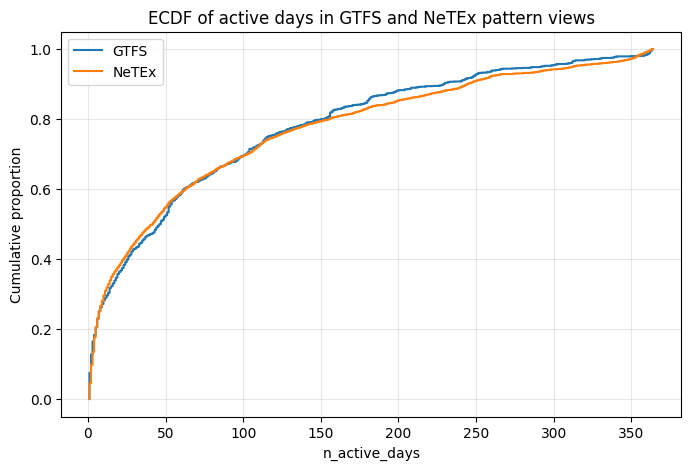

In [167]:
# Prepare sorted values
gtfs_vals = np.sort(gtfs_pattern_compare["n_active_days"].dropna())
netex_vals = np.sort(netex_pattern_compare["n_active_days"].dropna())

# ECDF y-values
gtfs_y = np.arange(1, len(gtfs_vals) + 1) / len(gtfs_vals)
netex_y = np.arange(1, len(netex_vals) + 1) / len(netex_vals)

plt.figure(figsize=(8, 5))
plt.step(gtfs_vals, gtfs_y, where="post", label="GTFS")
plt.step(netex_vals, netex_y, where="post", label="NeTEx")

plt.xlabel("n_active_days")
plt.ylabel("Cumulative proportion")
plt.title("ECDF of active days in GTFS and NeTEx pattern views")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Empirical Cumulative Distribution Function (ECDF)

This ECDF plot shows the cumulative proportion of calendar patterns by `n_active_days`.

In other words, each point on a curve answers the question:

- **What share of patterns has this number of active days or fewer?**

For example:

- if the GTFS curve reaches **0.60** at `n_active_days = 50`, this means that **60% of GTFS patterns have 50 or fewer active days**
- if the NeTEx curve reaches **0.70** at the same point, this means that **70% of NeTEx patterns have 50 or fewer active days**

So if one curve is higher than the other at a given x-value, this means that the corresponding side has a larger proportion of patterns concentrated at lower values of `n_active_days`.

For this comparison, the main idea is:

- if the two curves stay close together, the GTFS and NeTEx distributions are similar
- if one curve is clearly above the other over a longer range, then that side contains relatively more patterns with fewer active days
- if both curves end at similar maximum values, this suggests that the overall range is also similar

Together with the earlier summary statistics, this plot can be interpreted as another check of whether GTFS and NeTEx show similar pattern-level calendar behavior.

So the ECDF is not used for direct matching, but for comparing the overall distribution of `n_active_days` on both sides.

/var/folders/d0/_clgwfrd1pjg99nnqz2mm5ph0000gn/T/ipykernel_24090/148806073.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["GTFS", "NeTEx"], showfliers=False)


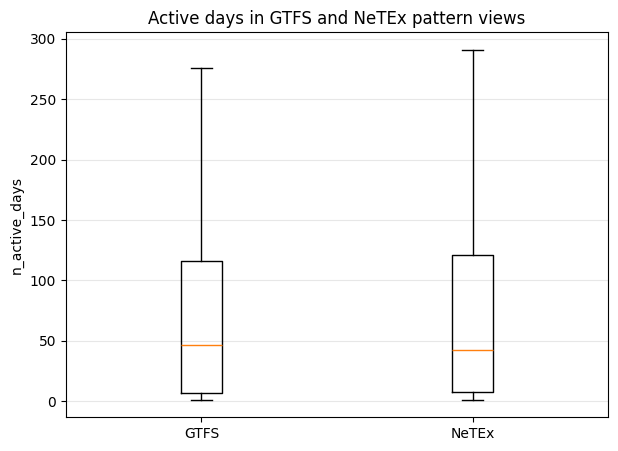

In [168]:
# Boxplot

data = [
    gtfs_pattern_compare["n_active_days"].dropna(),
    netex_pattern_compare["n_active_days"].dropna()
]

plt.figure(figsize=(7, 5))
plt.boxplot(data, labels=["GTFS", "NeTEx"], showfliers=False)
plt.ylabel("n_active_days")
plt.title("Active days in GTFS and NeTEx pattern views")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Boxplot

This boxplot gives a simple summary of the distribution of `n_active_days` on both sides.

The two boxplots look quite similar. In both GTFS and NeTEx, the median is at a similar level, and the overall spread is also comparable. The lower and upper parts of the boxes are close, which suggests that the middle 50% of patterns is distributed in a similar way in the two formats.

The whiskers also reach to similar values, which indicates that both sides cover a similar overall range of active-day patterns.

So this visual summary supports the earlier numerical results: at pattern level, GTFS and NeTEx show a broadly similar distribution of `n_active_days`, even though the two formats still differ in how they build this calendar logic internally.

## Conclusion

This signature check suggests that the candidate shared calendar MVD is not only conceptually plausible, but also shows substantial practical overlap between GTFS and NeTEx.

The signature was built only from the shared pattern-level fields:

- `validity_start`
- `validity_end`
- `n_active_days`
- `first_active_date`
- `last_active_date`

This means that identifiers such as `service_id` and `daytype_ref` were not used for the comparison itself. Instead, the comparison focused only on the shared calendar pattern summary.

The results show:

- **1249** distinct GTFS signatures
- **3565** distinct NeTEx signatures
- **774** signatures that appear on both sides

This suggests that a large number of calendar patterns can be described in a similar way in both formats, even though the two datasets are not identical in size or structure.

The row-level counts also support this:

- **853** GTFS rows have a signature that also appears in NeTEx
- **1002** NeTEx rows have a signature that also appears in GTFS

These numbers are higher than the number of shared distinct signatures because multiple rows can share the same signature on one side.

So this does not mean that GTFS and NeTEx can be matched one-to-one by identifier. But it does show that the candidate shared calendar MVD captures a meaningful amount of common pattern-level structure.

At the same time, the overlap is not complete. Both GTFS and NeTEx also contain many signatures that do not appear on the other side. This suggests that the shared calendar MVD is useful as a common denominator, but it does not fully remove the structural differences between the two formats.

## Limitations of the calendar comparison

Even though the shared calendar MVD looks plausible, the comparison still has some important limitations.

First, the two formats build calendar logic in different ways:

- in **GTFS**, service validity is strongly influenced by `calendar_dates`
- in **NeTEx**, service validity is represented through `DayType`, `DayTypeAssignment`, and operating-period / validity-bit structures

Second, the shared MVD works at **pattern-summary level**. This means it captures comparable calendar behavior, but it does not imply direct one-to-one equivalence between `service_id` and `daytype_ref`.

Third, a targeted raw-XML check did not find an explicit `PropertyOfDay` element in the Austria NeTEx files. So the practical comparison had to rely on the calendar elements that were actually present and extracted.

Finally, the signature overlap was meaningful but not complete. This means that the shared calendar MVD is useful as a common denominator, but it does not remove all structural differences between GTFS and NeTEx.

In [169]:
# Save the final comparison tables

output_dir = Path("data/processed/calendar_comparison")
output_dir.mkdir(parents=True, exist_ok=True)

# save the main comparison tables
gtfs_pattern_compare.to_csv(output_dir / "gtfs_calendar_pattern_compare.csv", index=False)
netex_pattern_compare.to_csv(output_dir / "netex_calendar_pattern_compare.csv", index=False)
shared_signatures.to_csv(output_dir / "shared_calendar_signatures.csv", index=False)

# also save the rows whose signatures overlap
gtfs_rows_with_shared_signature.to_csv(
    output_dir / "gtfs_rows_with_shared_signature.csv", index=False
)
netex_rows_with_shared_signature.to_csv(
    output_dir / "netex_rows_with_shared_signature.csv", index=False
)

print("Saved files to:")
print(output_dir)
print("\nFiles:")
for p in sorted(output_dir.glob("*.csv")):
    print("-", p.name)

Saved files to:
data/processed/calendar_comparison

Files:
- gtfs_calendar_pattern_compare.csv
- gtfs_rows_with_shared_signature.csv
- netex_calendar_pattern_compare.csv
- netex_rows_with_shared_signature.csv
- shared_calendar_signatures.csv


# Appendix

The material below is supplementary. Additional GTFS checks, NeTEx exploration notes, and debug steps that were used during development. It is kept for transparency but is not required to reproduce the MVD comparisons above.

## Additional GTFS Checks

### Preview stops and trips

A quick preview of the already-loaded `stops` and `trips` tables, just to confirm the columns available for the MVD extraction.

In [170]:
print("stops shape:", stops.shape)
print("stops columns:", list(stops.columns))
display(stops.head())

stops shape: (7698, 9)
stops columns: ['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'zone_id', 'location_type', 'parent_station', 'level_id', 'platform_code']


,stop_id,stop_name,stop_lat,stop_lon,zone_id,location_type,parent_station,level_id,platform_code
0,at:41:3087:0:1,Bad Sauerbrunn Bahnhof,47.773659,16.325066,NaN,NaN,Pat:41:3087,Level 0,1
1,at:41:3087:0:2,Bad Sauerbrunn Bahnhof,47.773647,16.325057,NaN,NaN,Pat:41:3087,Level 0,2
2,at:41:3087:2,Bus,47.774226,16.324509,NaN,NaN,Pat:41:3087,Level 0,NaN
3,at:41:3087:3,Zugang,47.773949,16.324356,NaN,2.0,Pat:41:3087,Level 0,NaN
4,at:41:3087:4,P+R,47.772578,16.325695,NaN,3.0,Pat:41:3087,Level 0,NaN


In [171]:
print("trips shape:", trips.shape)
print("trips columns:", list(trips.columns))
display(trips.head())

trips shape: (15165, 8)
trips columns: ['route_id', 'service_id', 'trip_id', 'shape_id', 'trip_headsign', 'trip_short_name', 'direction_id', 'block_id']


,route_id,service_id,trip_id,shape_id,trip_headsign,trip_short_name,direction_id,block_id
0,10-A10-1-j26-1,TA+he100,1.TA.10-A10-1-j26-1.1.R,10-A10-1-j26-1.1.R,Salzburg Hauptbahnhof,RJ 658,1,725.0
1,10-A10-1-j26-1,TA+f0,10.TA.10-A10-1-j26-1.7.H,10-A10-1-j26-1.7.H,Flughafen Wien Bahnhof,RJ 551,0,732.0
2,10-A10-1-j26-1,TA+cm,11.TA.10-A10-1-j26-1.8.H,10-A10-1-j26-1.8.H,Wien Hauptbahnhof,D 1130,0,NaN
3,10-A10-1-j26-1,TA+2C,2.TA.10-A10-1-j26-1.2.R,10-A10-1-j26-1.2.R,Salzburg Hauptbahnhof,RJ 110,1,726.0
4,10-A10-1-j26-1,TA+ie100,3.TA.10-A10-1-j26-1.3.R,10-A10-1-j26-1.3.R,Salzburg Hauptbahnhof,RJ 658,1,725.0


### Exploration: Inspecting parent_station relationships (station → platforms)

In [172]:
# pick a parent station id that appears often
parent_id = stops["parent_station"].dropna().value_counts().index[0]
stops[stops["stop_id"].eq(parent_id) | stops["parent_station"].eq(parent_id)].head(20)

,stop_id,stop_name,stop_lat,stop_lon,zone_id,location_type,parent_station,level_id,platform_code
5785,at:49:1349:0:1,Wien Hauptbahnhof,48.185332,16.378650,NaN,NaN,Pat:49:1349,Level 1,3
5786,at:49:1349:0:10,Wien Hauptbahnhof,48.184451,16.378345,NaN,NaN,Pat:49:1349,Level 1,12
5787,at:49:1349:0:12,Wien Hauptbahnhof,48.186050,16.375075,NaN,NaN,Pat:49:1349,Level -1,1
5788,at:49:1349:0:27,Wien Hauptbahnhof,48.184871,16.378453,NaN,NaN,Pat:49:1349,Level 1,8
5789,at:49:1349:0:28,Wien Hauptbahnhof,48.184733,16.378417,NaN,NaN,Pat:49:1349,Level 1,9
5790,at:49:1349:0:29,Wien Hauptbahnhof,48.185068,16.378533,NaN,NaN,Pat:49:1349,Level 1,6
5791,at:49:1349:0:31,Wien Hauptbahnhof,48.184960,16.378480,NaN,NaN,Pat:49:1349,Level 1,7
5792,at:49:1349:0:32,Wien Hauptbahnhof,48.185152,16.378560,NaN,NaN,Pat:49:1349,Level 1,5
5793,at:49:1349:0:33,Wien Hauptbahnhof,48.185266,16.378632,NaN,NaN,Pat:49:1349,Level 1,4
5794,at:49:1349:0:34,Wien Hauptbahnhof,48.185967,16.375147,NaN,NaN,Pat:49:1349,Level -1,2


### Example trip preview (stop order and times)

In [173]:
example_trip = stop_times["trip_id"].iloc[0]

trip_st = (
    stop_times[stop_times["trip_id"] == example_trip]
    .sort_values("stop_sequence")
    .merge(stops[["stop_id","stop_name"]], on="stop_id", how="left")
)

print("Example trip:", example_trip)
display(trip_st[["stop_sequence","stop_name","arrival_time","departure_time"]].head(30))

Example trip: 1.TA.20-SV1-A-j26-1.1.R


,stop_sequence,stop_name,arrival_time,departure_time
0,1,St.Nikola-Struden Bahnhst,05:27:00,05:27:00
1,2,Grein Schiffstation (Donaulände),05:32:00,05:32:00
2,3,Grein-Bad Kreuzen Bahnhof,05:37:00,05:37:00


### Longest trip (max stop count)

I identified the `<trip_id>` with the highest number of stop entries in `<stop_times.txt>` and inspected it.
The stops were sorted by `<stop_sequence>` and merged with stops.txt to show stop names and times.

This helps validate that even long trips are consistent and correctly join to stop metadata.

In [174]:
long_trip = stop_times.groupby("trip_id").size().sort_values(ascending=False).index[0]

trip_st_long = (
    stop_times[stop_times["trip_id"] == long_trip]
    .sort_values("stop_sequence")
    .merge(stops[["stop_id","stop_name"]], on="stop_id", how="left")
)

print("Longest trip:", long_trip, "stops:", len(trip_st_long))
display(trip_st_long[["stop_sequence","stop_name","arrival_time","departure_time"]].head(40))

Longest trip: 236.TA.1-S2-W-j26-1.97.R stops: 51


,stop_sequence,stop_name,arrival_time,departure_time
0,1,Wiener Neustadt Hauptbahnhof,07:05:00,07:05:00
1,2,Wiener Neustadt Nord,07:09:00,07:09:00
2,3,Theresienfeld Bahnhof,07:12:00,07:12:00
3,4,Felixdorf Bahnhof,07:15:00,07:15:00
4,5,Sollenau Bahnhof,07:17:00,07:18:00
5,6,Leobersdorf Bahnhof,07:21:00,07:22:00
6,7,Kottingbrunn Bahnhof,07:24:00,07:24:00
7,8,Bad Vöslau Bahnhof,07:27:00,07:28:00
8,9,Baden Bahnhof,07:32:00,07:32:00
9,10,Pfaffstätten Bahnhof,07:35:00,07:35:00


## NeTEx Exploration / Debug Notes

This is an appendix of the data checks I did, in order to see better with what I am dealing with

### Most frequent tags

I scanned one large NeTEx XML file and counted the most frequent XML tags. I saw many tags for names and locations (e.g., Name, Location, Latitude, Longitude, Quay), which confirmed that stop names and coordinates are available in the NeTEx data and can be extracted into the MVD stops table

In [175]:
def inspect_netex_tags(zip_path: Path, xml_name: str, max_events: int = 20000):
    counts = {}
    seen = 0

    with zipfile.ZipFile(zip_path, "r") as z:
        with z.open(xml_name) as f:
            # start/end events = streaming parse
            for event, elem in ET.iterparse(f, events=("start", "end")):
                if event == "start":
                    tag = elem.tag
                    counts[tag] = counts.get(tag, 0) + 1
                    seen += 1
                    if seen >= max_events:
                        break
                # free memory (important)
                if event == "end":
                    elem.clear()

    # show most frequent tags
    top = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:30]
    return top

top_tags = inspect_netex_tags(netex_zip, xml_name, max_events=50000)
for tag, c in top_tags:
    print(c, tag)

49 {http://www.netex.org.uk/netex}StopPlaceRef
38 {http://www.netex.org.uk/netex}Name
31 {http://www.netex.org.uk/netex}ShortName
26 {http://www.netex.org.uk/netex}PrivateCode
23 {http://www.netex.org.uk/netex}SiteConnection
23 {http://www.netex.org.uk/netex}WalkTransferDuration
23 {http://www.netex.org.uk/netex}DefaultDuration
23 {http://www.netex.org.uk/netex}BothWays
23 {http://www.netex.org.uk/netex}From
23 {http://www.netex.org.uk/netex}To
20 {http://www.netex.org.uk/netex}NoticeAssignment
20 {http://www.netex.org.uk/netex}NoticeRef
19 {http://www.netex.org.uk/netex}QuayRef
15 {http://www.netex.org.uk/netex}Location
15 {http://www.netex.org.uk/netex}Longitude
15 {http://www.netex.org.uk/netex}Latitude
12 {http://www.netex.org.uk/netex}KeyValue
12 {http://www.netex.org.uk/netex}Key
12 {http://www.netex.org.uk/netex}Value
12 {http://www.netex.org.uk/netex}Centroid
11 {http://www.netex.org.uk/netex}keyList
11 {http://www.netex.org.uk/netex}LevelRef
11 {http://www.netex.org.uk/netex}S

### Keyword Check

I ran a quick keyword check on one NeTEx XML file to see which important NeTEx objects are present. I searched for tags containing keywords like StopPlace, Quay, Line, and timetable-related objects (e.g., ServiceJourney, TimetabledPassingTime). The results showed many StopPlace and Quay elements (and some Line), but no timetable objects in this file. This suggests that stop/location data and timetable data are separated across different XML files in the dataset.

In [176]:
keywords = ["StopPlace", "Quay", "ScheduledStopPoint", "Line", "Route", "ServiceJourney", "TimetabledPassingTime", "JourneyPattern", "DayType", "OperatingPeriod", "ServiceCalendar"]

with zipfile.ZipFile(netex_zip, "r") as z:
    with z.open(xml_name) as f:
        found = {k: 0 for k in keywords}
        for event, elem in ET.iterparse(f, events=("end",)):
            # elem.tag includes namespace, so we check substring
            for k in keywords:
                if k in elem.tag:
                    found[k] += 1
            elem.clear()

print(found)

{'StopPlace': 51, 'Quay': 33, 'ScheduledStopPoint': 14, 'Line': 7, 'Route': 0, 'ServiceJourney': 12, 'TimetabledPassingTime': 8, 'JourneyPattern': 22, 'DayType': 7, 'OperatingPeriod': 2, 'ServiceCalendar': 2}


### Debug step: find where stop names + coordinates are stored 

At the beginning, my extracted stop table had many empty values (None) for the station name and for lat/lon.  
So my first goal was to check if my code was looking in the wrong place inside the NeTEx XML.

I took one example `stop_id` from my table (e.g., `at:43:3079:1`) and searched for this ID inside the XML files in the ZIP.  
This helped me because it gave me a concrete clue: the ID *does exist* in the dataset, and I could see *which exact XML file* contains it.

Once I found the file, I printed the text around the ID and saw that the name and coordinates are stored inside the `<Quay>` / `<StopPlace>` part, under elements like `<Name>` and `<Centroid><Location><Latitude>/<Longitude>`.  
This confirmed that the data is not missing and that my earlier extraction logic was just not reaching the correct nested path.

After this clue, I changed the extraction approach: instead of only printing / counting tags, I extracted stop records by reading the correct XML section and pulling out `Name`, `Latitude`, and `Longitude`, which produced filled values in the final stops table.

In [177]:
example_id = netex_stops_mvd["stop_id"].dropna().iloc[0]
print("at:43:3079:1", example_id)

file_with_id = None
with zipfile.ZipFile(netex_zip, "r") as z:
    for xml_name in all_xml:
        with z.open(xml_name) as f:
            txt = f.read(200000).decode("utf-8", errors="ignore")
        if example_id in txt:
            file_with_id = xml_name
            print("Found in:", file_with_id)
            break

at:43:3079:1 at:41:4367:1
Found in: NX-PI_01_at_obb_LINE_obb_12-A3-j26_20260302.xml


### Debug step 2: check the XML nesting for one stop ID

After I found which XML file contains my example `stop_id`, I opened that file and printed the text around the ID.  
This showed me the exact nesting in NeTEx: the stop appears under a `<Quay>` element, and the name and coordinates are inside that block (e.g., `<Name>` and `<Centroid><Location><Latitude>/<Longitude>`).  


In [178]:
with zipfile.ZipFile(netex_zip, "r") as z:
    with z.open(file_with_id) as f:
        txt = f.read().decode("utf-8", errors="ignore")

pos = txt.find(example_id)
print("Position:", pos)

print(txt[max(0,pos-500):pos+1500])

Position: 75842
tude>47.942637</Latitude>
                </Location>
              </Centroid>
              <TopographicPlaceRef ref="at:obb:TopographicPlace:37e4be25-1e99-4e42-b122-c99fe656d4e8:" version="any" />
              <levels>
                <Level id="at:obb:Level:639-0:" version="any">
                  <Name lang="de">Erdgeschoss</Name>
                  <ShortName lang="de">G</ShortName>
                </Level>
              </levels>
              <quays>
                <Quay id="at:41:4367:1" version="any">
                  <keyList>
                    <KeyValue>
                      <Key>GlobalID</Key>
                      <Value>at:41:4367:1</Value>
                    </KeyValue>
                  </keyList>
                  <Extensions>
                    <MentzAreaType>OnlyPT</MentzAreaType>
                  </Extensions>
                  <Name lang="de">Bahn</Name>
                  <ShortName lang="de">bahn</ShortName>
                  <PrivateCode>

## PropertyOfDay Check

# Check whether PropertyOfDay is present in the Austria NeTEx XML

Before extending the NeTEx calendar extraction, it is useful to do a small targeted check for `PropertyOfDay` in the raw XML.

This step is important because expert mapping documents mention `PropertyOfDay` as part of the conceptual relation between GTFS and NeTEx calendar logic. However, for the Austria pilot, it is still unclear whether this element is explicitly present in the source data and whether it adds useful information for the practical comparison.

So the goal of this section is simple:

- check whether `PropertyOfDay` appears in the raw NeTEx XML
- inspect a few examples if it appears
- then decide whether extracting it would improve the calendar comparison

In [179]:
netex_zip_path = netex_zip  # reuse the NeTEx zip path already set in Part 2
print(netex_zip_path)

data/raw/netex_evu_2026.zip


In [180]:
# Search all XML files in the ZIP for PropertyOfDay-related strings

search_terms = [
    "PropertyOfDay",
    "propertyOfDay",
    "DaysOfWeek",
    "DayType",
    "DayTypeAssignment"
]

hits = []

with zipfile.ZipFile(netex_zip_path, "r") as zf:
    xml_names = [name for name in zf.namelist() if name.endswith(".xml")]
    
    for name in xml_names:
        text = zf.read(name).decode("utf-8", errors="ignore")
        found_terms = [term for term in search_terms if term in text]
        
        if found_terms:
            hits.append({
                "xml_file": name,
                "found_terms": ", ".join(found_terms)
            })

print("Number of XML files with at least one relevant term:", len(hits))
hits[:10]

Number of XML files with at least one relevant term: 367


[{'xml_file': 'NX-PI_01_at_obb_LINE_obb_2-RX7-W-j26_20260302.xml',
  'found_terms': 'DayType, DayTypeAssignment'},
 {'xml_file': 'NX-PI_01_at_obb_LINE_obb_1-S7-W-j26_20260302.xml',
  'found_terms': 'DayType, DayTypeAssignment'},
 {'xml_file': 'NX-PI_01_at_obb_LINE_obb_1-S3-W-j26_20260302.xml',
  'found_terms': 'DayType, DayTypeAssignment'},
 {'xml_file': 'NX-PI_01_at_obb_LINE_obb_20-SV8-E-j26_20260302.xml',
  'found_terms': 'DayType, DayTypeAssignment'},
 {'xml_file': 'NX-PI_01_at_obb_LINE_obb_20-SV8-D-j26_20260302.xml',
  'found_terms': 'DayType, DayTypeAssignment'},
 {'xml_file': 'NX-PI_01_at_obb_LINE_obb_20-SV8-C-j26_20260302.xml',
  'found_terms': 'DayType, DayTypeAssignment'},
 {'xml_file': 'NX-PI_01_at_obb_LINE_obb_20-SV8-B-j26_20260302.xml',
  'found_terms': 'DayType, DayTypeAssignment'},
 {'xml_file': 'NX-PI_01_at_obb_LINE_obb_20-SV8-A-j26_20260302.xml',
  'found_terms': 'DayType, DayTypeAssignment'},
 {'xml_file': 'NX-PI_01_at_obb_LINE_obb_20-SV5-I-j26_20260302.xml',
  'found_

In [181]:
# Count how often each term appears across the matching XML files

term_counter = Counter()

for row in hits:
    for term in row["found_terms"].split(", "):
        term_counter[term] += 1

term_counter

Counter({'DayType': 367, 'DayTypeAssignment': 367})

In [182]:
# Keep only files that explicitly contain PropertyOfDay

property_of_day_files = [row["xml_file"] for row in hits if "PropertyOfDay" in row["found_terms"]]

print("Number of XML files containing PropertyOfDay:", len(property_of_day_files))
property_of_day_files[:10]

Number of XML files containing PropertyOfDay: 0


[]

In [183]:
# Show a short text snippet around the first PropertyOfDay hit

if property_of_day_files:
    sample_file = property_of_day_files[0]
    
    with zipfile.ZipFile(netex_zip_path, "r") as zf:
        text = zf.read(sample_file).decode("utf-8", errors="ignore")
    
    pos = text.find("PropertyOfDay")
    snippet = text[max(0, pos-500):pos+1500]
    
    print("Sample file:", sample_file)
    print(snippet)
else:
    print("No PropertyOfDay element found in the raw XML.")

No PropertyOfDay element found in the raw XML.


### Conclusion

A targeted raw-XML check for `PropertyOfDay` did not find any explicit occurrences in the Austria NeTEx files.

This suggests that, in this export, the service-validity logic is not represented through an explicit `PropertyOfDay` structure. Instead, the practical calendar pattern appears to be carried mainly by `DayType`, `DayTypeAssignment`, and operating-period / validity-bit elements.

So for the Austria pilot, the calendar comparison should continue with the NeTEx fields that are actually present and extracted, rather than assuming that all conceptual mapping elements appear explicitly in the source XML.

## Closing Note: Candidate MVD Fields (from the extraction stage)

## Minimum Viable Denominator (MVD)

**Goal:** the smallest common set of fields/concepts that both **both GTFS and NeTEx** can provide, so that I can make a fair comparison and attempt a simple mapping


### Candidate shared items 

| Concept (common denominator) | GTFS fields (source) | NeTEx fields (source) | Is it in the dataset? | Quality check / notes |
|---|---|---|---|---|
| Stop identifier | `stop_id` (`stops.txt`) | `id` (`StopPlace`, `Quay`) |  yes | 0% missing in both extractions |
| Stop name | `stop_name` (`stops.txt`) | `Name` (`StopPlace`, `Quay`) |  yes | NeTEx ~10% missing names; GTFS 0% missing |
| Stop coordinates | `stop_lat`, `stop_lon` (`stops.txt`) | `Centroid/Location/Latitude/Longitude` |  yes | NeTEx ~3.6% missing coords; GTFS 0% missing |
| Stop hierarchy (optional) | `parent_station`, `location_type` | `StopPlace` ↔ `Quay` structure | partial | Exists, but mapping needs rules (platform vs station) |
| Line identifier | `route_id` (`routes.txt`) | `Line/@id` |  yes | extracted as `route_id` for NeTEx lines |
| Line public code / short name | `route_short_name` (`routes.txt`) | `PublicCode` or `ShortName` (`Line`) | partial | NeTEx `public_code` missing ~39% (still usable) |
| Service validity window | `start_date`, `end_date` (`calendar.txt`) | (feed-dependent calendar structure) | partial | depends what `netex_calendar_mvd.csv` contains |
| Trip + stop times | `trips.txt` + `stop_times.txt` | nested `ServiceJourney` + passing times |  not yet | NeTEx extraction not implemented yet |

### Current Minimum Viable Denominator
For a robust first comparison, I use:

- **Stops:** id + name + lat + lon  
- **Lines:** id + a display label (prefer PublicCode, else Name/ShortName)

This makes it possible to  compare:
- coverage (how many stops/lines)
- missingness and quality
- identifier formats and hierarchy differences
- basic mapping feasibility (stop-level + line-level)

**Update:** the table above reflects the state right after the initial GTFS/NeTEx extraction (Parts 1-2). The station-level (Part 3), route/line-level (Part 4), and calendar-level (Part 5) sections later in this notebook build on this foundation and go further: the calendar validity window ended up being reconstructed as a full calendar chain (`ServiceJourney -> DayTypeRef -> DayTypeAssignment -> UicOperatingPeriod`, 30,776 rows) rather than staying feed-dependent and partial, and a line-to-stop linkage was also reconstructed from the raw NeTEx XML to validate matched line labels. Only the fully nested `ServiceJourney` + passing-times (stop-level scheduled arrival/departure times) extraction on the NeTEx side remains out of scope.

